## 순서 

### 1. 핵심 KPI

### 2. 오퍼별 분석

### 3. 채널 관여별 분석

### 4. Completed 관련 분석

### 5. 오퍼 퍼널 분석

### 6. 고객 세그먼트 분석


In [1]:
# 데이터 처리 및 분석
import pandas as pd
import ast
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import platform

# ── 스타벅스 공식 컬러 팔레트 ──
SB_DEEP_GREEN  = '#1E3932'  # 가장 어두운 초록 (VIP/헤드라인)
SB_GREEN       = '#006241'  # 공식 스타벅스 그린 (메인 액션)
SB_LIGHT_GREEN = '#D4E9E2'  # 연한 초록 (보조/새싹 고객)
SB_GOLD        = '#CBA258'  # 골드 (강조/정보성 선호 고객)
SB_GREY        = '#A2AAAD'  # 회색 (일반 고객/기타)
SB_BLACK       = '#27251F'  # 텍스트용 블랙

sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

# ── 연령대 레이블 (전체 셀 공유) ──
AGE_BINS   = [0, 19, 29, 39, 49, 59, 69, 79, 150]
AGE_LABELS = ['20대 미만', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']

# ── 소득 구간 레이블 (전체 셀 공유) ──
INCOME_BINS   = [0, 50000, 70000, 90000, 110000, float('inf')]
INCOME_LABELS = ['30K-50K', '50K-70K', '70K-90K', '90K-110K', '110K 이상']
INCOME_ORDER  = INCOME_LABELS + ['Unknown']

# ── 가입 연차 레이블 (전체 셀 공유) ──
TENURE_ORDER = ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년', '5년 이상']

# ── 성별 순서 (전체 셀 공유) ──
GENDER_ORDER = ['남성', '여성', 'Other', 'Unknown']

# ── 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize']     = (12, 6)
plt.rcParams['text.color']         = SB_BLACK
plt.rcParams['axes.labelcolor']    = SB_BLACK
plt.rcParams['xtick.color']        = SB_BLACK
plt.rcParams['ytick.color']        = SB_BLACK

# ── 출력 설정 ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("=" * 60)
print("라이브러리 로드 완료!")
print(f"AGE_LABELS   : {AGE_LABELS}")
print(f"INCOME_ORDER : {INCOME_ORDER}")
print(f"TENURE_ORDER : {TENURE_ORDER}")
print("=" * 60)
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!
라이브러리 로드 완료!
AGE_LABELS   : ['20대 미만', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']
INCOME_ORDER : ['30K-50K', '50K-70K', '70K-90K', '90K-110K', '110K 이상', 'Unknown']
TENURE_ORDER : ['1년 미만', '1~2년', '2~3년', '3~4년', '4~5년', '5년 이상']


In [2]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")
df = merge_df.copy()
trans_df = pd.read_csv("../../Data/transactions_260325.csv")
transaction_df = trans_df.copy()

info 확인

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

head 확인

In [4]:
df.head()

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
0,0009655768c64bdeb2e877511632db8f,received,576,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,0,1,1.0,NaN
1,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,1.0,NaN
2,0009655768c64bdeb2e877511632db8f,received,336,3f207df678b143eea3cee63160fa8bed,NaN,NaN,15,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,0,1,1.0,NaN
3,0009655768c64bdeb2e877511632db8f,viewed,372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,16,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,1,0,1.0,NaN
4,0009655768c64bdeb2e877511632db8f,received,168,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,8,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2,0,1,1.0,NaN


In [5]:
transaction_df.head()

,tx_key,person,customer_id,time,amount,tx_occurrence,time_days,gender,age,became_member_on,income,income_missing,age_missing,linked_reward_offer_cnt,reward_offer_family_list,reward_offer_label_list,reward_offer_id_list,bonus_reward_sum,tx_offer_type
0,0009655768c64bdeb2e877511632db8f|228|22.16|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,228,22.16,1,10,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
1,0009655768c64bdeb2e877511632db8f|414|8.57|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,414,8.57,1,18,M,33.0,2017-04-21,72000.0,0,0,1,['bogo'],['bogo_4'],['f19421c1d4aa40978ebb69ca19b0e20d'],5,bogo
2,0009655768c64bdeb2e877511632db8f|528|14.11|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,528,14.11,1,23,M,33.0,2017-04-21,72000.0,0,0,1,['discount'],['discount_3'],['fafdcd668e3743c1bb461111dcafc2a4'],2,discount
3,0009655768c64bdeb2e877511632db8f|552|13.56|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,552,13.56,1,24,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
4,0009655768c64bdeb2e877511632db8f|576|10.27|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,576,10.27,1,25,M,33.0,2017-04-21,72000.0,0,0,1,['discount'],['discount_4'],['2906b810c7d4411798c6938adc9daaa5'],2,discount


#### noinfo_merge_df : informational이 없는 merge_df

In [6]:
exclude_labels = ['informational_1', 'informational_2']

noinfo_merge_df = df[~df['offer_label'].isin(exclude_labels)]

print("남아있는 오퍼:", noinfo_merge_df['offer_label'].unique())

남아있는 오퍼: <StringArray>
['discount_4',     'bogo_4', 'discount_3',          nan, 'discount_1',
 'discount_2',     'bogo_3',     'bogo_2',     'bogo_1']
Length: 9, dtype: str


In [7]:
ex_shape = df.shape
print(ex_shape)

noinfo_shape = noinfo_merge_df.shape
print(noinfo_shape)

(306137, 26)
(280071, 26)


# 1. 핵심 KPI 모음

### 총 매출
### 총 거래 건수
### 거래당 평균 구매금액 = AOV
### 고객당 평균 구매금액 = 고객가치
### 평균 구매 빈도

In [8]:
# 구매 데이터 추출
transactions = df[df['event'] == 'transaction'].copy()

# 핵심 KPI 계산
total_revenue = transactions['amount'].sum()                  # 총 매출
transaction_cnt = len(transactions)                           # 총 거래 건수
customer_cnt = df['customer_id'].nunique()                    # 전체 고객 수
buyer_cnt = transactions['customer_id'].nunique()             # 구매 고객 수

# 거래당 평균 구매금액(AOV)
aov = total_revenue / transaction_cnt if transaction_cnt > 0 else 0

# 고객당 평균 구매금액(전체 고객 기준)
customer_value = total_revenue / customer_cnt if customer_cnt > 0 else 0

# 구매 고객당 평균 구매금액(구매 고객 기준)
arppu = total_revenue / buyer_cnt if buyer_cnt > 0 else 0

# 평균 구매 빈도
avg_purchase_freq_all = transaction_cnt / customer_cnt if customer_cnt > 0 else 0
avg_purchase_freq_buyers = transaction_cnt / buyer_cnt if buyer_cnt > 0 else 0

print("=" * 60)
print("[핵심 KPI]")
print("=" * 60)
print(f"총 매출: ${total_revenue:,.2f}")
print(f"총 거래 건수: {transaction_cnt:,}건")
print(f"거래당 평균 구매 금액(AOV): ${aov:,.2f}")
print(f"고객당 평균 구매 금액(전체 고객 기준): ${customer_value:,.2f}")
print(f"고객당 평균 구매 금액(구매 고객 기준): ${arppu:,.2f}")
print(f"전체 고객 수: {customer_cnt:,}명")
print(f"구매 고객 수: {buyer_cnt:,}명")
print(f"평균 구매 빈도(전체 고객 기준): {avg_purchase_freq_all:,.2f}회")
print(f"평균 구매 빈도(구매 고객 기준): {avg_purchase_freq_buyers:,.2f}회")

[핵심 KPI]
총 매출: $1,775,451.97
총 거래 건수: 138,953건
거래당 평균 구매 금액(AOV): $12.78
고객당 평균 구매 금액(전체 고객 기준): $104.44
고객당 평균 구매 금액(구매 고객 기준): $107.10
전체 고객 수: 17,000명
구매 고객 수: 16,578명
평균 구매 빈도(전체 고객 기준): 8.17회
평균 구매 빈도(구매 고객 기준): 8.38회


### 총 발송 수, 총 열람 수 , 총 완료 수

Received 건수: 76,277
Viewed 건수: 57,725
Completed 건수: 33,182


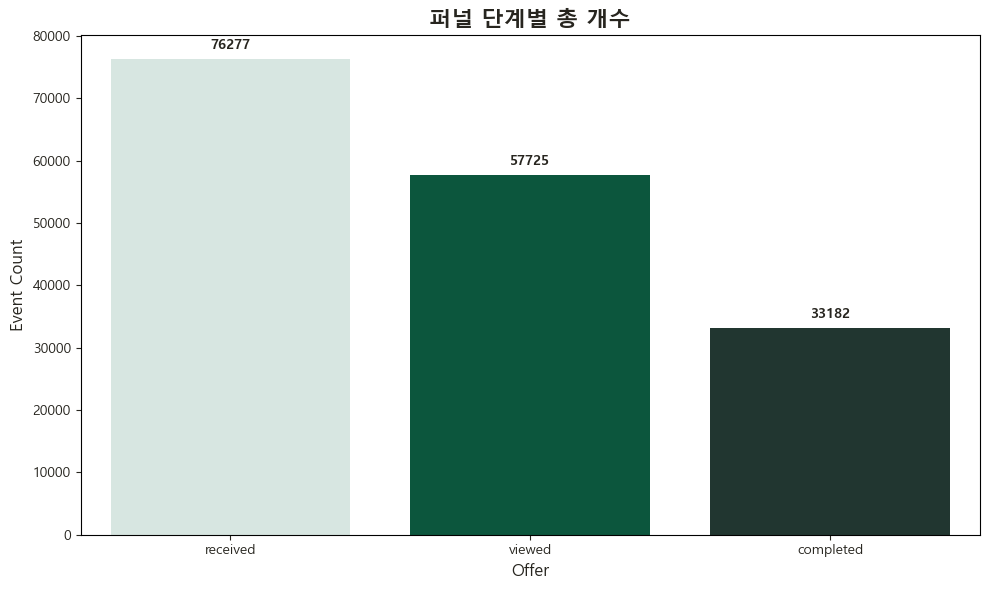

In [9]:
offer_events = ['received', 'viewed', 'completed']
event_counts = df['event'].value_counts().reindex(offer_events)

print(f"Received 건수: {event_counts['received']:,}")
print(f"Viewed 건수: {event_counts['viewed']:,}")
print(f"Completed 건수: {event_counts['completed']:,}")

plot_df = event_counts.reset_index()
plot_df.columns = ['Stage', 'Count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=plot_df, x='Stage', y='Count', 
                 palette=[SB_LIGHT_GREEN, SB_GREEN, SB_DEEP_GREEN], 
                 hue='Stage', legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

plt.title('퍼널 단계별 총 개수', fontsize=16, fontweight='bold')
plt.ylabel('Event Count', fontsize=12)
plt.xlabel('Offer', fontsize=12)

plt.tight_layout()
plt.show()

# 2. 오퍼별 

In [10]:
# trans_df에 'final_label' 컬럼 생성 
def get_correct_label(row):
    # 종류가 다른 오퍼들이 섞인 경우 (tx_offer_type이 multi인 경우)
    if row.get('tx_offer_type') == 'multi':
        return '다중오퍼'
    # bogo나 discount 계열 내에서 여러 오퍼를 동시에 완료한 경우
    elif row.get('tx_offer_type') in ['bogo', 'discount']:
        try:
            labels = ast.literal_eval(row['reward_offer_label_list'])
            if len(labels) > 1:
                return '다중오퍼'
            elif len(labels) == 1:
                return labels[0]
        except:
            pass
    return '일반 결제'

# trans_df에 'final_label' 컬럼을 직접 생성
transaction_df['final_label'] = transaction_df.apply(get_correct_label, axis=1)

# 생성된 final_label을 바탕으로 master_df(전체 퍼널 데이터) 구성
multi_txn_info = transaction_df[transaction_df['final_label'] == '다중오퍼'][['person', 'time']].drop_duplicates()
multi_txn_info['is_multi_txn'] = True

# merge_df의 완료 이벤트와 엮어서 '다중오퍼 경로' 키(key) 추출
completions = df[df['event'] == 'completed']
multi_path = pd.merge(completions, multi_txn_info, on=['person', 'time'], how='inner')
multi_path_keys = multi_path[['person', 'offer_id', 'receive_seq']].drop_duplicates()
multi_path_keys['is_multi_path'] = True

# merge_df 전체(인포메이셔널 제외)에 'final_label' 장착
master_df = pd.merge(noinfo_merge_df, multi_path_keys, on=['person', 'offer_id', 'receive_seq'], how='left')

# 다중오퍼 경로면 '다중오퍼', 아니면 기존 오퍼 분류 적용
master_df['final_label'] = master_df.apply(
    lambda x: '다중오퍼' if x['is_multi_path'] == True else x['offer_label'], axis=1
)

성과별로 볼 때는 informational 제외

### 오퍼별 총 발송 수, 총 열람 수, 총 완료 수

In [11]:
# 발송/열람/완료  계산
funnel_df = master_df.groupby(['final_label', 'event']).size().unstack(fill_value=0)
 
funnel_df = funnel_df[['received', 'viewed', 'completed']]
funnel_df.columns = ['총발송수', '총열람수', '총완료수']

# 순서 정렬
order = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4', '다중오퍼']
funnel_df = funnel_df.reindex(order)

display(funnel_df)

,총발송수,총열람수,총완료수
final_label,,,
bogo_1,7078,6249,3055
bogo_2,7124,6848,2832
bogo_3,7001,3826,3627
bogo_4,7035,6759,3726
discount_1,6894,2395,2560
discount_2,7012,6737,4476
discount_3,6862,6639,4526
discount_4,6966,3743,3296
다중오퍼,5070,3698,5084


### 1. 오퍼별 총 발송 수

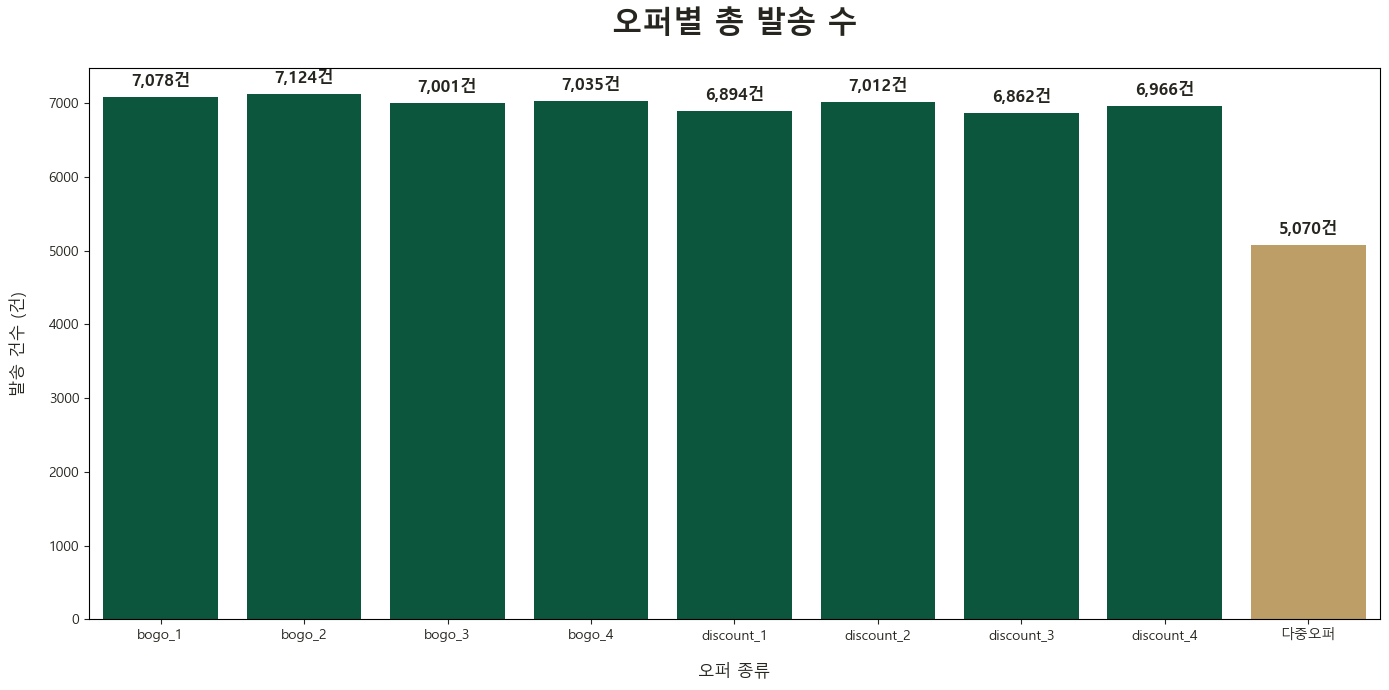

In [12]:
plt.figure(figsize=(14, 7))

plot_data = funnel_df.reset_index()

# 카테고리별 색상 배정 
colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data['final_label']]

ax = sns.barplot(data=plot_data, x='final_label', y='총발송수', palette=colors)

plt.title('오퍼별 총 발송 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('발송 건수 (건)', fontsize=12, labelpad=15)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 2. 오퍼별 총 열람 수

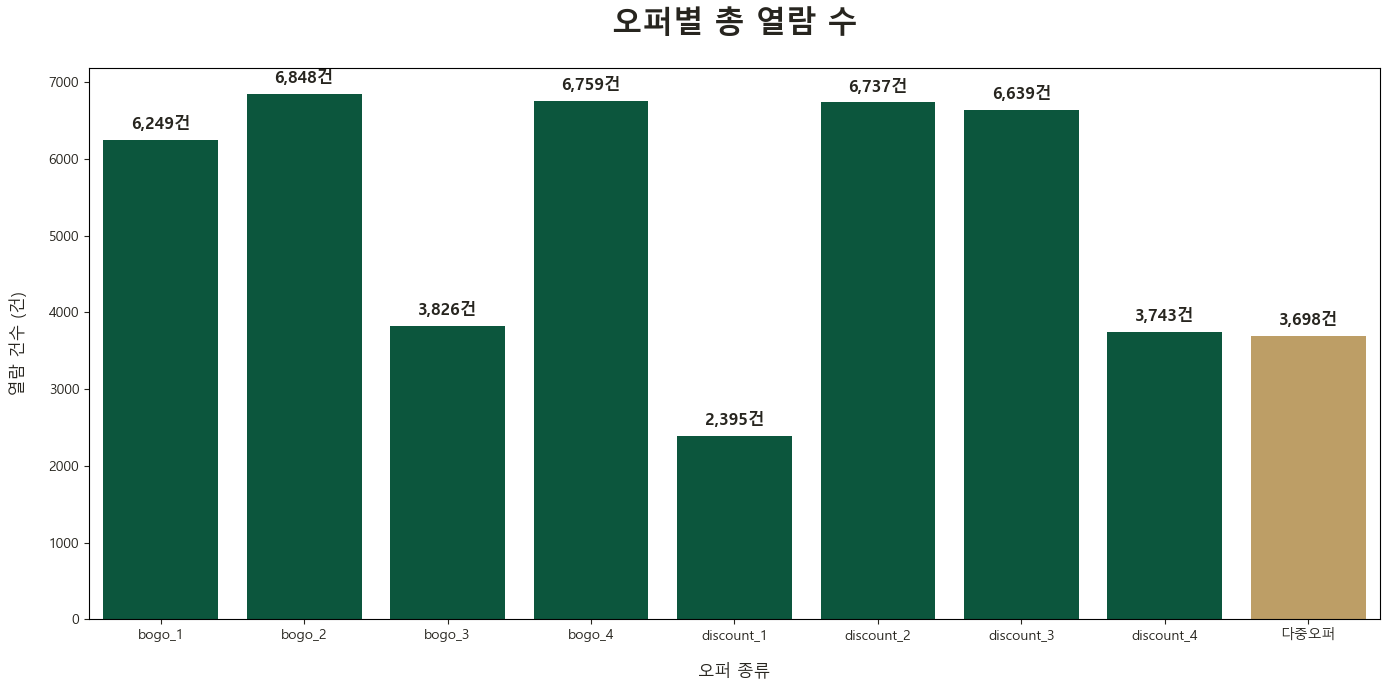

In [13]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(data=plot_data, x='final_label', y='총열람수', palette=colors)

plt.title('오퍼별 총 열람 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('열람 건수 (건)', fontsize=12, labelpad=15)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 3. 오펴별 총 완료 수

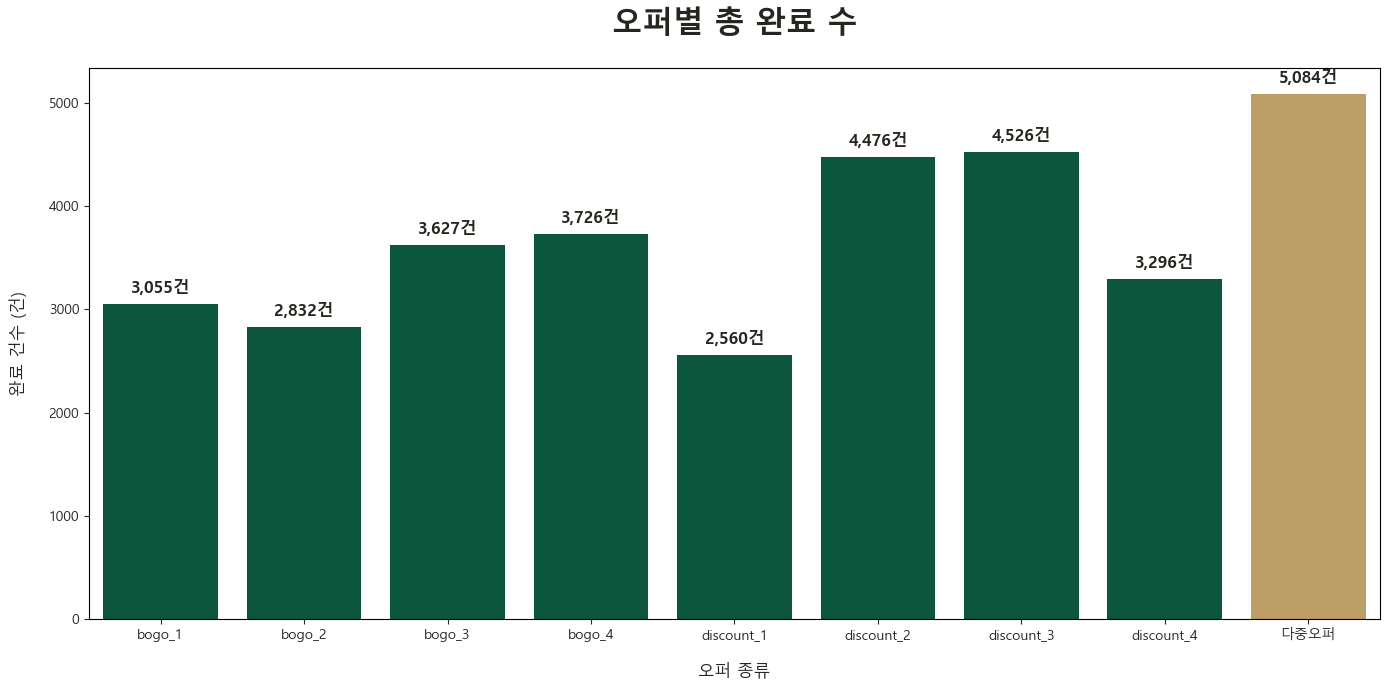

In [14]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(data=plot_data, x='final_label', y='총완료수', palette=colors)

plt.title('오퍼별 총 완료 수', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료 건수 (건)', fontsize=12, labelpad=15)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 4. 오퍼별 완료율 (%)

완료율 계산: (총완료수 / 총발송수) * 100

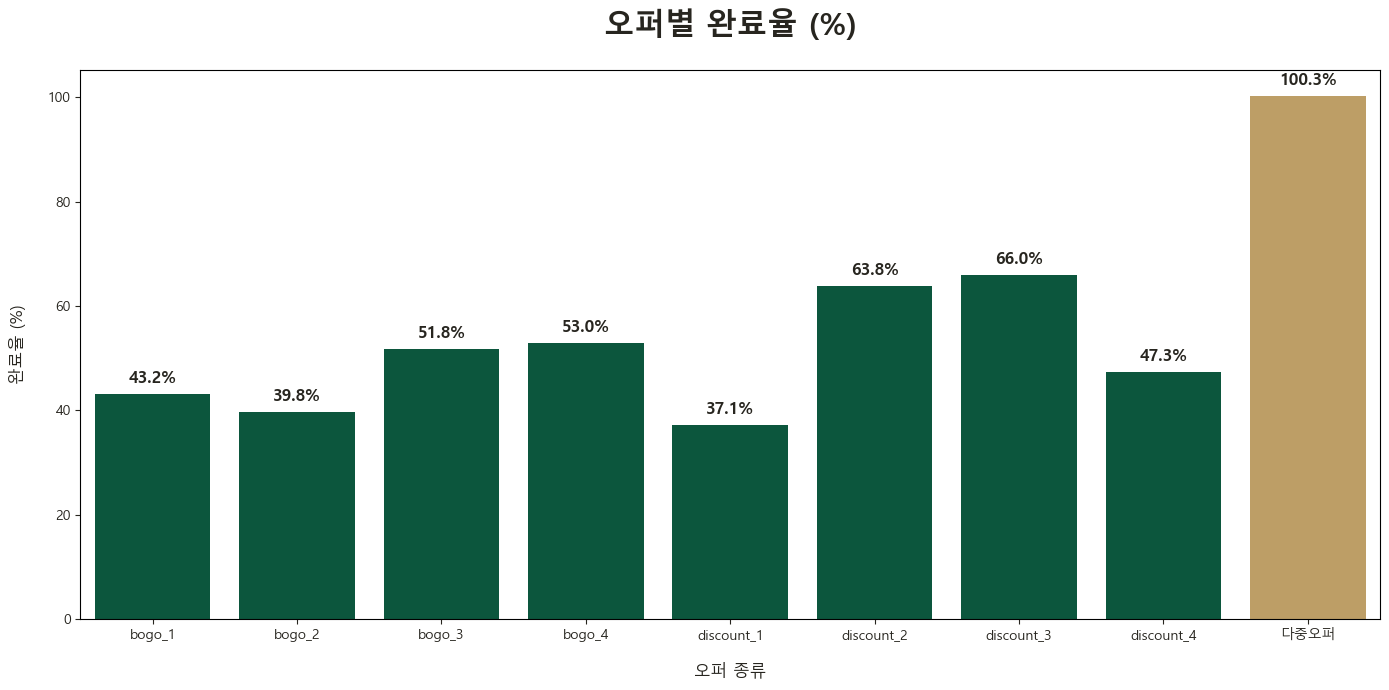

In [15]:
funnel_df['완료율(%)'] = (funnel_df['총완료수'] / funnel_df['총발송수']) * 100

plt.figure(figsize=(14, 7))

plot_data = funnel_df.reset_index()

ax = sns.barplot(data=plot_data, x='final_label', y='완료율(%)', palette=colors)

plt.title('오퍼별 완료율 (%)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=15)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 5. 결제 카테고리별 총 연계 매출 (오퍼8종 + 다중오퍼 + 일반 결제)

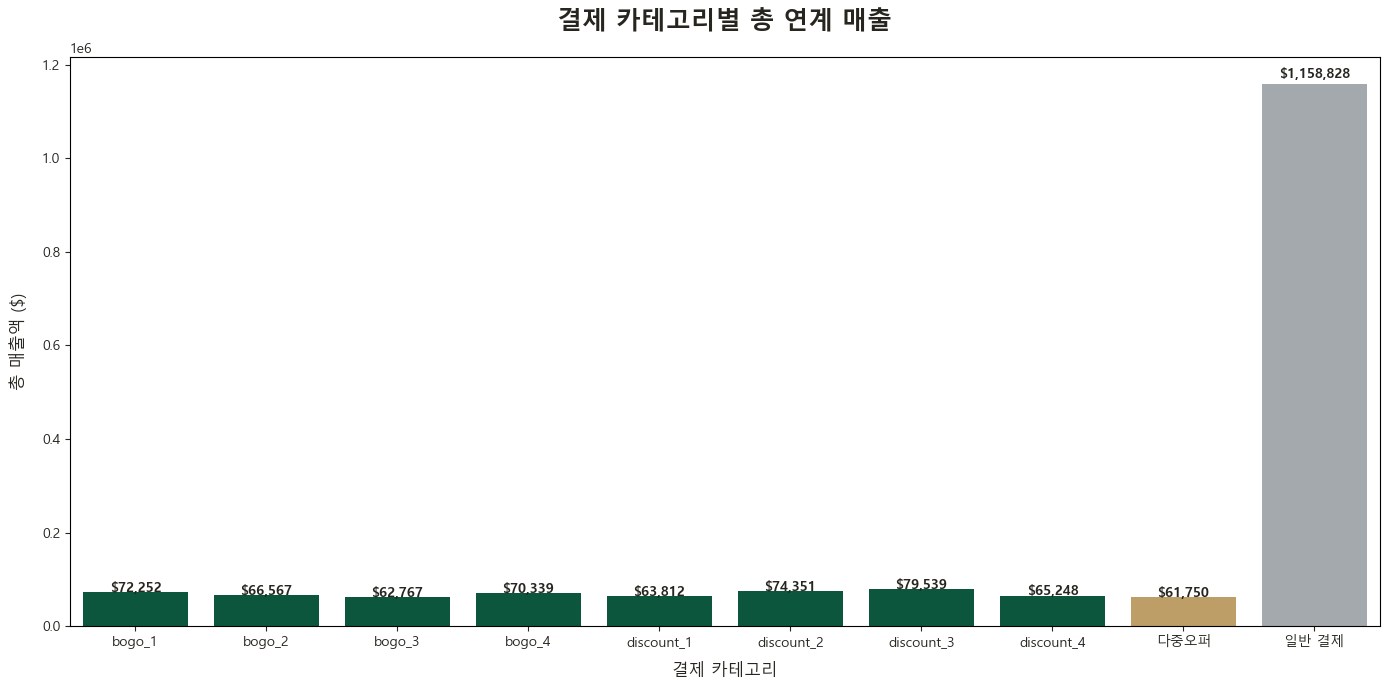

,final_label,amount
0,bogo_1,72251.56
1,bogo_2,66567.32
2,bogo_3,62767.30
3,bogo_4,70338.90
4,discount_1,63811.75
5,discount_2,74350.56
6,discount_3,79538.92
7,discount_4,65247.52
8,다중오퍼,61749.85
9,일반 결제,1158828.29


In [16]:
# 결제 카테고리별 매출액 집계
rev_by_offer = transaction_df.groupby('final_label')['amount'].sum().reset_index()

plt.figure(figsize=(14, 7))

def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in rev_by_offer['final_label']]

ax = sns.barplot(data=rev_by_offer, x='final_label', y='amount', palette=colors)

plt.title('결제 카테고리별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

for i, v in enumerate(rev_by_offer['amount']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

display(rev_by_offer)

### 결제 카테고리별 총 연계매출 - 합산본

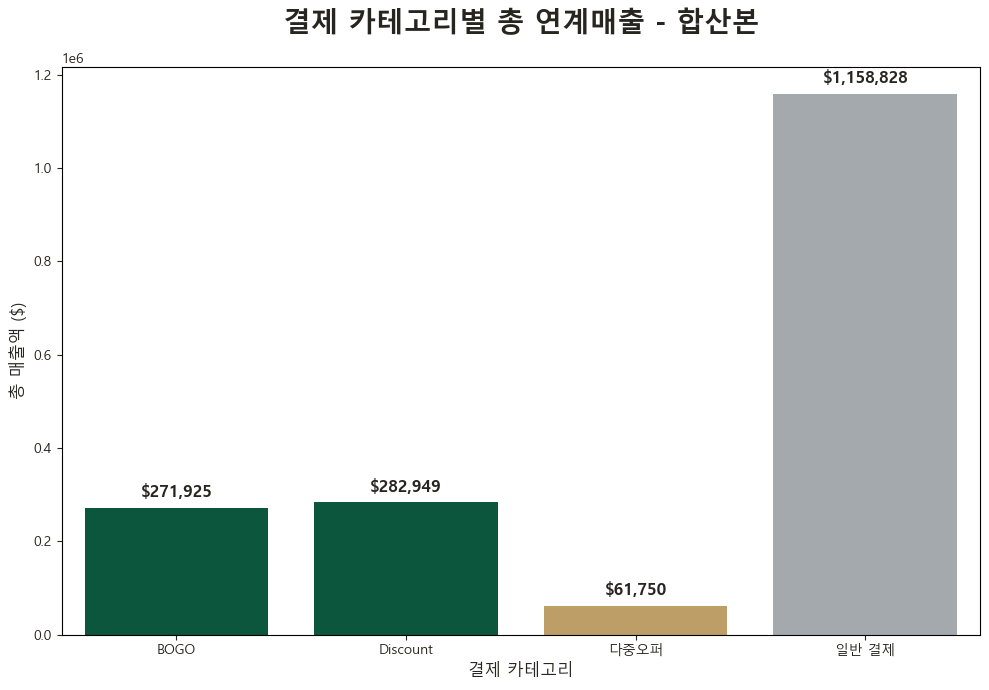

,group,amount
0,BOGO,271925.08
1,Discount,282948.75
2,다중오퍼,61749.85
3,일반 결제,1158828.29


In [17]:
# 그룹화 데이터 준비
# 아까 만든 10종 매출 데이터(rev_by_offer)
summary_4 = rev_by_offer.copy()

def get_group_4(label):
    if 'bogo' in label.lower(): return 'BOGO'
    elif 'discount' in label.lower(): return 'Discount'
    elif '다중' in label: return '다중오퍼'
    else: return '일반 결제'

summary_4['group'] = summary_4['final_label'].apply(get_group_4)

# 그룹별 매출 합계 계산
summary_4_final = summary_4.groupby('group')['amount'].sum().reset_index()

# 순서 고정
order_4 = ['BOGO', 'Discount', '다중오퍼', '일반 결제']
summary_4_final['group'] = pd.Categorical(summary_4_final['group'], categories=order_4, ordered=True)
summary_4_final = summary_4_final.sort_values('group')

plt.figure(figsize=(10, 7))

# 색상 매칭
colors_4 = [SB_GREEN, SB_GREEN, SB_GOLD, SB_GREY]

ax = sns.barplot(data=summary_4_final, x='group', y='amount', palette=colors_4)

plt.title('결제 카테고리별 총 연계매출 - 합산본', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=12)
plt.ylabel('총 매출액 ($)', fontsize=12)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 요약 표 출력
display(summary_4_final)

### 6. 오퍼별 발송당 평균 수익 (RPS)

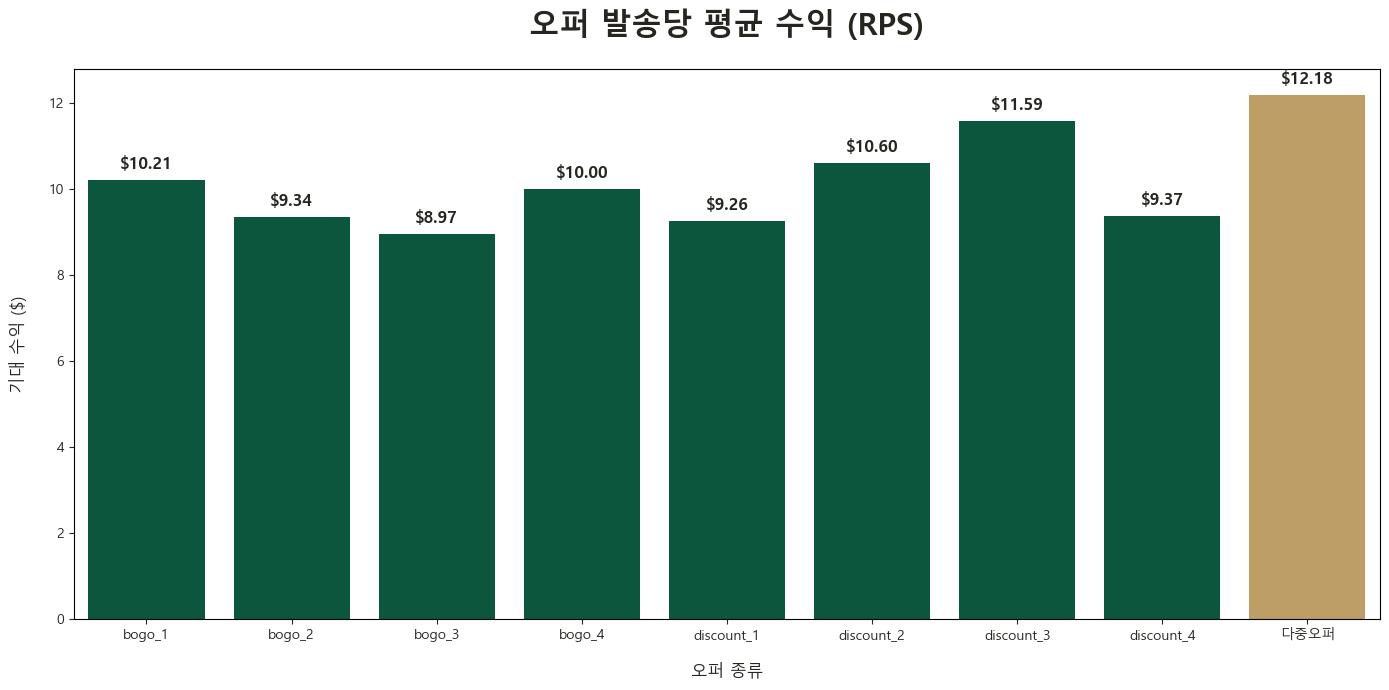

In [18]:
# 오퍼 연계 결제만 필터링
offer_txns = transaction_df[transaction_df['final_label'] != '일반 결제']

# 효율 지표 계산 
efficiency_df = pd.DataFrame({
    '총매출': offer_txns.groupby('final_label')['amount'].sum(),
    '결제인원수': offer_txns.groupby('final_label')['person'].nunique()
})

# RPS(발송당 기대수익) 계산 - funnel_df의 총발송수와 매칭
efficiency_df['발송1건당_매출'] = efficiency_df['총매출'] / funnel_df['총발송수']

# 순서 정렬
efficiency_df = efficiency_df.reindex(order)

# 그래프용 데이터 변환 
efficiency_plot_data = efficiency_df.reset_index()

plt.figure(figsize=(14, 7))

colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in efficiency_plot_data['final_label']]

ax = sns.barplot(data=efficiency_plot_data, x='final_label', y='발송1건당_매출', palette=colors)


plt.title('오퍼 발송당 평균 수익 (RPS)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('기대 수익 ($)', fontsize=12, labelpad=15)

for p in ax.patches:
    val = p.get_height()
    if pd.notnull(val): # 데이터가 있는 경우만 표시
        ax.annotate(f"${val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 7. 오퍼 완료당 평균 매출

완료당 평균 매출 = 총 매출 / 총 완료 수

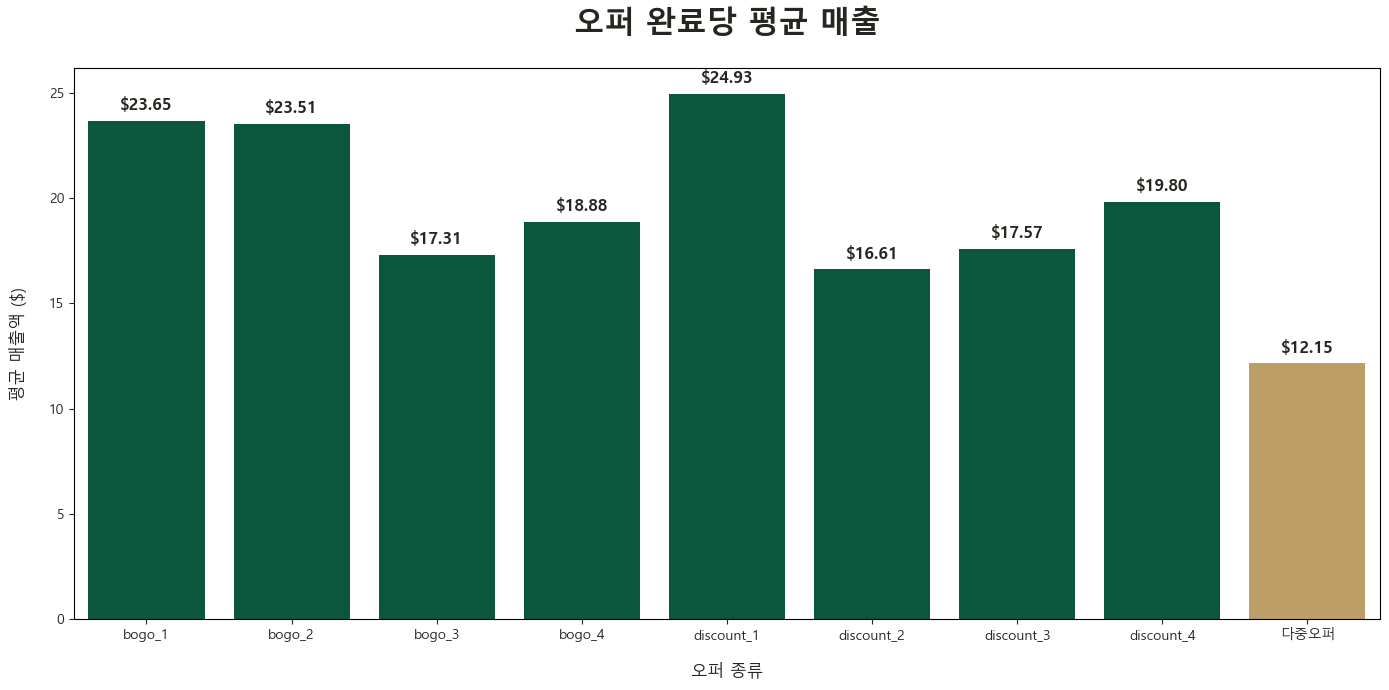

,총매출,완료당_평균_매출
final_label,,
bogo_1,72251.56,23.650265
bogo_2,66567.32,23.505410
bogo_3,62767.30,17.305569
bogo_4,70338.90,18.877858
discount_1,63811.75,24.926465
discount_2,74350.56,16.610938
discount_3,79538.92,17.573778
discount_4,65247.52,19.795971
다중오퍼,61749.85,12.145919


In [19]:
# efficiency_df에 '완료당_평균_매출' 컬럼 추가
efficiency_df['완료당_평균_매출'] = efficiency_df['총매출'] / funnel_df['총완료수']

# 그래프용 데이터 변환 
plot_data_comp = efficiency_df.reset_index()

plt.figure(figsize=(14, 7))

colors = [SB_GOLD if cat == '다중오퍼' else SB_GREEN for cat in plot_data_comp['final_label']]

ax = sns.barplot(data=plot_data_comp, x='final_label', y='완료당_평균_매출', palette=colors)

plt.title('오퍼 완료당 평균 매출', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('오퍼 종류', fontsize=12, labelpad=15)
plt.ylabel('평균 매출액 ($)', fontsize=12, labelpad=15)

for p in ax.patches:
    val = p.get_height()
    if pd.notnull(val):
        ax.annotate(f"${val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 확인용
display(efficiency_df[['총매출', '완료당_평균_매출']].head(10))

### 8. 인당 평균 결제액 (ARPPU)

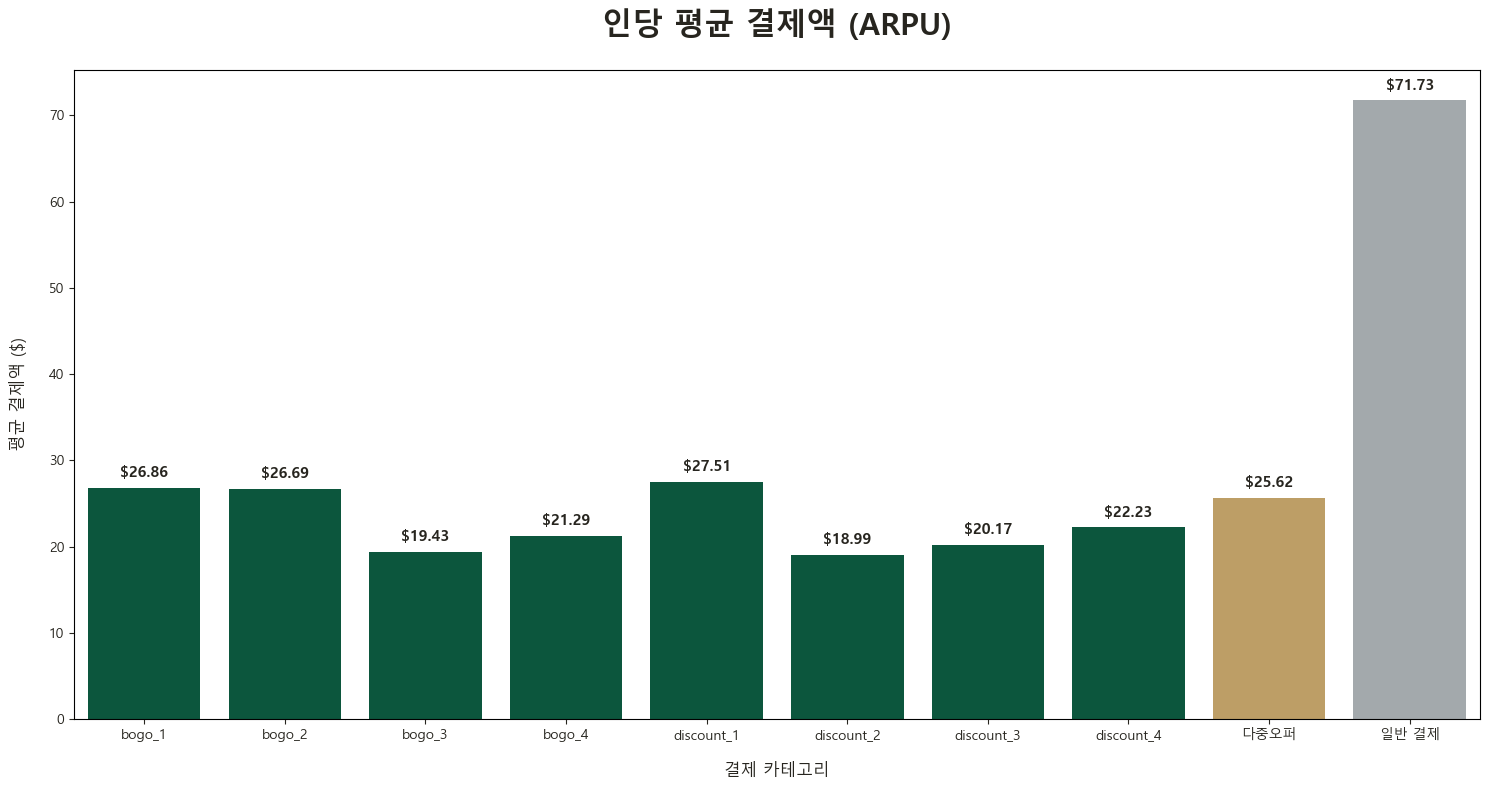

,final_label,총매출,결제인원수,ARPU
0,bogo_1,72251.56,2690,26.859316
1,bogo_2,66567.32,2494,26.690986
2,bogo_3,62767.30,3230,19.432601
3,bogo_4,70338.90,3304,21.289013
4,discount_1,63811.75,2320,27.505065
5,discount_2,74350.56,3915,18.991203
6,discount_3,79538.92,3944,20.167069
7,discount_4,65247.52,2935,22.230842
8,다중오퍼,61749.85,2410,25.622344
9,일반 결제,1158828.29,16156,71.727426


In [20]:
# 카테고리별 총매출액과 순수 결제 인원수 계산
arppu_df = transaction_df.groupby('final_label').agg({
    'amount': 'sum',
    'person': 'nunique'
}).reset_index()

# 컬럼 이름 변경 및 ARPPU 계산
arppu_df.columns = ['final_label', '총매출', '결제인원수']
arppu_df['ARPU'] = arppu_df['총매출'] / arppu_df['결제인원수']

arppu_df['final_label'] = pd.Categorical(arppu_df['final_label'], ordered=True)
arppu_df = arppu_df.sort_values('final_label')


plt.figure(figsize=(15, 8))

# 색상 설정 
colors = [SB_GREY if cat == '일반 결제' else (SB_GOLD if cat == '다중오퍼' else SB_GREEN) for cat in arppu_df['final_label']]

ax = sns.barplot(data=arppu_df, x='final_label', y='ARPU', palette=colors)


plt.title('인당 평균 결제액 (ARPU)', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=15)
plt.ylabel('평균 결제액 ($)', fontsize=12, labelpad=15)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

# 데이터 요약 표 출력
display(arppu_df[['final_label', '총매출', '결제인원수', 'ARPU']])

### 9. 오퍼별 평균 완료 소요 시간 (Received → Completed)

In [21]:
# received / completed 이벤트 추출
selected_received_data = noinfo_merge_df[noinfo_merge_df['event'] == 'received'][['person', 'offer_id', 'offer_label', 'receive_seq', 'time']].copy()
selected_completed_data = noinfo_merge_df[noinfo_merge_df['event'] == 'completed'][['person', 'offer_id', 'offer_label', 'receive_seq', 'time']].copy()

# 컬럼명 변경
selected_received_data = selected_received_data.rename(columns={'time': 'received_time'})
selected_completed_data = selected_completed_data.rename(columns={'time': 'completed_time'})

# 같은 오퍼 인스턴스 기준으로 연결
time_df = pd.merge(
    selected_completed_data,
    selected_received_data,
    on=['person', 'offer_id', 'offer_label', 'receive_seq'],
    how='left'
)

# 완료까지 걸린 시간 계산
time_df['time_to_complete'] = time_df['completed_time'] - time_df['received_time']

# 이상치 제거
time_df = time_df[time_df['time_to_complete'] >= 0]

# 오퍼별 평균 완료 소요 시간
avg_completion_time = (
    time_df.groupby('offer_label')['time_to_complete']
    .mean()
    .sort_values()
)

print("오퍼별 평균 완료 소요 시간")
print(avg_completion_time)

오퍼별 평균 완료 소요 시간
offer_label
bogo_4         42.316753
bogo_2         42.338079
bogo_1         54.465475
discount_2     56.992958
bogo_3         58.139902
discount_4     63.850656
discount_3     72.410256
discount_1    101.482635
Name: time_to_complete, dtype: float64


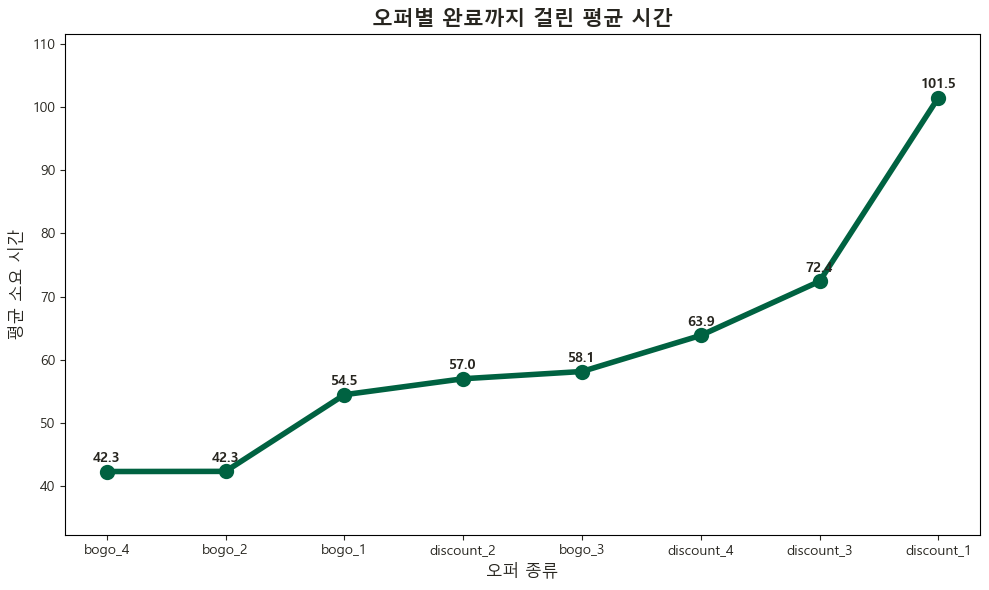

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    avg_completion_time.index,
    avg_completion_time.values,
    marker='o',
    linestyle='-',
    linewidth=4,
    markersize=8,
    color=SB_GREEN,
    markeredgewidth=3
)

y_min = avg_completion_time.min() - 10
y_max = avg_completion_time.max() + 10
plt.ylim(y_min, y_max)

for i, v in enumerate(avg_completion_time.values):
    plt.text(i, v + 1.5, f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.title('오퍼별 완료까지 걸린 평균 시간', fontsize=15, fontweight='bold')
plt.xlabel('오퍼 종류', fontsize=12)
plt.ylabel('평균 소요 시간', fontsize=12)

plt.tight_layout()
plt.show()

# 3. 채널별 

### 1. 채널 관여별 오퍼 발송 수

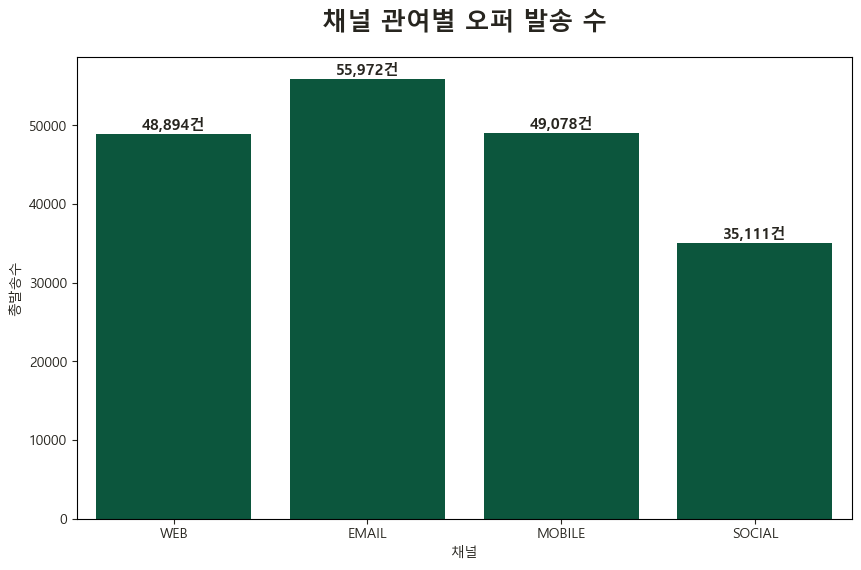

In [23]:
channels = ['web', 'email', 'mobile', 'social']
# 8종 개별 오퍼만 대상
offer_8_labels = ['bogo_1', 'bogo_2', 'bogo_3', 'bogo_4', 'discount_1', 'discount_2', 'discount_3', 'discount_4']
channel_base = master_df[(master_df['final_label'].isin(offer_8_labels)) & (master_df['event'] == 'received')]

# 채널별 컬럼 합계 구하기
channel_sent = channel_base[channels].sum().reset_index()
channel_sent.columns = ['채널', '총발송수']
channel_sent['채널'] = channel_sent['채널'].str.upper()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=channel_sent, 
                x='채널', y='총발송수', palette=[SB_GREEN]) 

plt.title('채널 관여별 오퍼 발송 수', fontsize=18, fontweight='bold', pad=20)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}건", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

### 2. 채널 관여별 오퍼 열람률 (%)

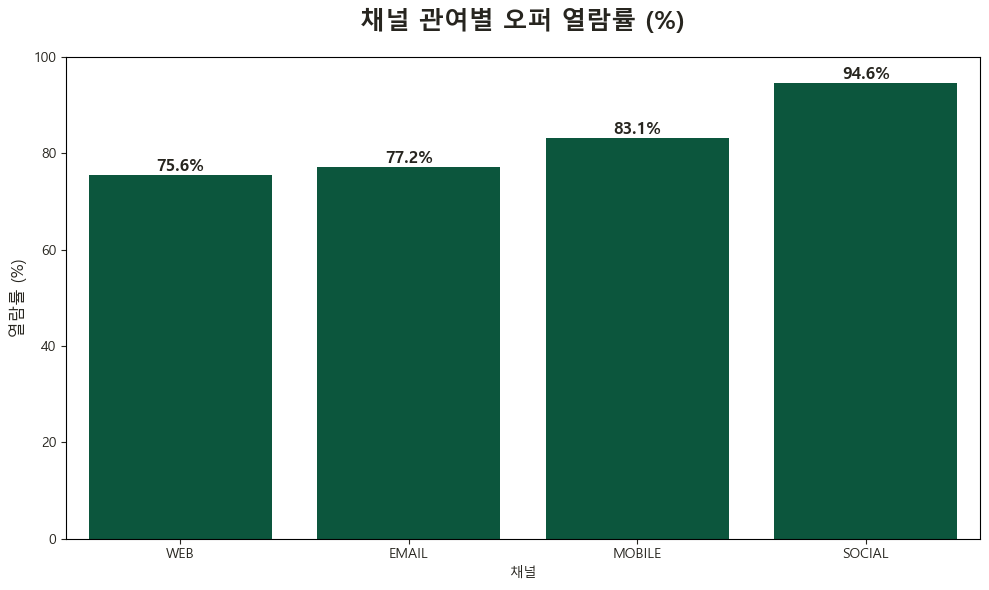

In [24]:
# 채널이 포함된 오퍼 열람률 계산 (Viewed / Received)

# 8종 개별 오퍼만 필터링
offer_8_df = master_df[master_df['final_label'].isin(offer_8_labels)]


# 채널별 발송 수와 열람 수) 집계
sent_by_channel = offer_8_df[offer_8_df['event'] == 'received'][channels].sum()
viewed_by_channel = offer_8_df[offer_8_df['event'] == 'viewed'][channels].sum()

# 열람률(%) 계산
channel_view_rate = (viewed_by_channel / sent_by_channel * 100).reset_index()
channel_view_rate.columns = ['채널', '열람률']
channel_view_rate['채널'] = channel_view_rate['채널'].str.upper()


plt.figure(figsize=(10, 6))

ax = sns.barplot(data=channel_view_rate, 
                x='채널', y='열람률', color=SB_GREEN)

plt.title('채널 관여별 오퍼 열람률 (%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('열람률 (%)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

### 3. 채널 관여별 오퍼 완료율 (%)

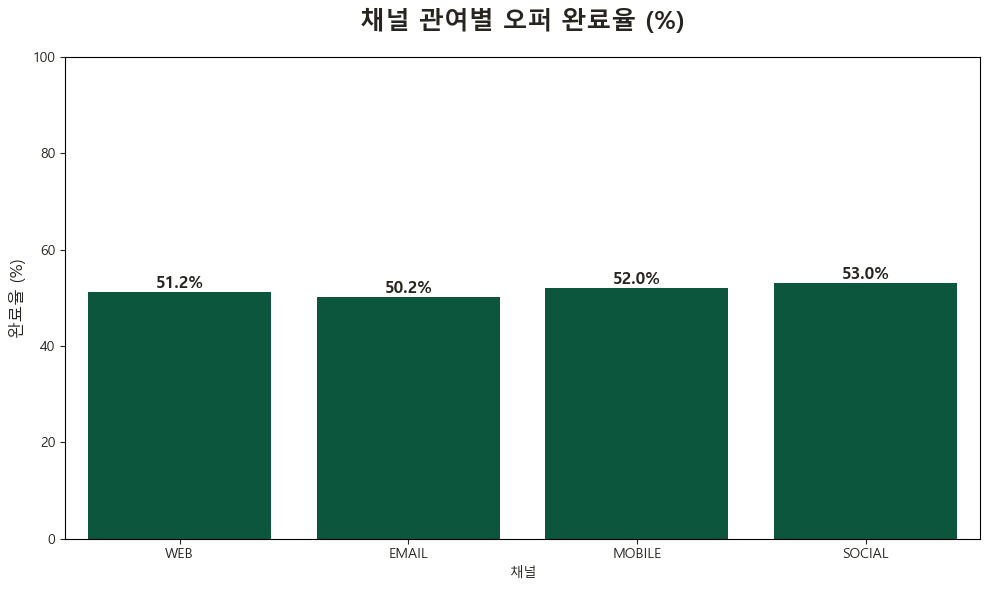

In [25]:
# 채널이 포함된 오퍼의 전략적 완료율 계산 (Completed / Received)

# 채널별 발송 수와 완료 수 집계
completed_by_channel = offer_8_df[offer_8_df['event'] == 'completed'][channels].sum()

# 완료율(%) 계산: (총완료수 / 총발송수) * 100
channel_complete_rate = (completed_by_channel / sent_by_channel * 100).reset_index()
channel_complete_rate.columns = ['채널', '완료율']
channel_complete_rate['채널'] = channel_complete_rate['채널'].str.upper()


plt.figure(figsize=(10, 6))

ax = sns.barplot(data=channel_complete_rate, 
                x='채널', y='완료율', color=SB_GREEN)

plt.title('채널 관여별 오퍼 완료율 (%)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('완료율 (%)', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 100) 
plt.tight_layout()
plt.show()

### 4. 채널 관여별 총 매출

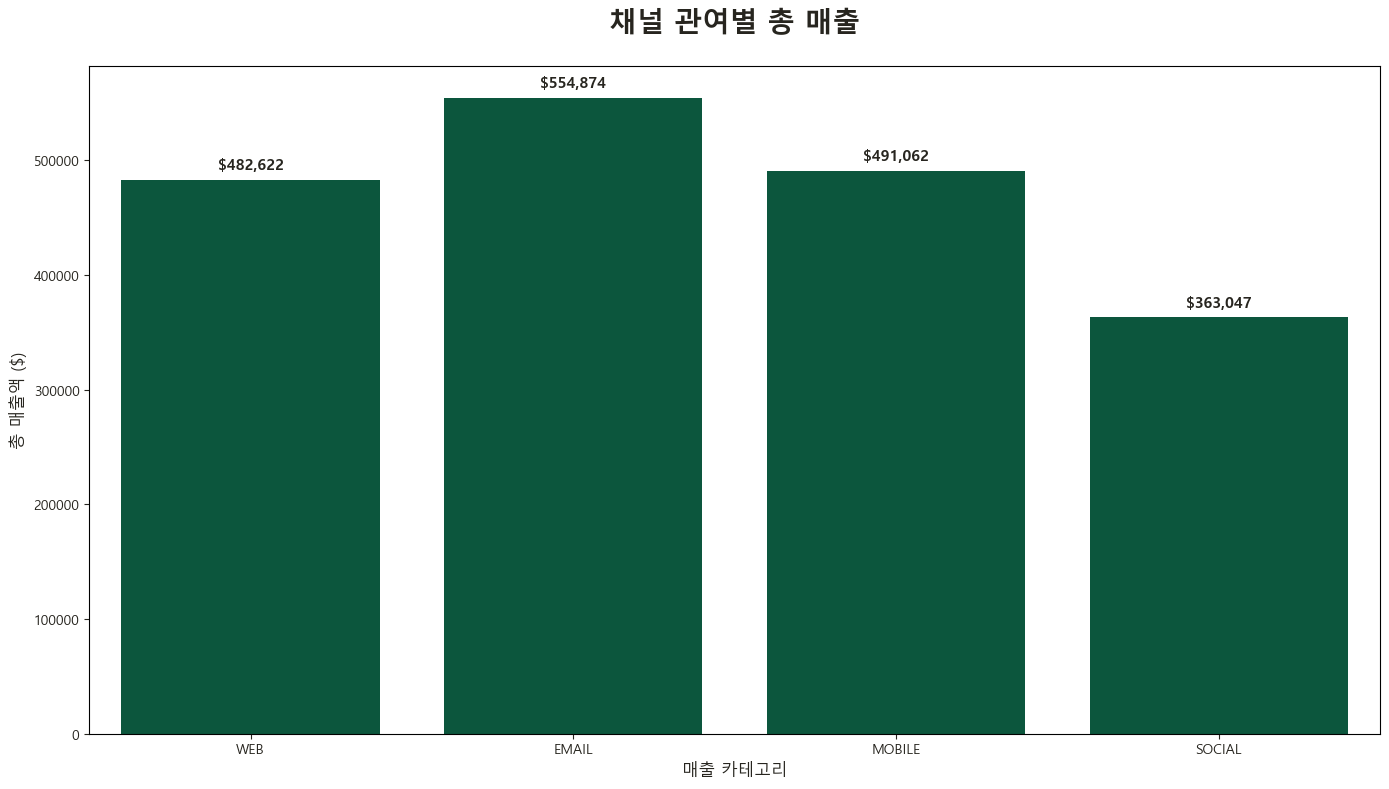

In [26]:
# 오퍼별 채널 매핑 정보 추출
offer_channel_map = offer_8_df[['offer_label'] + channels].drop_duplicates()

# 4대 채널 매출액 계산
channel_total_rev = []
for ch in channels:
    # 해당 채널을 포함하는 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    # 해당 오퍼들의 매출 합산
    ch_sum = rev_by_offer[rev_by_offer['final_label'].isin(linked_offers)]['amount'].sum()
    channel_total_rev.append({'category': ch.upper(), 'amount': ch_sum})


# 데이터프레임 변환
df_final_revenue = pd.DataFrame(channel_total_rev)


plt.figure(figsize=(14, 8))

ax = sns.barplot(data=df_final_revenue, x='category', y='amount', color=SB_GREEN)

plt.title('채널 관여별 총 매출', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('총 매출액 ($)', fontsize=12)
plt.xlabel('매출 카테고리', fontsize=12)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:,.0f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 5. 채널 관여별 오퍼 완료당 평균 매출

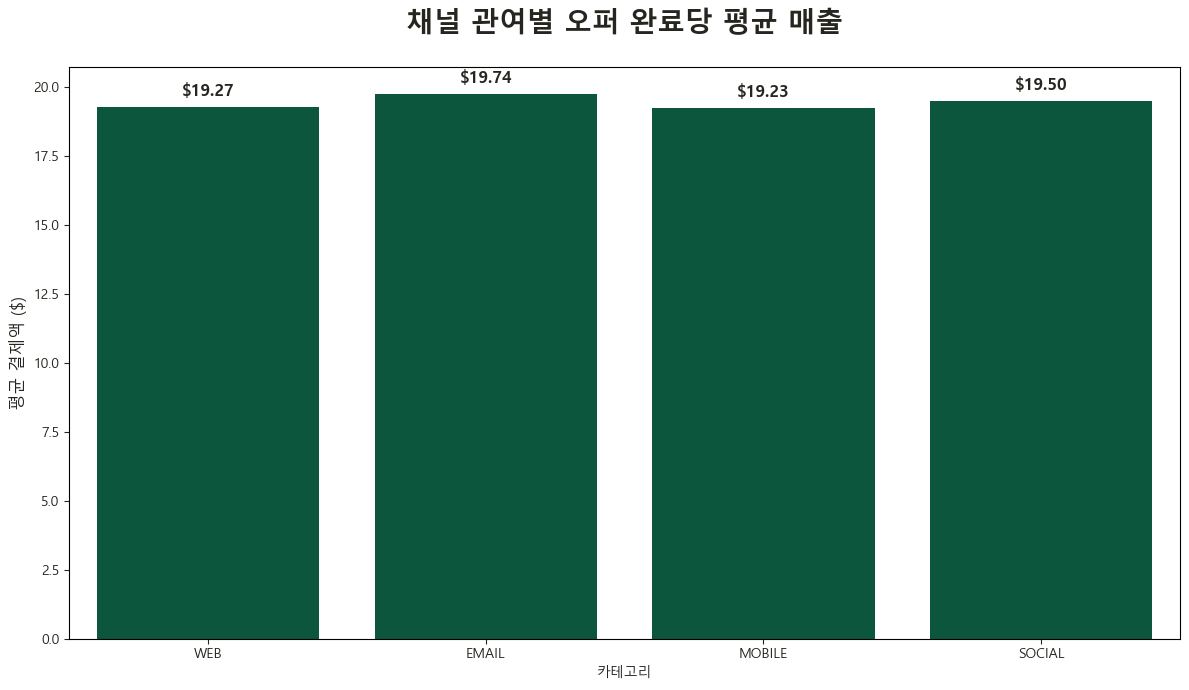

In [27]:
# 채널이 포함된 오퍼의 완료당 매출 계산
channel_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼의 완료(completed) 
    ch_comps = master_df[(master_df['event'] == 'completed') & 
                        (master_df['final_label'].isin(offer_8_labels)) & 
                        (master_df[ch] == 1)]
    
    # 해당 완료 건의 총 매출액 매칭
    ch_rev = pd.merge(ch_comps[['person', 'time']], 
                    trans_df[['person', 'time', 'amount']], 
                    on=['person', 'time'], how='inner')['amount'].sum()
    
    ch_count = len(ch_comps)
    avg_val = ch_rev / ch_count if ch_count > 0 else 0
    channel_data.append({'카테고리': ch.upper(), '완료당_평균_매출': avg_val})


# 데이터 합치기
df_comp_final = pd.DataFrame(channel_data)


plt.figure(figsize=(12, 7))


ax = sns.barplot(data=df_comp_final, 
                x='카테고리', y='완료당_평균_매출', color=SB_GREEN)

plt.title('채널 관여별 오퍼 완료당 평균 매출', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('평균 결제액 ($)', fontsize=12)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 6. 채널 관여별 총 거래 횟수

이 채널이 포함된 오퍼들이 얼마나 많은 결제를 이끌어냈는가

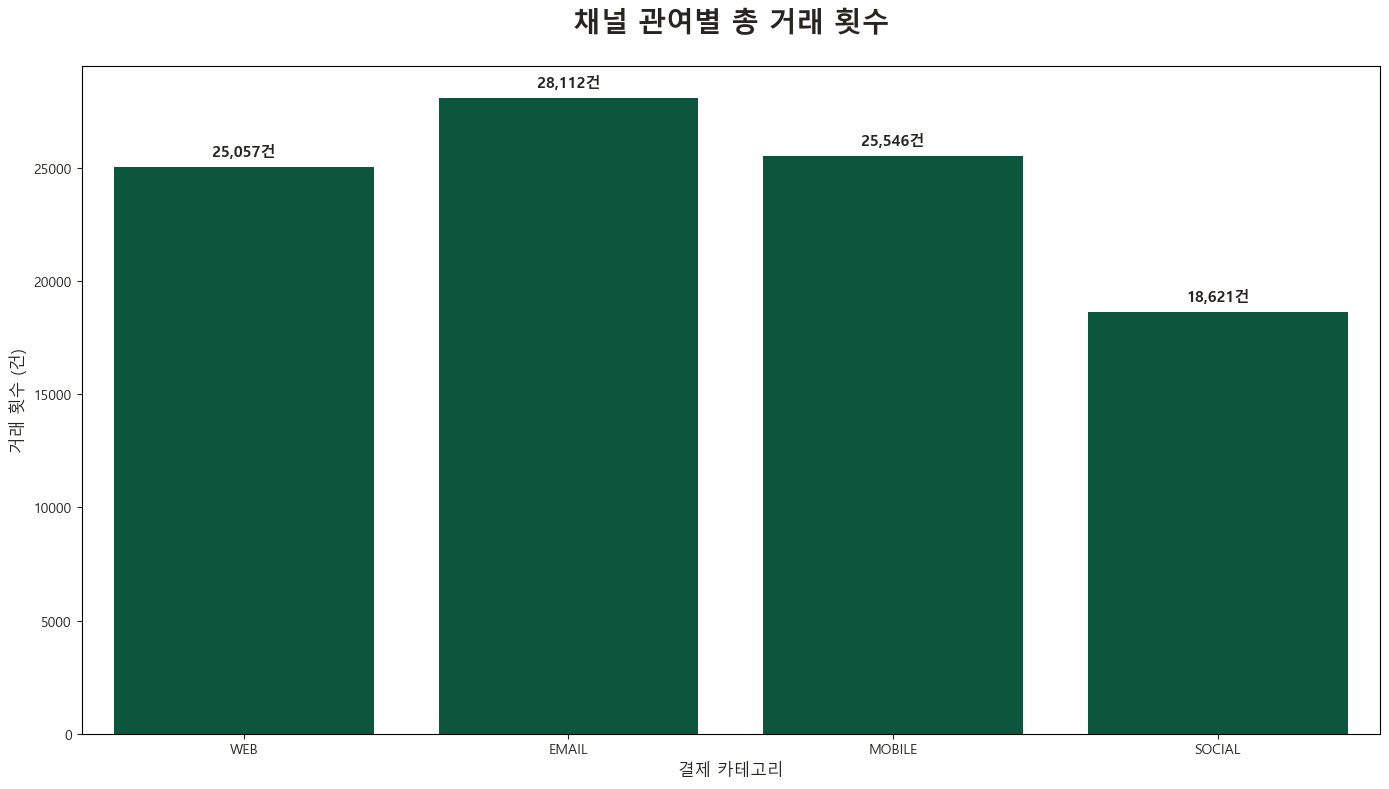

In [28]:
# 오퍼별 거래 횟수 계산 (trans_df 활용)
counts_by_offer = transaction_df.groupby('final_label').size().reset_index(name='count')


channel_counts = []
for ch in channels:
    # 해당 채널을 포함하는 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    # 해당 오퍼들의 거래 횟수 합산
    ch_sum = counts_by_offer[counts_by_offer['final_label'].isin(linked_offers)]['count'].sum()
    channel_counts.append({'category': ch.upper(), 'count': ch_sum})


df_final_counts = pd.DataFrame(channel_counts)


plt.figure(figsize=(14, 8))

ax = sns.barplot(data=df_final_counts, x='category', y='count', color=SB_GREEN)

plt.title('채널 관여별 총 거래 횟수', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('거래 횟수 (건)', fontsize=12)
plt.xlabel('결제 카테고리', fontsize=12)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"{int(val):,}건", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 7. 채널 관여별 RPS (발송 1건당 평균 매출)

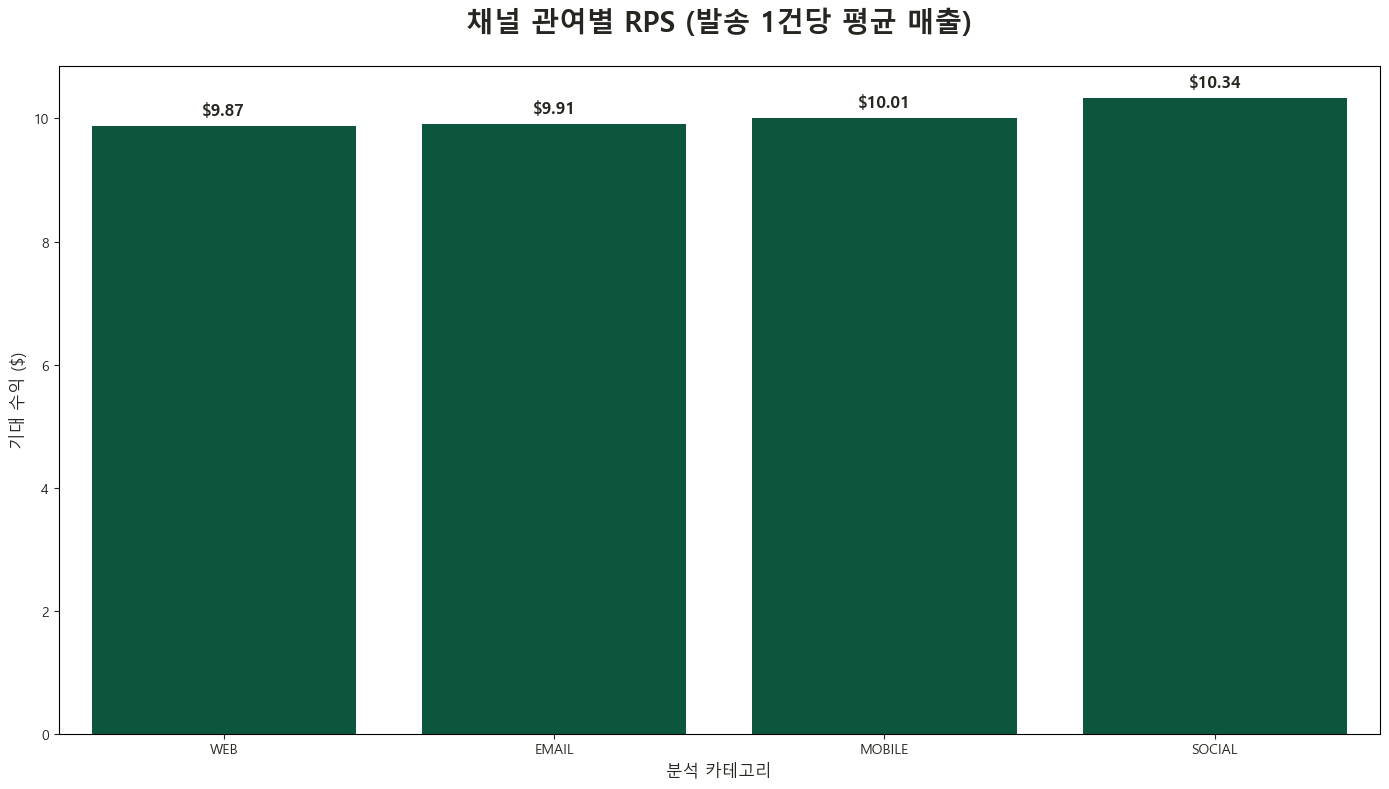

In [29]:
# 카테고리별 RPS 계산 (Revenue / Sent)
# 오퍼별 매출액 집계
rev_by_label = transaction_df.groupby('final_label')['amount'].sum()
rps_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼의 발송 건수
    ch_sent = master_df[(master_df['event'] == 'received') & 
                        (master_df['final_label'].isin(offer_8_labels)) & 
                        (master_df[ch] == 1)].shape[0]
    
    # 해당 채널을 포함하는 오퍼들의 총 매출액
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    ch_rev = rev_by_label[rev_by_label.index.isin(linked_offers)].sum()
    
    # RPS 계산
    ch_rps = ch_rev / ch_sent if ch_sent > 0 else 0
    rps_data.append({'category': ch.upper(), 'RPS': ch_rps})


df_rps = pd.DataFrame(rps_data)


plt.figure(figsize=(14, 8))

ax = sns.barplot(data=df_rps, 
                x='category', y='RPS', color = SB_GREEN)

plt.title('채널 관여별 RPS (발송 1건당 평균 매출)', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('기대 수익 ($)', fontsize=12)
plt.xlabel('분석 카테고리', fontsize=12)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 8. 채널 관여별 ARPPU (인당 평균 결제액)

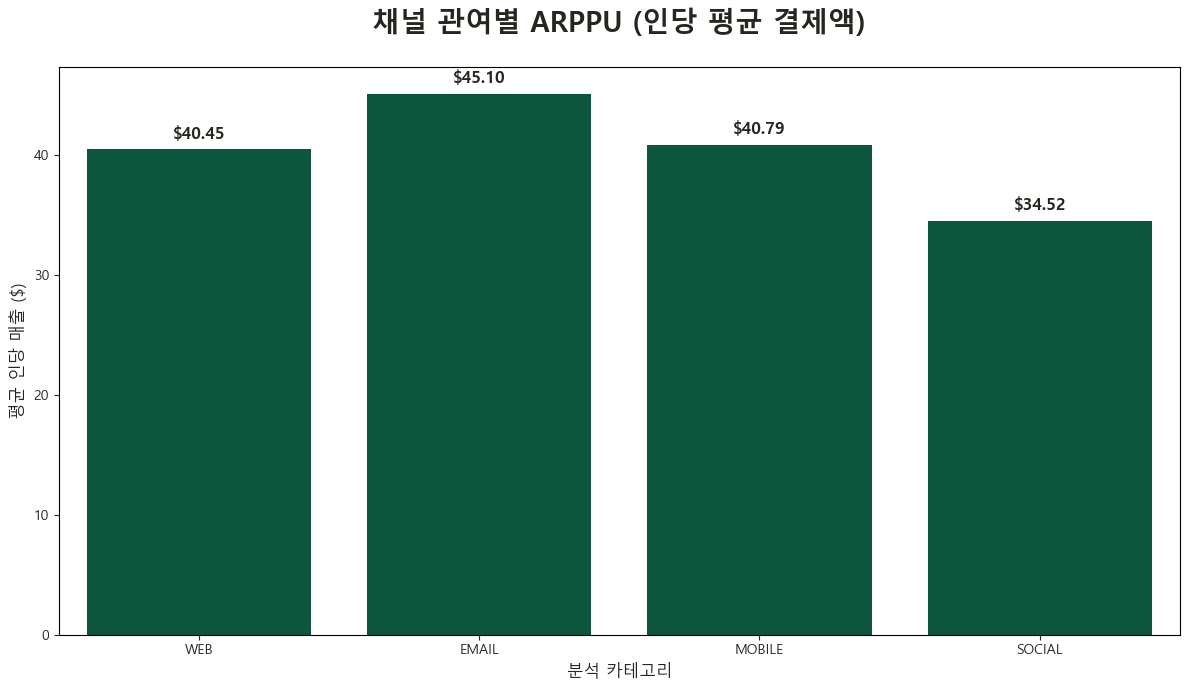

In [30]:
# 5개 카테고리 ARPPU 계산 (인당 평균 결제액)
arppu_data = []

for ch in channels:
    # 해당 채널을 포함하는 8종 오퍼들 찾기
    linked_offers = offer_channel_map[offer_channel_map[ch] == 1]['offer_label'].tolist()
    
    # 해당 채널 오퍼를 이용한 총 매출과 '순수 결제 인원수'
    ch_trans = transaction_df[transaction_df['final_label'].isin(linked_offers)]
    ch_rev = ch_trans['amount'].sum()
    ch_users = ch_trans['person'].nunique()
    
    # ARPPU 계산
    ch_arppu = ch_rev / ch_users if ch_users > 0 else 0
    arppu_data.append({'category': ch.upper(), 'ARPU': ch_arppu})


# 데이터프레임 변환
df_arppu = pd.DataFrame(arppu_data)


plt.figure(figsize=(12, 7))

ax = sns.barplot(data=df_arppu, x='category', y='ARPU', color = SB_GREEN)

plt.title('채널 관여별 ARPPU (인당 평균 결제액)', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('평균 인당 매출 ($)', fontsize=12)
plt.xlabel('분석 카테고리', fontsize=12)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f"${val:.2f}", 
                (p.get_x() + p.get_width() / 2., val), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontsize=12, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

### 9. 채널별 고객 수

각 채널별로 값이 1인 행들에서 고유한 'person' 수를 집계

해당 채널 값이 1인 데이터만 필터링해서 고유 인원수 체크

In [31]:
df[['web','email','mobile','social']].head()

,web,email,mobile,social
0,1.0,1.0,1.0,0.0
1,1.0,1.0,1.0,0.0
2,1.0,1.0,1.0,0.0
3,1.0,1.0,1.0,0.0
4,0.0,1.0,1.0,1.0


채널별 고유 고객 수
  Channel  Unique_Customers
1   email             16994
2  mobile             16980
0     web             16916
3  social             16529


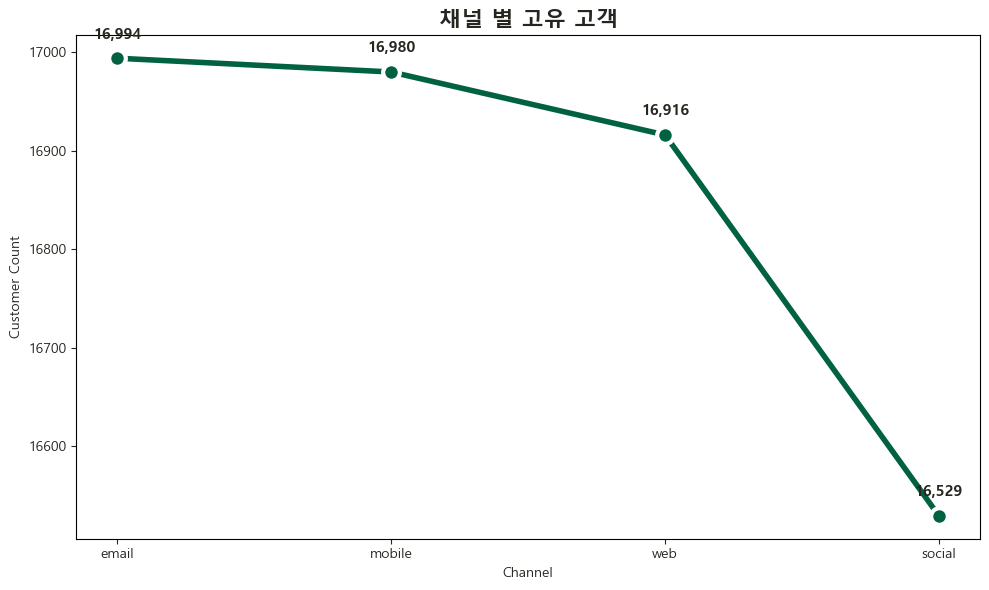

In [32]:
channel_customer_counts = {}
for ch in channels:
    unique_cnt = df[df[ch] == 1]['person'].nunique()
    channel_customer_counts[ch] = unique_cnt


channel_df = pd.DataFrame(list(channel_customer_counts.items()), columns=['Channel', 'Unique_Customers'])
channel_df = channel_df.sort_values(ascending=False,by='Unique_Customers')

print("채널별 고유 고객 수")
print(channel_df)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(data=channel_df, x='Channel', y='Unique_Customers', 
                marker='o', markersize=12, linewidth=4, 
                color=SB_GREEN,  
                markeredgewidth=3)

for i, val in enumerate(channel_df['Unique_Customers']):
    plt.text(i, val + 20, f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.title('채널 별 고유 고객', fontsize=16, fontweight='bold')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

# 4. Completed 관련

### completed된 거래 중 viewed 단계 여부

쿠폰 보고 완료: 27,534 건
쿠폰 안 보고 완료: 5,648 건


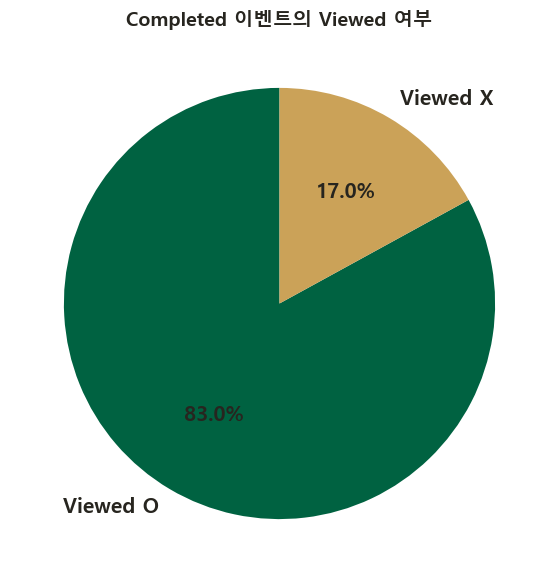

In [33]:
completed_data = noinfo_merge_df[noinfo_merge_df['event'] == 'completed']
viewed_data = noinfo_merge_df[noinfo_merge_df['event'] == 'viewed']

viewed_users = viewed_data[['person', 'offer_id', 'receive_seq']].drop_duplicates()
viewed_users['is_viewed'] = True

check_df = pd.merge(
    completed_data,
    viewed_users,
    on=['person', 'offer_id', 'receive_seq'],
    how='left'
)
check_df['is_viewed'] = check_df['is_viewed'].fillna(False)

true_roi = len(check_df[check_df['is_viewed'] == True])
accidental_roi = len(check_df[check_df['is_viewed'] == False])

print(f"쿠폰 보고 완료: {true_roi:,} 건")
print(f"쿠폰 안 보고 완료: {accidental_roi:,} 건")


view_labels = ['Viewed O', 'Viewed X']
sizes = [true_roi, accidental_roi]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=view_labels, colors=[SB_GREEN, SB_GOLD],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 15, 'fontweight': 'bold'})


plt.title('Completed 이벤트의 Viewed 여부', fontsize=14, fontweight='bold')
plt.show()

### 오퍼 효율 분석

In [34]:
df_core = df[df['offer_label'].notna()].copy()
df_core = df_core[~df_core['offer_label'].str.contains('informational', na=False)]

print(df_core['offer_label'].value_counts())

core_received_cnt = (
    df_core[df_core['event'] == 'received']
    .groupby('offer_label')['customer_id']
    .count()
)

core_viewed_cnt = (
    df_core[df_core['event'] == 'viewed']
    .groupby('offer_label')['customer_id']
    .count()
)

# 같은 고객이 같은 오퍼 인스턴스를 여러 번 본 경우 1건만 남김
viewed_events = (
    df_core[df_core['event'] == 'viewed'][
        ['customer_id', 'offer_id', 'offer_label', 'receive_seq', 'time']
    ]
    .rename(columns={'time': 'viewed_time'})
    .drop_duplicates(subset=['customer_id', 'offer_id', 'receive_seq'])
)

completed_events = (
    df_core[df_core['event'] == 'completed'][
        ['customer_id', 'offer_id', 'offer_label', 'receive_seq', 'time']
    ]
    .rename(columns={'time': 'completed_time'})
)

# 같은 고객 + 같은 오퍼 인스턴스 기준으로 viewed와 completed 연결
true_comp_df = pd.merge(
    completed_events,
    viewed_events[['customer_id', 'offer_id', 'receive_seq', 'viewed_time']],
    on=['customer_id', 'offer_id', 'receive_seq'],
    how='left'
)

# viewed 이후 completed 된 경우만 true completion으로 인정
true_comp_df = true_comp_df[
    (true_comp_df['viewed_time'].notna()) &
    (true_comp_df['viewed_time'] <= true_comp_df['completed_time'])
]

true_completed_cnt = (
    true_comp_df.groupby('offer_label')['customer_id']
    .count()
)

print("\nViewed -> Completed 만족")
print(true_completed_cnt)

offer_label
discount_3    20189
discount_2    20095
bogo_4        19097
bogo_2        18192
bogo_1        18009
bogo_3        16151
discount_4    15714
discount_1    13671
Name: count, dtype: int64

Viewed -> Completed 만족
offer_label
bogo_1        2582
bogo_2        2739
bogo_3        2106
bogo_4        3514
discount_1    1312
discount_2    4357
discount_3    4610
discount_4    2107
Name: customer_id, dtype: int64


In [35]:
# y축 : 발송 1건당 매출
transactions2 = df[df['event'] == 'transaction'][['customer_id', 'time', 'amount']]

true_completions_for_rev = true_comp_df[['customer_id', 'completed_time', 'offer_label']].rename(columns={'completed_time': 'time'})

# 오퍼 완료한 순간의 거래만 가져옴
matched_sales = pd.merge(transactions2, true_completions_for_rev, on=['customer_id', 'time'], how='inner')

# 오퍼별 총 매출 집계
revenue_df = matched_sales.groupby('offer_label').agg(
    total_offer_revenue=('amount', 'sum')
)

revenue_df

,total_offer_revenue
offer_label,
bogo_1,61508.30
bogo_2,65289.48
bogo_3,37422.05
bogo_4,70093.72
discount_1,34749.94
discount_2,74064.04
discount_3,82970.77
discount_4,42295.48


KPI 통합

In [36]:
#KPI 통합 
final_kpi_df = pd.DataFrame({
    'received_cnt': core_received_cnt,
    'viewed_cnt': core_viewed_cnt,
    'true_completed_cnt': true_completed_cnt
}).fillna(0).join(revenue_df).fillna(0)

final_kpi_df

,received_cnt,viewed_cnt,true_completed_cnt,total_offer_revenue
offer_label,,,,
bogo_1,7658,6716,2582,61508.30
bogo_2,7593,7298,2739,65289.48
bogo_3,7677,4171,2106,37422.05
bogo_4,7571,7264,3514,70093.72
discount_1,7668,2663,1312,34749.94
discount_2,7646,7337,4357,74064.04
discount_3,7597,7327,4610,82970.77
discount_4,7632,4118,2107,42295.48


X축 : 실제 완료율 = 실제 완료 수 / 총 발송 수 (여기서 실제란 Viewed -> Completed 과정을 거침)

Y축 : 발송 1건당 매출 = 총 오퍼 연계 매출 / 총 발송 수

In [37]:
final_kpi_df['true_completed_rate'] = (final_kpi_df['true_completed_cnt'] / final_kpi_df['received_cnt'] * 100).round(2)

final_kpi_df['revenue_per_send'] = (final_kpi_df['total_offer_revenue'] / final_kpi_df['received_cnt']).round(2)

그룹으로 묶어서 색상 구분

In [38]:
final_kpi_df = final_kpi_df.reset_index()
final_kpi_df['offer_type'] = final_kpi_df['offer_label'].apply(lambda x: 'bogo' if 'bogo' in x else 'discount')

final_kpi_df['received_cnt'] = final_kpi_df['received_cnt'].replace(0, np.nan)

산점도 그리기

| 요소 | 의미                   |
| -- | -------------------- |
| X축 | 완료율 (얼마나 잘 전환되었는지)     |
| Y축 | 발송당 매출 (얼마나 돈 잘 벌었는지) |
| 크기 | 총매출 (얼마나 크게 벌었는지)     |
| 색  | 오퍼 유형                |


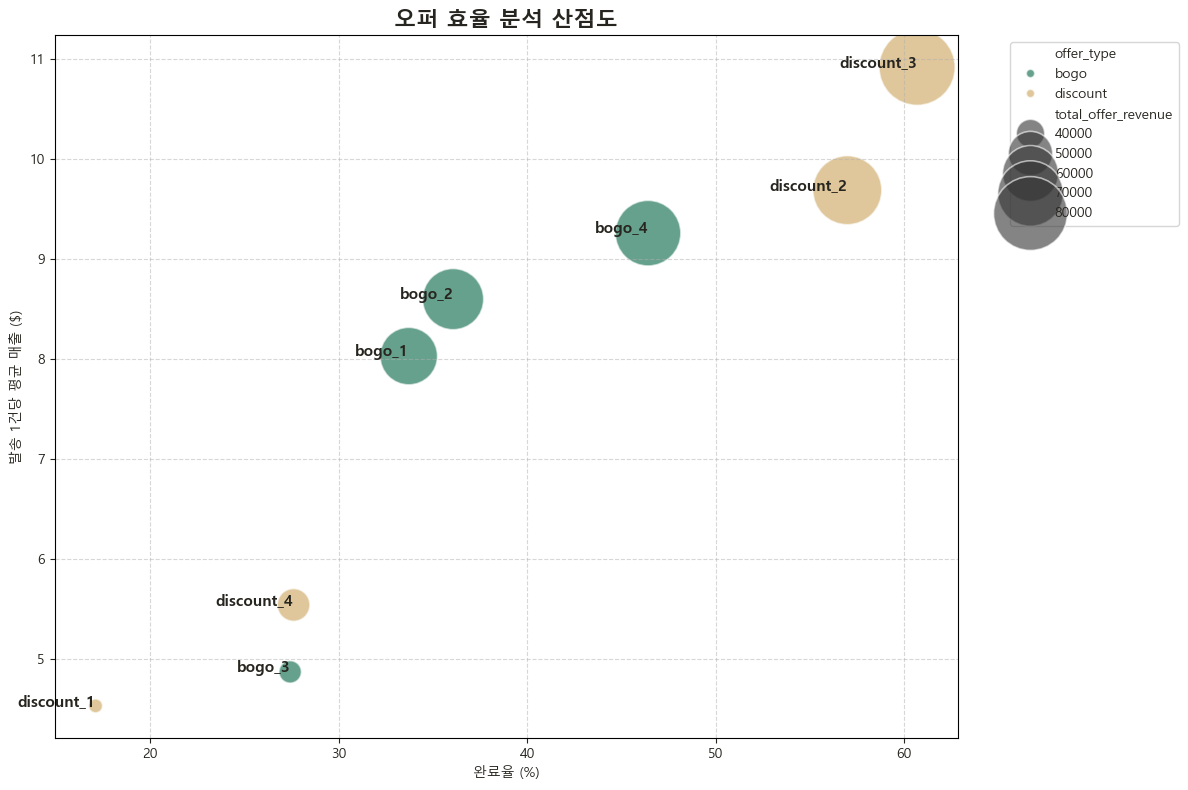

In [39]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=final_kpi_df,
    x='true_completed_rate', # 완료율
    y='revenue_per_send', # 발송 1건당 평균 매출
    size='total_offer_revenue', # 총 매출
    hue='offer_type',  # 색상 구분
    sizes=(100, 3000),
    alpha=0.6,
)

# 라벨 추가
for i in range(len(final_kpi_df)):
    plt.text(
        final_kpi_df['true_completed_rate'].iloc[i],
        final_kpi_df['revenue_per_send'].iloc[i],
        final_kpi_df['offer_label'].iloc[i],
        ha='right',
        fontsize=11,
        fontweight='bold',
        color=SB_BLACK
    )

plt.title('오퍼 효율 분석 산점도', fontsize=16, fontweight='bold')
plt.xlabel('완료율 (%)')
plt.ylabel('발송 1건당 평균 매출 ($)')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

1. discount_3과 discount_2의 높은 완료율과 원의 크기 (총 매출)

→ 고객들이 쉽게 참여하면서도 돈을 많이 쓰게 하는 최고의 오퍼

2. 중앙에 모여있는 bogo_1, bogo_2, bogo_4

→ 최고 1등은 아니지만 안정적인 성과를 보여줌

3. 하단에 있는 오퍼들 discount_1, discount_4, bogo_3

→ 완료율도 30% 이하이며 건당 매출도 5~6$로 낮음, 조건이 까다롭거나 보상이 별로?

4. 할인 쿠폰은 조건을 어떻게 짜느냐에 따라 큰 차이가 남

# 5. 오퍼 퍼널

퍼널은 3개로 분리

**1) received → viewed → completed 3단계를 모두 거치는 오퍼에 대한 퍼널 (전략적 전환)**  
    - 대상: bogo, discount  
    - 핵심 KPI  
        - 열람율 = viewed / received  
        - 전략적 전환율 = viewed가 선행된 후의 completed / received  

---

**2) received → completed 2단계만 거치는 오퍼에 대한 퍼널 (자발적/우연적 전환)**  
    - 대상: bogo, discount  
    - 여기서는 오퍼가 없어도 완료까지 수행하는 고객 군이므로 오퍼 낭비 대상이라고 생각  
          (굳이 오퍼 안해도 사먹으니까?)  
    - 핵심 KPI  
        - 낭비된 완료 수  
        - 낭비된 리워드 비율 = Viewed 없이 Completed 된 리워드 합계 / 전체 리워드 합계

---

**3) informational 만 따로 뺀 퍼널**  
    - 대상: informational (received → viewed)  
    - 핵심 KPI  
        - viewed 이후 24시간 내에 transaction 발생 수  
        - viewed 이후 24시간 내 구매 전환율  
        - viewed 이후 24시간 내 평균 구매 금액  
        - viewed O vs viewed X 고객 세그먼트 분석  
        - 보상에 따른 매출 증대율 계산(오퍼를 완료한 사람들의 평균 결제액 - 정보 제공 후 24시간 내 매출 / 정보 제공 후 24시간 내 매출 )*100 ← duration * 24 시간 이내 발생한 결제를 분모로 잡으면 더 정확한 계산

### 오퍼 인스턴스 테이블

목적:

같은 고객이 같은 offer_id를 여러 번 받을 수 있으므로 받은 1건 단위로 분석해야 함

각 received 이벤트를 하나의 오퍼 인스턴스로 보고, 그 이후 유효기간(duration) 안에 viewed/completed가 있었는지 확인

In [40]:
df['offer_type'] = df['offer_label'].str.split('_').str[0]
# customer_id, offer_id, time 기준으로 정렬
df = df.sort_values(['customer_id', 'offer_id', 'time']).reset_index(drop=True)

df.columns

Index(['person', 'event', 'time', 'offer_id', 'amount', 'bonus_reward',
       'time_days', 'gender', 'age', 'customer_id', 'became_member_on',
       'income', 'income_missing', 'age_missing', 'reward', 'difficulty',
       'duration', 'web', 'email', 'mobile', 'social', 'offer_label',
       'event_order', 'is_received', 'receive_seq', 'order_label',
       'offer_type'],
      dtype='str')

In [41]:
# 발송(received) 이벤트만 추출
offer_received = df[df['event'] == 'received'].copy()

# 같은 고객이 같은 오퍼를 몇 번째 받았는지 순번 부여(receive_seq 컬럼 생성)
offer_received = offer_received.sort_values(['customer_id', 'offer_id', 'time']).copy()
offer_received['receive_seq'] = offer_received.groupby(['customer_id', 'offer_id']).cumcount() + 1

# 다음 동일 오퍼 수신 시점 계산
# 같은 고객이 같은 offer_id를 또 받기 전까지만 현재 오퍼 인스턴스의 유효 범위로 본다
offer_received['next_received_time'] = offer_received.groupby(['customer_id', 'offer_id'])['time'].shift(-1)

# 원래 오퍼 만료 시점 = received_time + duration * 24시간
offer_received['offer_end_time'] = offer_received['time'] + offer_received['duration'] * 24

# 실제 분석 윈도우 종료 시점
# - 다음 오퍼를 다시 받기 전이 더 빠르면 거기까지
# - 아니면 원래 duration 종료 시점까지
offer_received['window_end_time'] = np.where(
    offer_received['next_received_time'].notna(),
    np.minimum(offer_received['offer_end_time'], offer_received['next_received_time']),
    offer_received['offer_end_time']
)

# 컬럼명 정리
offer_received = offer_received.rename(columns={'time': 'received_time'})

# 필요한 컬럼만 남김
offer_received = offer_received[
    [
        'customer_id', 'offer_id', 'offer_label', 'offer_type',
        'received_time', 'window_end_time', 'duration',
        'reward', 'difficulty',
        'web', 'email', 'mobile', 'social',
        'receive_seq'
    ]
].copy()

display(offer_received.head())

,customer_id,offer_id,offer_label,offer_type,received_time,window_end_time,duration,reward,difficulty,web,email,mobile,social,receive_seq
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,discount,576,744.0,7.0,2.0,10.0,1.0,1.0,1.0,0.0,1
2,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational_1,informational,336,432.0,4.0,0.0,0.0,1.0,1.0,1.0,0.0,1
4,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational_2,informational,168,240.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1
6,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo_4,bogo,408,528.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1
9,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount_3,discount,504,744.0,10.0,2.0,10.0,1.0,1.0,1.0,1.0,1


### 열람과 완료 이벤트를 위 오퍼 인스턴스에 붙이기

In [42]:
# 열람(viewed), 완료(completed) 이벤트 준비
offer_viewed = df[df['event'] == 'viewed'][['customer_id', 'offer_id', 'time']].copy()
offer_completed = df[df['event'] == 'completed'][['customer_id', 'offer_id', 'time', 'bonus_reward']].copy()

# 각 발송 건마다 열람 여부 붙이기
# 조건:
# - 같은 customer_id, 같은 offer_id
# - 열람 시점이 received_time 이후
# - 열람 시점이 window_end_time 이전
view_merge = offer_received.merge(
    offer_viewed,
    on=['customer_id', 'offer_id'],
    how='left',                        # 오퍼를 받았지만 안 본 경우도 분석해야 하므로 left join
    suffixes=('', '_view')
)

view_merge = view_merge[
    (view_merge['time'].isna()) |                                # 열람 기록이 아예 없거나(안 본 사람 계산)
    (
        (view_merge['time'] >= view_merge['received_time']) &    # 열람 시간이 오퍼를 받은 시점 이후이고,
        (view_merge['time'] <= view_merge['window_end_time'])    # 오퍼 유효기간 끝나는 시점 이전
    )
]

view_summary = (
    view_merge.groupby(['customer_id', 'offer_id', 'receive_seq'], as_index=False)
    .agg(
        viewed=('time', lambda x: x.notna().any()),    # 유효한 열람 기록이 하나라도 있으면 True, 하나도 없으면 False
        first_view_time=('time', 'min')                # 수신 건에 대해 가장 빠른 열람 시간을 저장
    )
)


# 각 발송 건마다 완료 여부 붙이기
# 조건:
# - 같은 customer_id, 같은 offer_id
# - 완료 시점이 received_time 이후
# - 완료 시점이 window_end_time 이전
complete_merge = offer_received.merge(
    offer_completed,
    on=['customer_id', 'offer_id'],
    how='left',                        # 오퍼를 받았지만 완료 안 한 경우도 분석해야 하므로 left join
    suffixes=('', '_complete')
)

complete_merge = complete_merge[
    (complete_merge['time'].isna()) |                                  # 완료 기록이 아예 없거나(완료 안 한 사람 계산)
    (
        (complete_merge['time'] >= complete_merge['received_time']) &  # 완료 시간이 오퍼를 받은 시점 이후이고,
        (complete_merge['time'] <= complete_merge['window_end_time'])  # 오퍼 유효기간 끝나는 시점 이전
    )
]

complete_summary = (
    complete_merge.groupby(['customer_id', 'offer_id', 'receive_seq'], as_index=False)
    .agg(
        completed=('time', lambda x: x.notna().any()),    # 유효한 완료 기록이 하나라도 있으면 True, 하나도 없으면 False
        first_complete_time=('time', 'min'),              # 수신 건에 대해 가장 빠른 완료 시간을 저장
        bonus_reward_sum=('bonus_reward', 'max')          # 수신 건에서 발생한 bonus_reward 최대값(오퍼 1번 완료 시 1번 보상이므로 합계 구할 필요 X)
    )
)


### 오퍼 인스턴스 테이블 완성

In [43]:
# 오퍼 인스턴스 테이블 완성
offer_instance = (
    offer_received
    .merge(view_summary, on=['customer_id', 'offer_id', 'receive_seq'], how='left')
    .merge(complete_summary, on=['customer_id', 'offer_id', 'receive_seq'], how='left')
)

# 결측 처리
offer_instance['viewed'] = offer_instance['viewed'].fillna(False)
offer_instance['completed'] = offer_instance['completed'].fillna(False)
offer_instance['bonus_reward_sum'] = offer_instance['bonus_reward_sum'].fillna(0)


# 전략적 완료 / 우연적 완료 분류
# 전략적 완료(effective_completed):
# - completed == True
# - viewed == True
# - first_view_time <= first_complete_time
#
# 우연적 완료(accidental_completed):
# - completed 이긴 한데, 전략적 완료는 아닌 경우
offer_instance['effective_completed'] = (
    offer_instance['completed'] &
    offer_instance['viewed'] &
    (offer_instance['first_view_time'] <= offer_instance['first_complete_time'])
)

offer_instance['accidental_completed'] = (
    offer_instance['completed'] &
    (~offer_instance['effective_completed'])
)

display(offer_instance.head())

,customer_id,offer_id,offer_label,offer_type,received_time,window_end_time,duration,reward,difficulty,web,email,mobile,social,receive_seq,viewed,first_view_time,completed,first_complete_time,bonus_reward_sum,effective_completed,accidental_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,discount,576,744.0,7.0,2.0,10.0,1.0,1.0,1.0,0.0,1,False,NaN,True,576.0,2.0,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational_1,informational,336,432.0,4.0,0.0,0.0,1.0,1.0,1.0,0.0,1,True,372.0,False,NaN,0.0,False,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational_2,informational,168,240.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1,True,192.0,False,NaN,0.0,False,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo_4,bogo,408,528.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1,True,456.0,True,414.0,5.0,False,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount_3,discount,504,744.0,10.0,2.0,10.0,1.0,1.0,1.0,1.0,1,True,540.0,True,528.0,2.0,False,True


## 1. 전략적 전환 퍼널

#### bogo / discount

In [44]:
# 전략적 전환 퍼널 대상 추출
# - bogo, discount만 포함
# - informational은 제외
conv_offer = offer_instance[offer_instance['offer_type'].isin(['bogo', 'discount'])].copy()

# 단계별 건수
received_cnt = len(conv_offer)
viewed_cnt = conv_offer['viewed'].sum()
completed_cnt = conv_offer['completed'].sum()
effective_completed_cnt = conv_offer['effective_completed'].sum()
accidental_completed_cnt = conv_offer['accidental_completed'].sum()

# 핵심 KPI
view_rate = viewed_cnt / received_cnt if received_cnt > 0 else 0
strategic_conversion_rate = effective_completed_cnt / received_cnt if received_cnt > 0 else 0
view_to_effective_rate = effective_completed_cnt / viewed_cnt if viewed_cnt > 0 else 0

print("=" * 60)
print("[전략적 전환 퍼널 KPI]")
print("=" * 60)
print(f"발송 수: {received_cnt:,}건")
print(f"열람 수: {viewed_cnt:,}건")
print(f"완료 수(전체): {completed_cnt:,}건")
print(f"전략적 완료 수: {effective_completed_cnt:,}건")
print(f"우연적 완료 수: {accidental_completed_cnt:,}건")
print(f"열람율 = 열람 / 발송: {view_rate:.2%}")
print(f"전략적 전환율 = 전략적 완료 / 발송: {strategic_conversion_rate:.2%}")
print(f"열람 후 전략적 완료율 = 전략적 완료 / 열람: {view_to_effective_rate:.2%}")

[전략적 전환 퍼널 KPI]
발송 수: 61,042건
열람 수: 46,685건
완료 수(전체): 33,163건
전략적 완료 수: 23,313건
우연적 완료 수: 9,850건
열람율 = 열람 / 발송: 76.48%
전략적 전환율 = 전략적 완료 / 발송: 38.19%
열람 후 전략적 완료율 = 전략적 완료 / 열람: 49.94%


#### 전략적 전환 퍼널 시각화

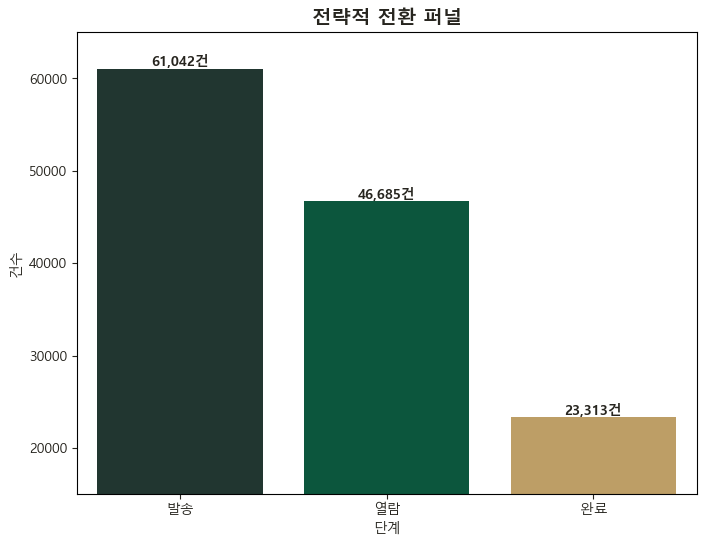

In [45]:
strategic_funnel_df = pd.DataFrame({
    '단계': ['발송', '열람', '완료'],
    '건수': [received_cnt, viewed_cnt, effective_completed_cnt]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=strategic_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_DEEP_GREEN, SB_GREEN, SB_GOLD]
)

for i, v in enumerate(strategic_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('전략적 전환 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(15000, 65000)
plt.show()

## 2. 우연적 전환 퍼널

우연적 완료 = viewed 없이 completed 된 경우
#### bogo / discount

In [46]:
# 우연적 전환 KPI
# 리워드 낭비 비율 = Viewed 없이 Completed 된 reward 합 / 전체 completed 건의 reward 합
wasted_completed_cnt = accidental_completed_cnt

total_reward_paid = conv_offer.loc[conv_offer['completed'], 'reward'].sum()
wasted_reward_amt = conv_offer.loc[conv_offer['accidental_completed'], 'reward'].sum()
wasted_reward_rate = wasted_reward_amt / total_reward_paid if total_reward_paid > 0 else 0
wasted_reward_pct = wasted_reward_amt / wasted_completed_cnt if total_reward_paid > 0 else 0

print("=" * 60)
print("[우연적 전환 KPI]")
print("=" * 60)
print(f"낭비된 완료 수: {wasted_completed_cnt:,}건")
print(f"낭비된 리워드 금액: ${wasted_reward_amt:,.2f}")
print(f"낭비된 리워드 비율: {wasted_reward_rate:.2%}")
print(f"낭비된 리워드 평균 금액: ${wasted_reward_pct:.2f}")

[우연적 전환 KPI]
낭비된 완료 수: 9,850건
낭비된 리워드 금액: $48,287.00
낭비된 리워드 비율: 29.67%
낭비된 리워드 평균 금액: $4.90


#### 우연적 전환 퍼널 시각화

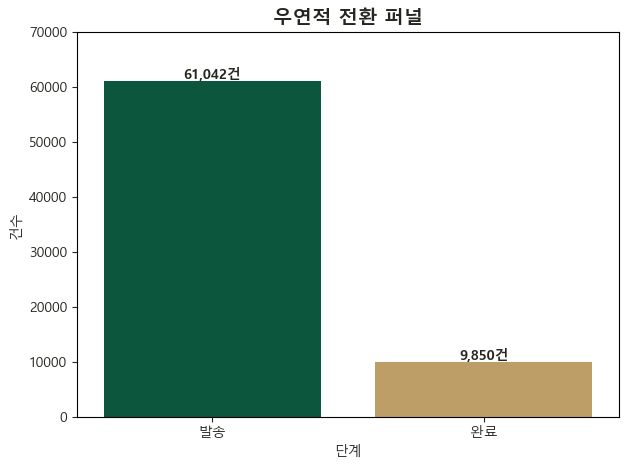

In [47]:
accidental_funnel_df = pd.DataFrame({
    '단계': ['발송', '완료'],
    '건수': [received_cnt, wasted_completed_cnt]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=accidental_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(accidental_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('우연적 전환 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(0, 70000)
plt.show()

## 3. informational 퍼널 및 24시간 내 구매 분석

#### informational 발송 → 열람 퍼널

In [48]:
# informational 오퍼만 추출
info_offer = offer_instance[offer_instance['offer_type'] == 'informational'].copy()

info_received_cnt = len(info_offer)
info_viewed_cnt = info_offer['viewed'].sum()
info_view_rate = info_viewed_cnt / info_received_cnt if info_received_cnt > 0 else 0

print("=" * 60)
print("[Informational 퍼널 KPI]")
print("=" * 60)
print(f"발송 수: {info_received_cnt:,}건")
print(f"열람 수: {info_viewed_cnt:,}건")
print(f"열람율 = 열람 / 발송: {info_view_rate:.2%}")

[Informational 퍼널 KPI]
발송 수: 15,235건
열람 수: 9,952건
열람율 = 열람 / 발송: 65.32%


 열람율 = 65.32% → 단순 정보성 오퍼이지만 열람 비율 높은 편

### informational 퍼널 시각화

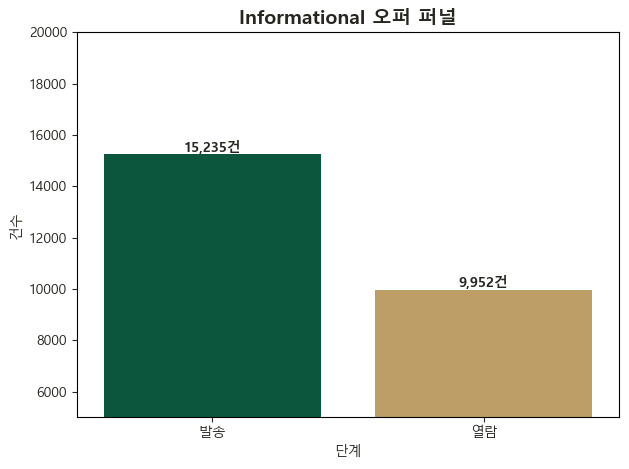

In [49]:
info_funnel_df = pd.DataFrame({
    '단계': ['발송', '열람'],
    '건수': [info_received_cnt, info_viewed_cnt]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=info_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(info_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('Informational 오퍼 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(5000, 20000)
plt.show()

#### 열람 후 24시간 내 구매 분석

In [50]:
# informational 열람 이벤트만 추출
info_view_events = df[
    (df['event'] == 'viewed') &
    (df['offer_type'] == 'informational')
][['customer_id', 'offer_id', 'time']].copy()

info_view_events = info_view_events.rename(columns={'time': 'view_time'})

# transaction 데이터는 customer_id, time, amount만 사용
transactions_small = transaction_df[['customer_id', 'time', 'amount']].copy()
transactions_small = transactions_small.rename(columns={'time': 'txn_time'})


# 열람 이벤트와 구매 이력 연결
# 같은 고객의 transaction을 모두 붙인 후, viewed 후 24시간 이내인지 여부를 체크
info_txn_merge = info_view_events.merge(
    transactions_small,
    on='customer_id',
    how='left'
)

info_txn_merge['txn_within_24h'] = (
    (info_txn_merge['txn_time'] >= info_txn_merge['view_time']) &
    (info_txn_merge['txn_time'] <= info_txn_merge['view_time'] + 24)
)


# viewed 1건 단위로 요약
# viewed 1건마다:
# - 24시간 내 구매가 있었는지
# - 24시간 내 구매금액 합계가 얼마인지
info_24h_summary = (
    info_txn_merge.groupby(['customer_id', 'offer_id', 'view_time'], as_index=False)
    .agg(
        purchased_24h=('txn_within_24h', 'any'),
        revenue_24h=('amount', lambda x: x[info_txn_merge.loc[x.index, 'txn_within_24h']].sum())
    )
)

display(info_24h_summary.head())

,customer_id,offer_id,view_time,purchased_24h,revenue_24h
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,False,0.0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,False,0.0
2,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,6,False,0.0
3,0011e0d4e6b944f998e987f904e8c1e5,5a8bc65990b245e5a138643cd4eb9837,354,False,0.0
4,0020c2b971eb4e9188eac86d93036a77,5a8bc65990b245e5a138643cd4eb9837,660,False,0.0


In [51]:
info_24h_summary[info_24h_summary['purchased_24h'] == True].describe()

,view_time,revenue_24h
count,4254.000000,4254.000000
mean,364.005642,16.780646
std,192.295857,30.895251
min,0.000000,0.050000
25%,192.000000,4.352500
50%,408.000000,12.490000
75%,520.500000,22.355000
max,714.000000,725.990000


In [52]:
# informational 24시간 KPI 계산
info_24h_purchase_cnt = info_24h_summary['purchased_24h'].sum()
info_24h_conversion_rate = info_24h_purchase_cnt / info_viewed_cnt
info_24h_total_revenue = info_24h_summary['revenue_24h'].sum()
info_24h_avg_revenue = info_24h_total_revenue / info_24h_purchase_cnt

print("=" * 60)
print("[Informational 24시간 내 구매 KPI]")
print("=" * 60)
print(f"열람 후 24시간 내 transaction 발생 수: {info_24h_purchase_cnt:,}건")
print(f"열람 후 24시간 내 구매 전환율: {info_24h_conversion_rate:.2%}")
print(f"열람 후 24시간 내 총 구매 금액: ${info_24h_total_revenue:,.2f}")
print(f"열람 후 24시간 내 평균 구매 금액: ${info_24h_avg_revenue:,.2f}")

[Informational 24시간 내 구매 KPI]
열람 후 24시간 내 transaction 발생 수: 4,254건
열람 후 24시간 내 구매 전환율: 42.75%
열람 후 24시간 내 총 구매 금액: $71,384.87
열람 후 24시간 내 평균 구매 금액: $16.78


열람 후 24시간 내 구매 전환율 = 42.75%  
→ 단순 정보 제공이지만 구매 전환율이 꽤 나와서 의미 없는 오퍼는 아니다?  
→ 그렇지만 인과관계는 아님

#### informational 본 사람 vs 안 본 사람

본 사람: informational viewed 경험이 1번 이상 있는 고객  
안 본 사람: informational viewed 경험이 없는 고객

In [53]:
# 고객별 총 구매금액 테이블 만들기
customer_stats = (
    transactions.groupby('customer_id')['amount']
    .agg(['sum', 'count', 'mean'])
    .reset_index()
    .rename(columns={
        'sum': 'total_spend',
        'count': 'purchase_cnt',
        'mean': 'aov_customer'
    })
)

# 전체 고객을 기준으로 0원 구매 고객도 포함하기 위해
# customer_master를 만들어 left join 한 뒤 결측을 0으로 채워준다
customer_master = pd.DataFrame({'customer_id': df['customer_id'].unique()})

customer_stats = customer_master.merge(customer_stats, on='customer_id', how='left')
customer_stats[['total_spend', 'purchase_cnt', 'aov_customer']] = customer_stats[
    ['total_spend', 'purchase_cnt', 'aov_customer']
].fillna(0)


# informational 열람 경험 고객 표시
info_view_customer = df[
    (df['event'] == 'viewed') &
    (df['offer_type'] == 'informational')
]['customer_id'].unique()

customer_stats['info_viewed_flag'] = customer_stats['customer_id'].isin(info_view_customer)

# 그룹별 평균 비교
info_view_compare = (
    customer_stats.groupby('info_viewed_flag', as_index=False)
    .agg(
        고객수=('customer_id', 'nunique'),
        평균총구매금액=('total_spend', 'mean'),
        평균구매횟수=('purchase_cnt', 'mean'),
        평균객단가=('aov_customer', 'mean')
    )
)

info_view_compare['info_viewed_flag'] = info_view_compare['info_viewed_flag'].map({
    True: 'informational 본 사람',
    False: 'informational 안 본 사람'
})

display(info_view_compare)

,info_viewed_flag,고객수,평균총구매금액,평균구매횟수,평균객단가
0,informational 안 본 사람,8749,103.655199,8.237627,13.142103
1,informational 본 사람,8251,105.268771,8.105927,13.551229


informational 본 사람이 구매횟수는 좀 낮지만 구매 금액 & 객단가 약간 높음

#### informational 본 사람 vs 안 본 사람 시각화

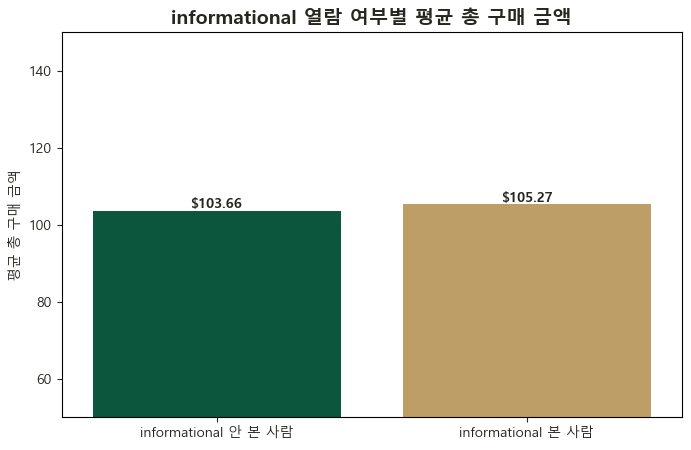

In [54]:
# informational 본 사람 vs 안 본 사람 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=info_view_compare,
    x='info_viewed_flag',
    y='평균총구매금액',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(info_view_compare['평균총구매금액']):
    ax.text(i, v, f"${v:,.2f}", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('informational 열람 여부별 평균 총 구매 금액', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('평균 총 구매 금액')
plt.ylim(50, 150)
plt.show()

### (bogo & discount) vs informational 매출 비교

In [55]:
# 모든 기준을 '건당 1회 평균 결제액(AOV)'으로 통일
# BOGO, Discount 완료(사용) 거래 및 일반 거래 건당 평균 결제액
completed_tx = transaction_df[
    transaction_df['tx_offer_type'].isin(['bogo', 'discount', 'multi'])
].copy()

normal_tx = transaction_df[
    transaction_df['tx_offer_type'] == 'normal'
].copy()

completed_tx_aov = completed_tx['amount'].mean()
normal_tx_aov = normal_tx['amount'].mean()


# Informational 열람 후 24시간 내 발생한 거래들의 건당 평균 결제액(AOV) 구하기
# info_txn_merge 데이터프레임에서 실제 24시간 내 발생한 거래만 필터링
valid_info_txns = info_txn_merge[info_txn_merge['txn_within_24h'] == True].copy()

# 하나의 영수증(결제)이 여러 번의 열람 이벤트에 중복 카운트되는 것을 방지
unique_info_txns = valid_info_txns.drop_duplicates(subset=['customer_id', 'txn_time'])

# 인포메이션 오퍼의 영향을 받은 1회 결제당 평균 금액
info_24h_tx_aov = unique_info_txns['amount'].mean()


# 새로운 매출 증대율 계산
new_revenue_lift_rate = (
    (completed_tx_aov - info_24h_tx_aov) / info_24h_tx_aov * 100
    if info_24h_tx_aov > 0 else np.nan
)

print("=" * 60)
print("오퍼 유형별 건당 객단가(AOV) 및 매출 증대율")
print("=" * 60)
print(f"일반 거래(normal) 평균 객단가: ${normal_tx_aov:,.2f}")
print(f"informational 열람 후 24시간 내 거래 평균 객단가: ${info_24h_tx_aov:,.2f}")
print(f"bogo/discount 완료(사용) 거래 평균 객단가: ${completed_tx_aov:,.2f}")
print("-" * 60)
print(f"정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율: {new_revenue_lift_rate:,.2f}%")

오퍼 유형별 건당 객단가(AOV) 및 매출 증대율
일반 거래(normal) 평균 객단가: $10.70
informational 열람 후 24시간 내 거래 평균 객단가: $12.95
bogo/discount 완료(사용) 거래 평균 객단가: $20.14
------------------------------------------------------------
정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율: 55.48%


### informational KPI

In [56]:
# informational KPI 표 정리
info_kpi_df = pd.DataFrame({
    '지표': [
        '발송 수',
        '열람 수',
        '열람율',
        '열람 후 24시간 내 구매가 있었던 열람 수',
        '열람 후 24시간 내 구매 전환율',
        '열람 후 24시간 내 평균 구매 금액',
        'bogo/discount 완료(사용) 거래 평균 객단가',
        '정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율'
    ],
    '값': [
        info_received_cnt,
        info_viewed_cnt,
        round(info_view_rate * 100, 2),
        int(info_24h_purchase_cnt),
        round(info_24h_conversion_rate * 100, 2),
        round(info_24h_tx_aov, 2),
        round(completed_tx_aov, 2),
        round(new_revenue_lift_rate, 2) if pd.notna(new_revenue_lift_rate) else np.nan
    ]
})

display(info_kpi_df)

,지표,값
0,발송 수,15235.00
1,열람 수,9952.00
2,열람율,65.32
3,열람 후 24시간 내 구매가 있었던 열람 수,4254.00
4,열람 후 24시간 내 구매 전환율,42.75
5,열람 후 24시간 내 평균 구매 금액,12.95
6,bogo/discount 완료(사용) 거래 평균 객단가,20.14
7,정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율,55.48


## 오퍼 퍼널 분석 요약

In [57]:
# 요약 표
summary_df = pd.DataFrame({
    '구분': [
        '전략적 전환 퍼널',
        '전략적 전환 퍼널',
        '전략적 전환 퍼널',
        '우연적 전환 퍼널',
        '우연적 전환 퍼널',
        '우연적 전환 퍼널',
        'Informational',
        'Informational',
        'Informational'
    ],
    '지표': [
        '발송 수',
        '열람율',
        '전략적 전환율',
        '낭비된 완료 수',
        '낭비된 리워드 금액',
        '낭비된 리워드 비율',
        '발송 수',
        '열람율',
        '24시간 내 구매 전환율'
    ],
    '값': [
        received_cnt,
        round(view_rate * 100, 2),
        round(strategic_conversion_rate * 100, 2),
        wasted_completed_cnt,
        round(wasted_reward_amt, 2),
        round(wasted_reward_rate * 100, 2),
        info_received_cnt,
        round(info_view_rate * 100, 2),
        round(info_24h_conversion_rate * 100, 2)
    ]
})

display(summary_df)

,구분,지표,값
0,전략적 전환 퍼널,발송 수,61042.00
1,전략적 전환 퍼널,열람율,76.48
2,전략적 전환 퍼널,전략적 전환율,38.19
3,우연적 전환 퍼널,낭비된 완료 수,9850.00
4,우연적 전환 퍼널,낭비된 리워드 금액,48287.00
5,우연적 전환 퍼널,낭비된 리워드 비율,29.67
6,Informational,발송 수,15235.00
7,Informational,열람율,65.32
8,Informational,24시간 내 구매 전환율,42.75


# 6. 고객 세그먼트 분석

In [58]:
df['time_days']  = pd.to_numeric(df['time_days'], errors='coerce')

print(f"df 컬럼             : {df.columns.tolist()}")
print(f"transaction_df 컬럼 : {transaction_df.columns.tolist()}")

df 컬럼             : ['person', 'event', 'time', 'offer_id', 'amount', 'bonus_reward', 'time_days', 'gender', 'age', 'customer_id', 'became_member_on', 'income', 'income_missing', 'age_missing', 'reward', 'difficulty', 'duration', 'web', 'email', 'mobile', 'social', 'offer_label', 'event_order', 'is_received', 'receive_seq', 'order_label', 'offer_type']
transaction_df 컬럼 : ['tx_key', 'person', 'customer_id', 'time', 'amount', 'tx_occurrence', 'time_days', 'gender', 'age', 'became_member_on', 'income', 'income_missing', 'age_missing', 'linked_reward_offer_cnt', 'reward_offer_family_list', 'reward_offer_label_list', 'reward_offer_id_list', 'bonus_reward_sum', 'tx_offer_type', 'final_label']


In [59]:
# 고객 기본 정보 추출
customers = df[['customer_id', 'age', 'gender', 'income', 'became_member_on']].drop_duplicates()
customers['became_member_on']  = pd.to_datetime(customers['became_member_on'])
customers['membership_years']  = (
    (pd.to_datetime('2018-07-31') - customers['became_member_on']).dt.days // 365
)

# 연령대 그룹화
customers['age_group'] = pd.cut(
    customers.loc[customers['age'] != 118, 'age'],
    bins=AGE_BINS, labels=AGE_LABELS, right=True
)

# 소득 구간 그룹화
customers['income_group'] = pd.cut(
    customers['income'], bins=INCOME_BINS, labels=INCOME_LABELS, right=False
)
customers['income_group'] = customers['income_group'].cat.add_categories('Unknown').fillna('Unknown')

# 성별 매핑
customers['gender_mapped'] = (
    customers['gender'].fillna('Unknown')
    .map({'M': '남성', 'F': '여성', 'O': 'Other', 'Unknown': 'Unknown'})
)

# 가입 연차 그룹화
customers['tenure_group'] = customers['membership_years'].map(
    {0: '1년 미만', 1: '1~2년', 2: '2~3년', 3: '3~4년', 4: '4~5년', 5: '5년 이상'}
)

# VIP 정의: 구매 이력 있는 고객 상위 20%
monetary = (
    df[df['event'] == 'transaction']
    .groupby('customer_id')['amount'].sum()
    .reset_index()
    .rename(columns={'amount': 'total_amount'})
)
customers = pd.merge(customers, monetary, on='customer_id', how='left')
customers['total_amount'] = customers['total_amount'].fillna(0)

threshold = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.80)
customers['is_vip']       = customers['total_amount'] >= threshold
customers['customer_type'] = np.where(customers['is_vip'], 'VIP 고객', '일반 고객')

actual_vip_pct = customers['is_vip'].mean() * 100
print(f"VIP 기준 결제액  : ${threshold:.2f}")
print(f"실제 VIP 비중    : {actual_vip_pct:.1f}%  (비구매 포함 전체 대비)")

# 구매력 등급
q75 = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.75)
q25 = customers[customers['total_amount'] > 0]['total_amount'].quantile(0.25)

def assign_spending_tier(spent):
    if spent == 0:       return '비구매'
    elif spent >= q75:   return '고매출'
    elif spent <= q25:   return '저매출'
    else:                return '일반매출'

customers['spending_tier'] = customers['total_amount'].apply(assign_spending_tier)

# 오퍼 선호도(마케팅)
v_or_c_offer_events    = df[df['event'].isin(['viewed', 'completed'])].copy()
preferred_offer = (
    v_or_c_offer_events.groupby(['customer_id', 'offer_type']).size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'count'], ascending=[True, False])
    .drop_duplicates(subset=['customer_id'], keep='first')
    .rename(columns={'offer_type': 'preferred_offer'})[['customer_id', 'preferred_offer']]
)
customers = pd.merge(customers, preferred_offer, on='customer_id', how='left')
customers['preferred_offer'] = customers['preferred_offer'].fillna('반응없음')

# 정보성 오퍼 열람 여부
info_viewers = df[(df['offer_type'] == 'informational') & (df['event'] == 'viewed')]['customer_id'].unique()
customers['info_viewer'] = customers['customer_id'].isin(info_viewers)

# 최근 방문일
last_visit = (
    df[df['event'] == 'transaction']
    .groupby('customer_id')['time_days'].max()
    .reset_index()
    .rename(columns={'time_days': 'last_visit_day'})
)
customers = pd.merge(customers, last_visit, on='customer_id', how='left')
customers['days_since_last_visit'] = df['time_days'].max() - customers['last_visit_day']

# 데이터 추출
customers.to_csv('../../Data/master_customers_final.csv', index=False, encoding='utf-8-sig')
print("\nmaster_customers_final.csv 저장 완료")
print(f"customers 행 수 : {len(customers):,}")
print(customers[['customer_id','age_group','income_group','tenure_group','is_vip','spending_tier']].head())

VIP 기준 결제액  : $170.65
실제 VIP 비중    : 19.5%  (비구매 포함 전체 대비)

master_customers_final.csv 저장 완료
customers 행 수 : 17,000
                        customer_id age_group income_group tenure_group  \
0  0009655768c64bdeb2e877511632db8f       30대      70K-90K         1~2년   
1  00116118485d4dfda04fdbaba9a87b5c       NaN      Unknown        1년 미만   
2  0011e0d4e6b944f998e987f904e8c1e5       40대      50K-70K        1년 미만   
3  0020c2b971eb4e9188eac86d93036a77       50대     90K-110K         2~3년   
4  0020ccbbb6d84e358d3414a3ff76cffd       20대      50K-70K         1~2년   

   is_vip spending_tier  
0   False          일반매출  
1   False           저매출  
2   False          일반매출  
3    True           고매출  
4   False           고매출  


## 기초 통계 및 분석

### ARPU 및 채널별 도달률

In [60]:
total_customers = len(customers)
customers_total_revenue   = customers['total_amount'].sum()
arpu            = customers_total_revenue / total_customers

vip_cust     = customers[customers['is_vip']]
general_cust = customers[~customers['is_vip']]

print("=" * 60)
print(f"총 고유 고객 수  : {total_customers:,}명")
print(f"총 발생 매출     : ${customers_total_revenue:,.2f}")
print(f"전체 평균 ARPU   : ${arpu:.2f}")
print("-" * 60)
print("[세그먼트별 ARPU 비교]")
print(f"VIP 고객 ARPU    : ${(vip_cust['total_amount'].sum() / len(vip_cust)):.2f} (고객 수: {len(vip_cust):,}명)")
print(f"일반 고객 ARPU   : ${(general_cust['total_amount'].sum() / len(general_cust)):.2f} (고객 수: {len(general_cust):,}명)")
print("=" * 60)

print("\n채널별 순수 도달 고객 수 (event: 'received')")
for ch in channels:
    unique_users = df[(df[ch] == 1) & (df['event'] == 'received')]['customer_id'].nunique()
    print(f"  {ch.upper():8s}: {unique_users:,}명")

총 고유 고객 수  : 17,000명
총 발생 매출     : $1,775,451.97
전체 평균 ARPU   : $104.44
------------------------------------------------------------
[세그먼트별 ARPU 비교]
VIP 고객 ARPU    : $285.82 (고객 수: 3,316명)
일반 고객 ARPU   : $60.49 (고객 수: 13,684명)

채널별 순수 도달 고객 수 (event: 'received')
  WEB     : 16,916명
  EMAIL   : 16,994명
  MOBILE  : 16,980명
  SOCIAL  : 16,529명


### 오퍼 유형별 퍼널 전환율

In [61]:
offer_types = ['bogo', 'discount', 'informational']

print("=" * 60)
print("[오퍼 유형별 퍼널 전환율 — 고객 수(unique) 기준]")
for offer_type in offer_types:
    offer_df = df[df['offer_type'] == offer_type]

    received  = offer_df[offer_df['event'] == 'received' ]['customer_id'].nunique()
    viewed    = offer_df[offer_df['event'] == 'viewed'   ]['customer_id'].nunique()
    completed = offer_df[offer_df['event'] == 'completed']['customer_id'].nunique()

    view_rate_pct     = (viewed    / received * 100) if received > 0 else 0
    complete_rate = (completed / viewed   * 100) if viewed   > 0 else 0

    print(f"\n[{offer_type.upper()}]")
    print(f"  발송 {received:,}명 → 열람 {viewed:,}명 → 완료 {completed:,}명")
    print(f"  발송→열람 전환율 : {view_rate_pct:.2f}%")
    if offer_type != 'informational':
        print(f"  열람→완료 전환율 : {complete_rate:.2f}%")

# 퍼널 소요 시간 분석
views     = df[df['event'] == 'viewed'   ][['customer_id','offer_id','time_days','offer_type']].rename(columns={'time_days':'view_day'})
completes = completions[['customer_id','offer_id','time_days']              ].rename(columns={'time_days':'complete_day'})

funnel_time = pd.merge(views, completes, on=['customer_id','offer_id'], how='inner')
funnel_time = funnel_time[funnel_time['complete_day'] >= funnel_time['view_day']]
funnel_time['days_to_complete'] = funnel_time['complete_day'] - funnel_time['view_day']

funnel_time = (
    funnel_time
    .sort_values(['customer_id','offer_id','view_day','days_to_complete'])
    .drop_duplicates(subset=['customer_id','offer_id','view_day'],     keep='first')
    .drop_duplicates(subset=['customer_id','offer_id','complete_day'], keep='first')
)

print("\n" + "=" * 60)
print(f"전체 평균 열람→구매 소요 시간 : {funnel_time['days_to_complete'].mean():.2f}일")


[오퍼 유형별 퍼널 전환율 — 고객 수(unique) 기준]



[BOGO]
  발송 14,992명 → 열람 14,008명 → 완료 9,263명
  발송→열람 전환율 : 93.44%
  열람→완료 전환율 : 66.13%

[DISCOUNT]
  발송 14,945명 → 열람 12,676명 → 완료 10,289명
  발송→열람 전환율 : 84.82%
  열람→완료 전환율 : 81.17%

[INFORMATIONAL]
  발송 10,547명 → 열람 8,251명 → 완료 0명
  발송→열람 전환율 : 78.23%

전체 평균 열람→구매 소요 시간 : 2.26일


## 시각화

#### 기본 인구통계 종합 분포

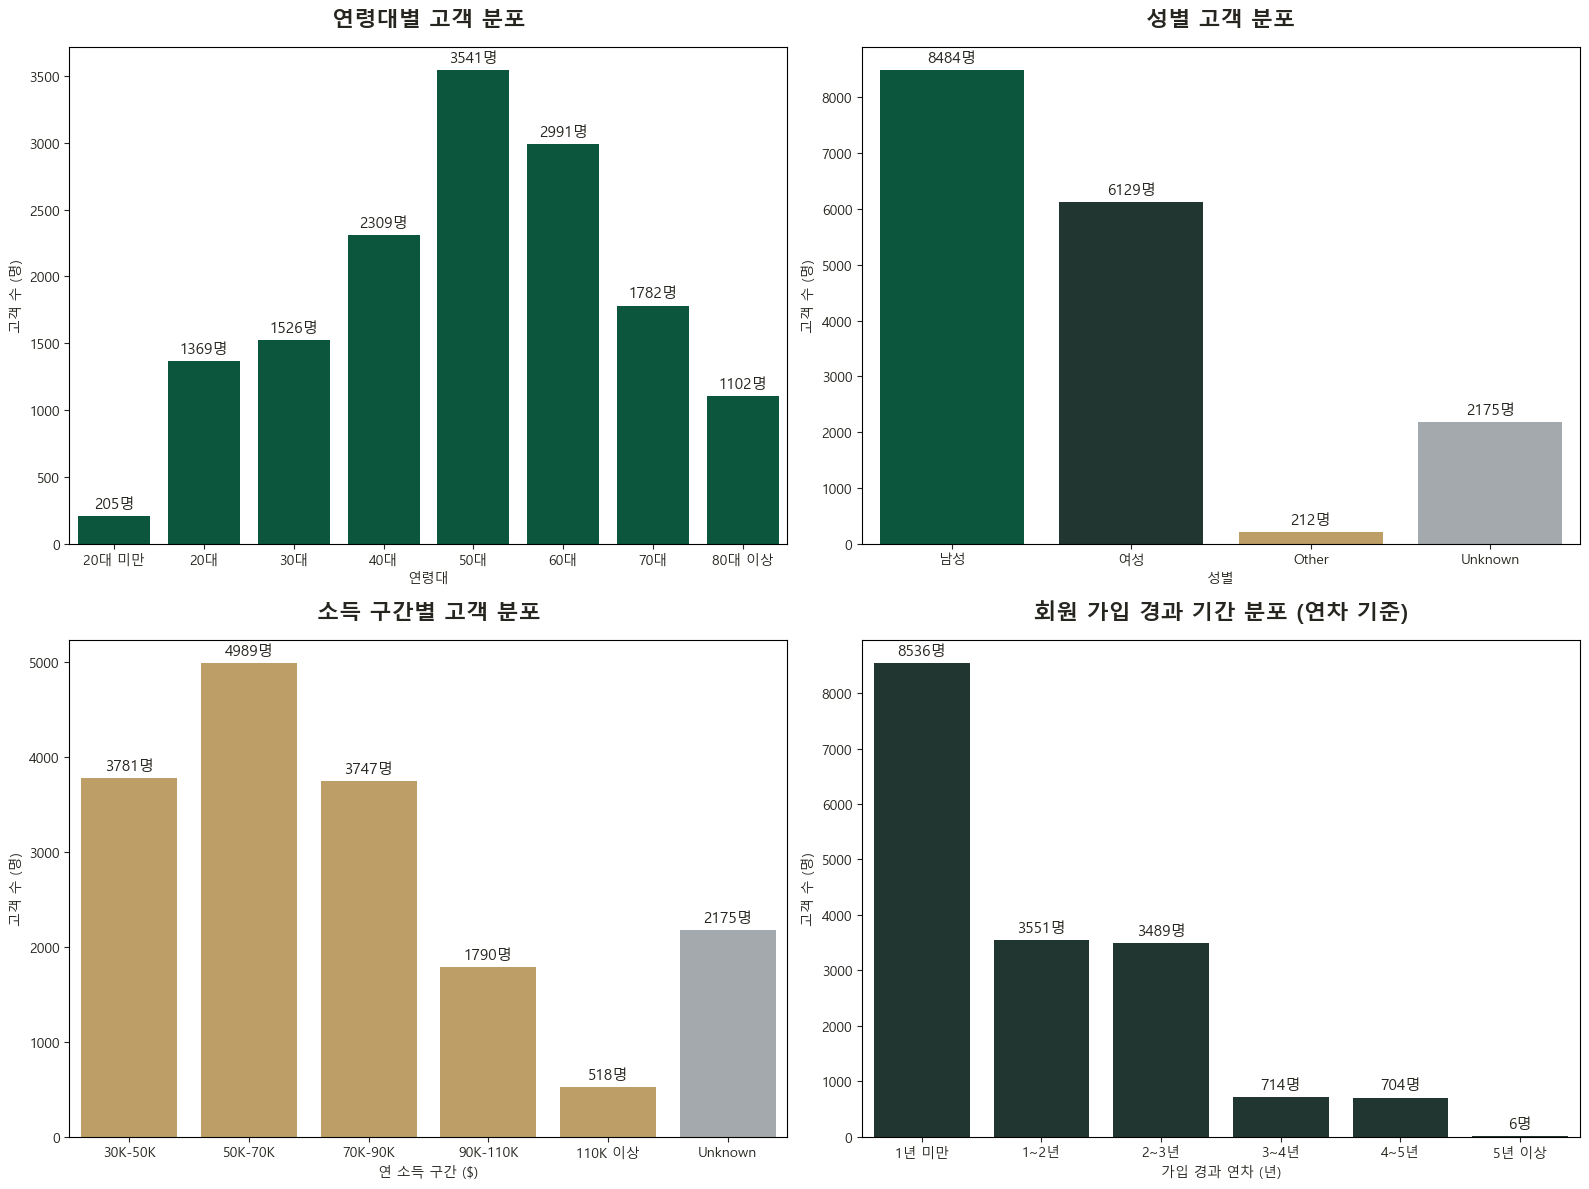

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 연령대별 고객 분포
ax1 = sns.countplot(data=customers, x='age_group', color=SB_GREEN,
                    ax=axes[0, 0], order=AGE_LABELS)
axes[0, 0].set_title('연령대별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('연령대')
axes[0, 0].set_ylabel('고객 수 (명)')
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 성별 고객 분포
ax2 = sns.countplot(data=customers, x='gender_mapped',
                    palette=[SB_GREEN, SB_DEEP_GREEN, SB_GOLD, SB_GREY],
                    ax=axes[0, 1], order=GENDER_ORDER)
axes[0, 1].set_title('성별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('성별')
axes[0, 1].set_ylabel('고객 수 (명)')
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 소득 구간별 고객 분포
ax3 = sns.countplot(data=customers, x='income_group',
                    palette=[SB_GOLD] * 5 + [SB_GREY],
                    ax=axes[1, 0], order=INCOME_ORDER)
axes[1, 0].set_title('소득 구간별 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('연 소득 구간 ($)')
axes[1, 0].set_ylabel('고객 수 (명)')
for c in ax3.containers:
    ax3.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 회원 가입 경과 기간 분포
ax4 = sns.countplot(data=customers, x='tenure_group', color=SB_DEEP_GREEN,
                    ax=axes[1, 1], order=TENURE_ORDER)
axes[1, 1].set_title('회원 가입 경과 기간 분포 (연차 기준)', fontsize=16, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('가입 경과 연차 (년)')
axes[1, 1].set_ylabel('고객 수 (명)')
for c in ax4.containers:
    ax4.bar_label(c, fmt='%d명', padding=3, fontsize=11)

plt.tight_layout()
plt.show()


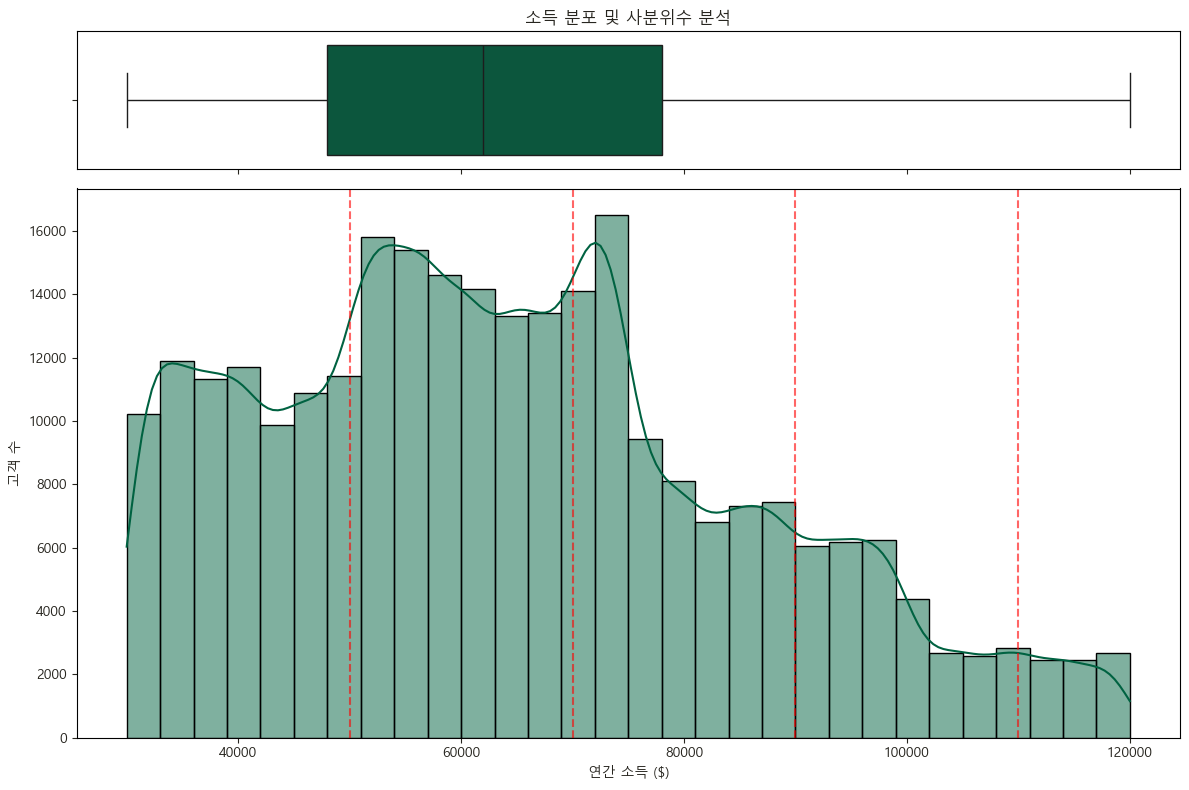

In [63]:
fig, (ax_box, ax_hist) = plt.subplots(
    2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(12, 8)
)

sns.boxplot(x=df['income'].dropna(), ax=ax_box, color=SB_GREEN)
ax_box.set(title='소득 분포 및 사분위수 분석', xlabel='')

sns.histplot(df['income'].dropna(), kde=True, ax=ax_hist, color=SB_GREEN, bins=30)
ax_hist.set(xlabel='연간 소득 ($)', ylabel='고객 수')

for x in [50000, 70000, 90000, 110000]:
    ax_hist.axvline(x=x, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 전체 매출 대비 VIP 기여도 및 성별 그룹 내 VIP 비중

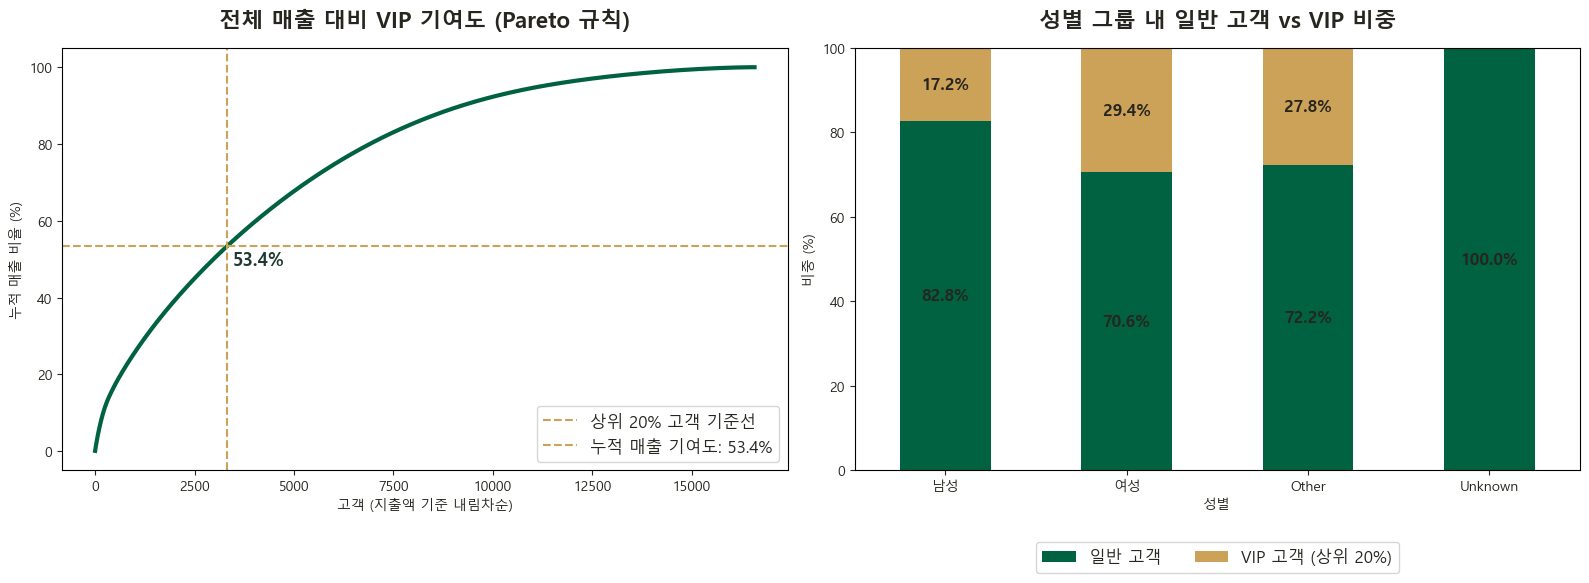

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pareto 곡선
sorted_cust = (
    customers[customers['total_amount'] > 0]
    .sort_values('total_amount', ascending=False)
    .reset_index(drop=True)
)
sorted_cust['cum_amount']  = sorted_cust['total_amount'].cumsum()
sorted_cust['cum_percent'] = sorted_cust['cum_amount'] / sorted_cust['total_amount'].sum() * 100

top20_idx     = int(len(sorted_cust) * 0.2)
top20_revenue = sorted_cust.loc[top20_idx, 'cum_percent']

axes[0].plot(sorted_cust.index, sorted_cust['cum_percent'], color=SB_GREEN, lw=3)
axes[0].axvline(top20_idx,     color=SB_GOLD, linestyle='--', label='상위 20% 고객 기준선')
axes[0].axhline(top20_revenue, color=SB_GOLD, linestyle='--',
                label=f'누적 매출 기여도: {top20_revenue:.1f}%')
axes[0].set_title('전체 매출 대비 VIP 기여도 (Pareto 규칙)',
                  fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('고객 (지출액 기준 내림차순)')
axes[0].set_ylabel('누적 매출 비율 (%)')
axes[0].text(top20_idx + 150, top20_revenue - 5, f'{top20_revenue:.1f}%',
             color=SB_DEEP_GREEN, fontweight='bold', fontsize=13)
axes[0].legend(fontsize=12)

# 성별 내 VIP 비중
gender_vip = (
    customers.groupby('gender_mapped')['is_vip']
    .value_counts(normalize=True)
    .unstack()
    .reindex(GENDER_ORDER) * 100
)
ax = gender_vip.plot(kind='bar', stacked=True, color=[SB_GREEN, SB_GOLD], ax=axes[1])
axes[1].set_title('성별 그룹 내 일반 고객 vs VIP 비중',
                  fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('성별')
axes[1].set_ylabel('비중 (%)')
axes[1].legend(['일반 고객', 'VIP 고객 (상위 20%)'],
               loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

지출액 기준 상위 20%의 고객이 전체 매출의 53.4%를 발생시키고 있음

고객수는 남성이 더 많지만 VIP 고객 비율은 여성이 높다

이는 고액 지출로 이어지는 충성 고객층은 주로 여성 중심으로 형성되어 있음

**→ 여성 VIP 고객의 이탈을 막기 위해, 이들의 선호도와 구매 패턴에 맞춘 프라이빗 혜택이나 전용 맴버십 프로그램을 강화하는 것이 효율적**

**→ 남성 고객의 VIP 전환 전략 검토 : 전환율이 낮은 이유를 파악해야 한다. 상품군이 부족한 것인지, 마케팅 메시지가 맞지 않는 것인지 분석해야 객단가를 높히는 전략을 마련할 수 있음**

**→ 전체 매출의 46.6%를 차지하는 일반 고객층 중, 상위 20% 커트라인에 근접한 고객들을 타겟화하여 추가 구매를 유도하면 전체 매출 볼륨을 크게 키울 수 있음**

---

### 성별 × VIP 여부 카이제곱 검정

#### 검정 방법 선택 근거
- **변수 유형**: 성별(범주형) × VIP 여부(범주형) → **카이제곱 독립성 검정**
- **귀무가설**: 성별과 VIP 여부는 서로 독립이다 (성별에 따라 VIP 비율이 다르지 않다)
- **효과 크기**: Cramér's V (0.1=소, 0.3=중, 0.5=대)

[분할표 — 관측 빈도]


,일반 고객,VIP 고객
성별,,
남성,7027,1457
여성,4329,1800



[기대 빈도 확인 — 모든 셀 ≥ 5 이면 카이제곱 가정 충족]
     일반 고객  VIP 고객
성별                
남성  6593.1  1890.9
여성  4762.9  1366.1
→ 최소 기대 빈도: 1366.1  ✅ 가정 충족

[성별 × VIP 여부 — 카이제곱 독립성 검정]
  χ²(1) = 304.8273,  p = 2.9247e-68
  ★ 귀무가설 기각 (p<0.05)
  효과 크기 Cramér's V = 0.1444  → 소(small)
  표본 크기 n = 14,613

  남성 VIP 비율: 17.2%
  여성 VIP 비율: 29.4%
  → 성별과 VIP 여부는 통계적으로 유의미하게 연관되어 있음
  → 효과 크기 소(small) 수준


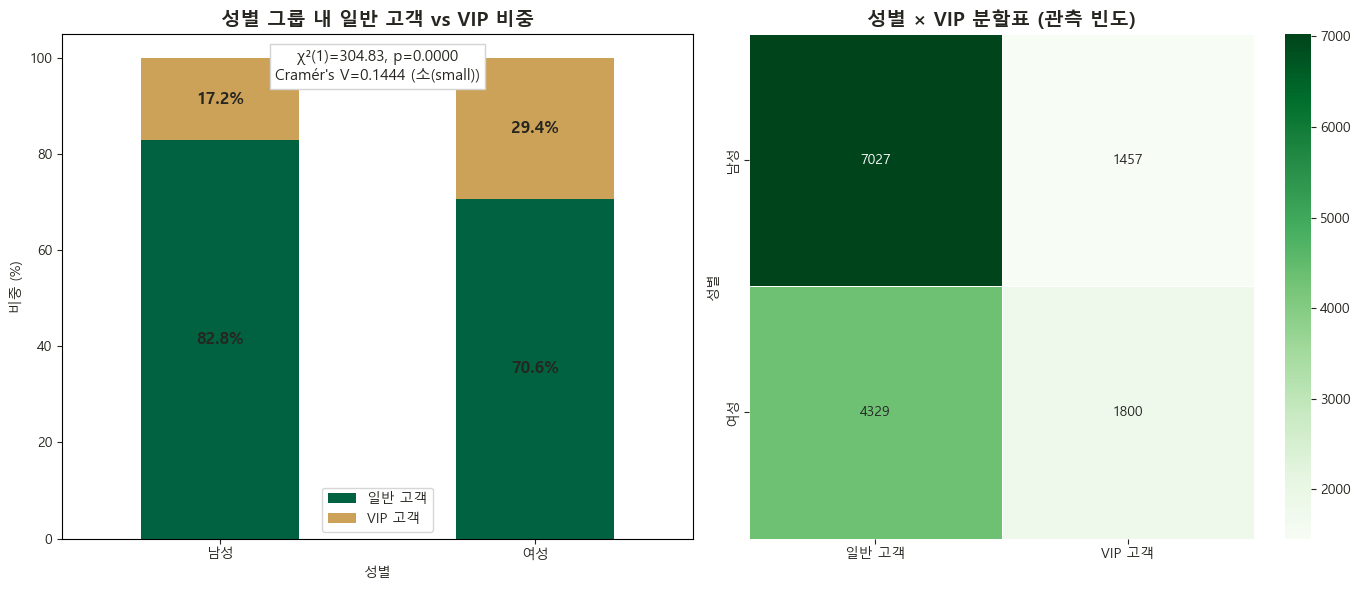

In [65]:
from scipy.stats import chi2_contingency
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# 효과 크기 해석 함수
def interpret_cramers_v(v):
    if v < 0.1:   return '효과 없음'
    elif v < 0.3: return '소(small)'
    elif v < 0.5: return '중(medium)'
    else:         return '대(large)'

# 분할표 구성 (남성/여성만 — Other·Unknown은 표본 적어 제외)
gender_target = ['남성', '여성']
ct_gender = pd.crosstab(
    customers[customers['gender_mapped'].isin(gender_target)]['gender_mapped'],
    customers[customers['gender_mapped'].isin(gender_target)]['is_vip']
)
ct_gender.columns = ['일반 고객', 'VIP 고객']
ct_gender.index.name = '성별'

print("[분할표 — 관측 빈도]")
display(ct_gender)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(ct_gender)

# 기대 빈도 확인 (모든 셀 >= 5 이어야 카이제곱 가정 충족)
print("\n[기대 빈도 확인 — 모든 셀 ≥ 5 이면 카이제곱 가정 충족]")
print(pd.DataFrame(expected.round(1), index=ct_gender.index, columns=ct_gender.columns))
min_expected = expected.min()
print(f"→ 최소 기대 빈도: {min_expected:.1f}  {'✅ 가정 충족' if min_expected >= 5 else '❌ Fisher exact 권장'}")

# 효과 크기 (Cramér's V)
n = ct_gender.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_gender.shape) - 1)))

# 결과 출력
print("\n" + "=" * 60)
print("[성별 × VIP 여부 — 카이제곱 독립성 검정]")
print(f"  χ²({dof}) = {chi2:.4f},  p = {p:.4e}")
print(f"  {'★ 귀무가설 기각 (p<0.05)' if p < 0.05 else '귀무가설 채택'}")
print(f"  효과 크기 Cramér's V = {cramers_v:.4f}  → {interpret_cramers_v(cramers_v)}")
print(f"  표본 크기 n = {n:,}")
print()
if p < 0.05:
    # 어느 쪽이 더 VIP 비율이 높은지
    vip_rates = ct_gender['VIP 고객'] / ct_gender.sum(axis=1) * 100
    for gender, rate in vip_rates.items():
        print(f"  {gender} VIP 비율: {rate:.1f}%")
    print(f"  → 성별과 VIP 여부는 통계적으로 유의미하게 연관되어 있음")
    print(f"  → 효과 크기 {interpret_cramers_v(cramers_v)} 수준")
print("=" * 60)



fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 기존 누적 막대 (비율)
gender_vip_pct = ct_gender.div(ct_gender.sum(axis=1), axis=0) * 100
gender_vip_pct.plot(kind='bar', stacked=True,
                    color=[SB_GREEN, SB_GOLD], ax=axes[0])
axes[0].set_title('성별 그룹 내 일반 고객 vs VIP 비중',
                fontsize=14, fontweight='bold')
axes[0].set_xlabel('성별')
axes[0].set_ylabel('비중 (%)')
axes[0].tick_params(axis='x', rotation=0)
for c in axes[0].containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    axes[0].bar_label(c, labels=labels, label_type='center', fontsize=12, fontweight='bold')

# 검정 결과 텍스트
axes[0].text(0.5, 0.97,
            f"χ²({dof})={chi2:.2f}, p={p:.4f}\nCramér's V={cramers_v:.4f} ({interpret_cramers_v(cramers_v)})",
            ha='center', va='top', fontsize=11,
            transform=axes[0].transAxes,
            bbox=dict(fc='white', ec='lightgray', pad=4))

# 관측 빈도 히트맵
sns.heatmap(ct_gender, annot=True, fmt='d', cmap='Greens',
            linewidths=.5, ax=axes[1])
axes[1].set_title('성별 × VIP 분할표 (관측 빈도)',
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 카이제곱 (Chi-square) — 성별 × VIP 여부 연관성

##### 결과: χ² = 304.8, p < 0.001

 해석: 성별과 VIP 전환 비율 간에 연관성이 독립이 아님이 확인됨. 그러나 표본이 커서 p-value가 낮게 나왔을 뿐, 실질적인 효과 크기를 나타내는 Cramér's V 값은 0.1444로 다소 작게(Small) 산출되었다.

이는 데이터상 여성의 VIP 비율이 유의미하게 높기는 하나, 성별 자체가 VIP 전환을 결정짓는 핵심 지배 요인은 아니며 소득이나 가입 기간 등 다른 변수의 영향력이 훨씬 강력하게 작용하고 있음을 의미한다.

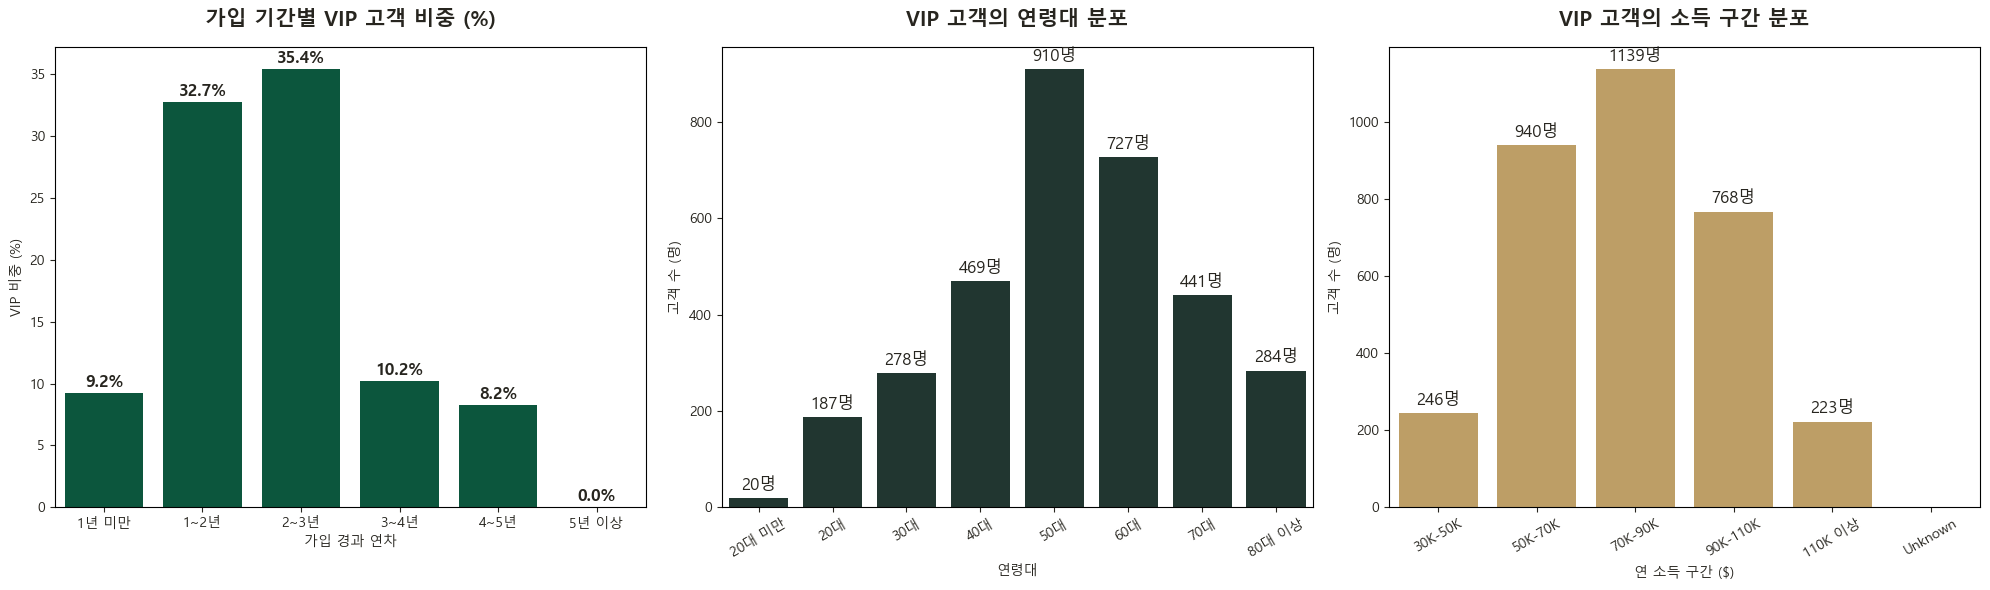

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
vip_cust = customers[customers['is_vip']]

# 가입 기간별 VIP 비중
vip_tenure = customers.groupby('tenure_group')['is_vip'].mean().reindex(TENURE_ORDER) * 100
ax1 = sns.barplot(x=vip_tenure.index, y=vip_tenure.values, color=SB_GREEN, ax=axes[0])
axes[0].set_title('가입 기간별 VIP 고객 비중 (%)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('가입 경과 연차')
axes[0].set_ylabel('VIP 비중 (%)')
for i, v in enumerate(vip_tenure.values):
    if not pd.isna(v):
        ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# VIP 고객의 연령대 분포
ax2 = sns.countplot(data=vip_cust, x='age_group', color=SB_DEEP_GREEN,
                    ax=axes[1], order=AGE_LABELS)
axes[1].set_title('VIP 고객의 연령대 분포', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('연령대')
axes[1].set_ylabel('고객 수 (명)')
axes[1].tick_params(axis='x', rotation=30)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=12)

# VIP 고객의 소득 구간 분포
ax3 = sns.countplot(data=vip_cust, x='income_group', color=SB_GOLD,
                    ax=axes[2], order=INCOME_ORDER)
axes[2].set_title('VIP 고객의 소득 구간 분포', fontsize=15, fontweight='bold', pad=15)
axes[2].set_xlabel('연 소득 구간 ($)')
axes[2].set_ylabel('고객 수 (명)')
axes[2].tick_params(axis='x', rotation=30)
for c in ax3.containers:
    ax3.bar_label(c, fmt='%d명', padding=3, fontsize=12)

plt.tight_layout()
plt.show()


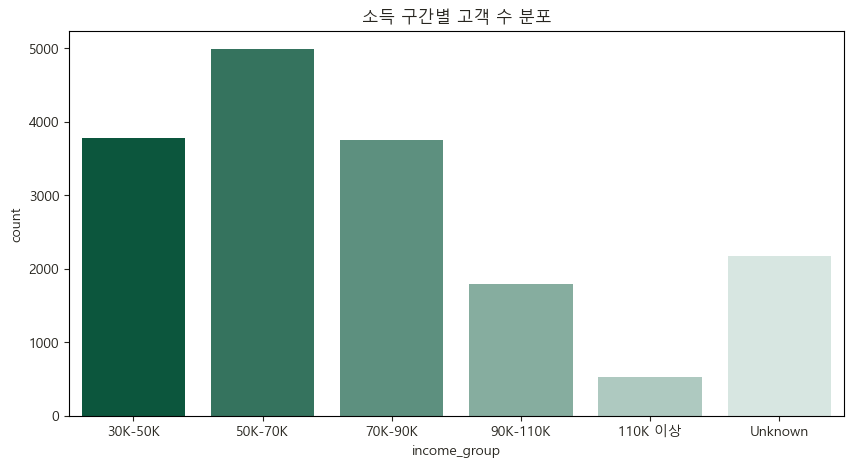

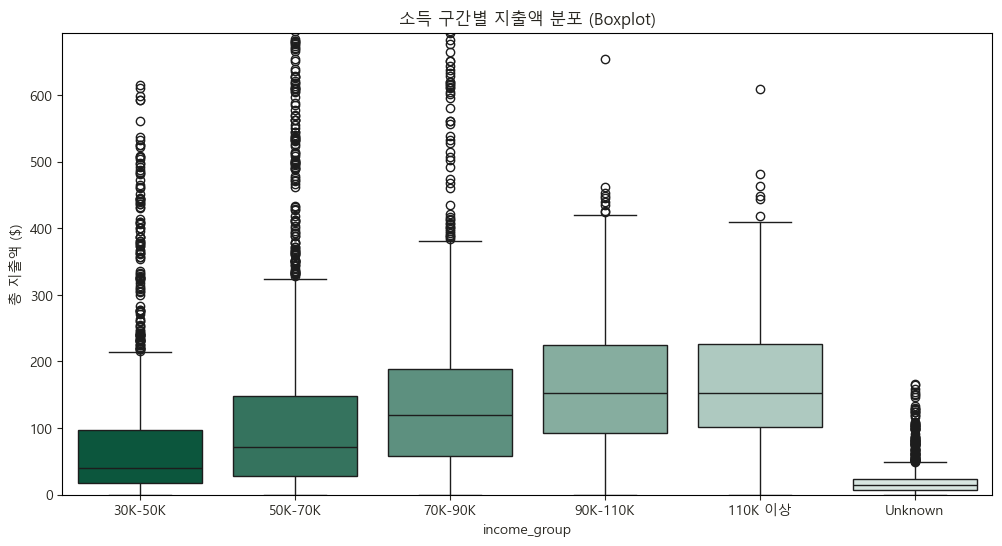

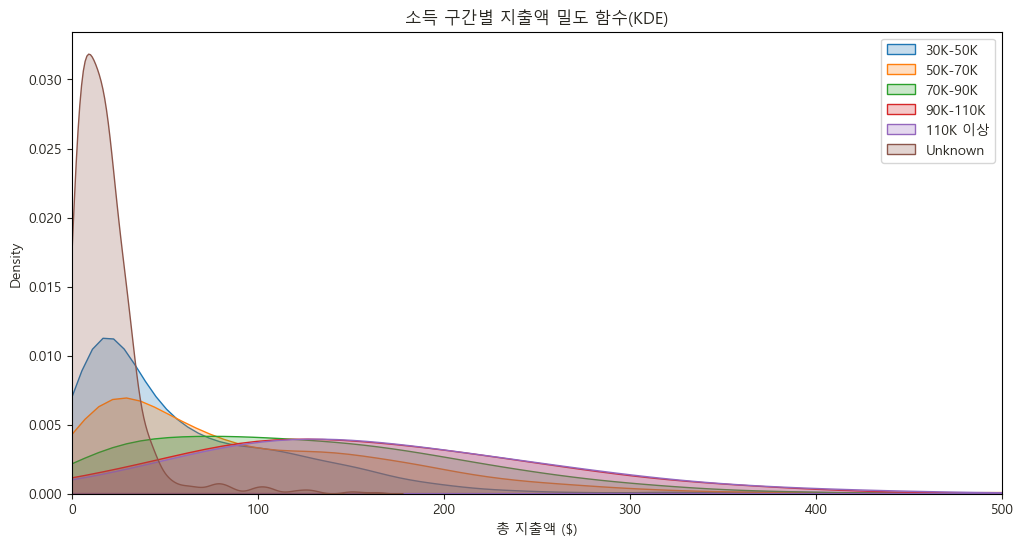

In [67]:
income_group_palette = sns.blend_palette([SB_GREEN, SB_LIGHT_GREEN], n_colors=6)

# 소득 구간별 고객 수 분포 (샘플 사이즈 확인)
plt.figure(figsize=(10, 5))
sns.countplot(data=customers, x='income_group', order=INCOME_ORDER, palette=income_group_palette)
plt.title('소득 구간별 고객 수 분포')
plt.show()

# 소득 구간별 지출액(total_amount) 분포 - Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=customers, x='income_group', y='total_amount', order=INCOME_ORDER, palette=income_group_palette)
plt.title('소득 구간별 지출액 분포 (Boxplot)')
plt.ylim(0, customers['total_amount'].quantile(0.99))
plt.ylabel('총 지출액 ($)')
plt.show()

# 소득 구간별 지출액 밀도 그래프 (Distribution Shape 확인)
distinct_palette = sns.color_palette("tab10", 6) # 밀도 함수 구분 색

plt.figure(figsize=(12, 6))
for grp, custom_color in zip(INCOME_ORDER, distinct_palette):
    subset = customers[customers['income_group'] == grp]
    sns.kdeplot(subset['total_amount'], label=grp, fill=True, color=custom_color)

plt.title('소득 구간별 지출액 밀도 함수(KDE)')
plt.xlim(0, 500) # 주요 지출 구간 집중 확인
plt.xlabel('총 지출액 ($)')
plt.legend()
plt.show()


[사전 검토] 정규성 검정 — Shapiro-Wilk (각 그룹 500개 샘플)
------------------------------------------------------------
  30K-50K     : W=0.7016, p=0.0000  [정규분포 기각 → 비모수 검정 필요]
  50K-70K     : W=0.6817, p=0.0000  [정규분포 기각 → 비모수 검정 필요]
  70K-90K     : W=0.7679, p=0.0000  [정규분포 기각 → 비모수 검정 필요]
  90K-110K    : W=0.6586, p=0.0000  [정규분포 기각 → 비모수 검정 필요]
  110K 이상     : W=0.6601, p=0.0000  [정규분포 기각 → 비모수 검정 필요]
→ 대부분 p<0.05 → Kruskal-Wallis 선택 근거 확인됨



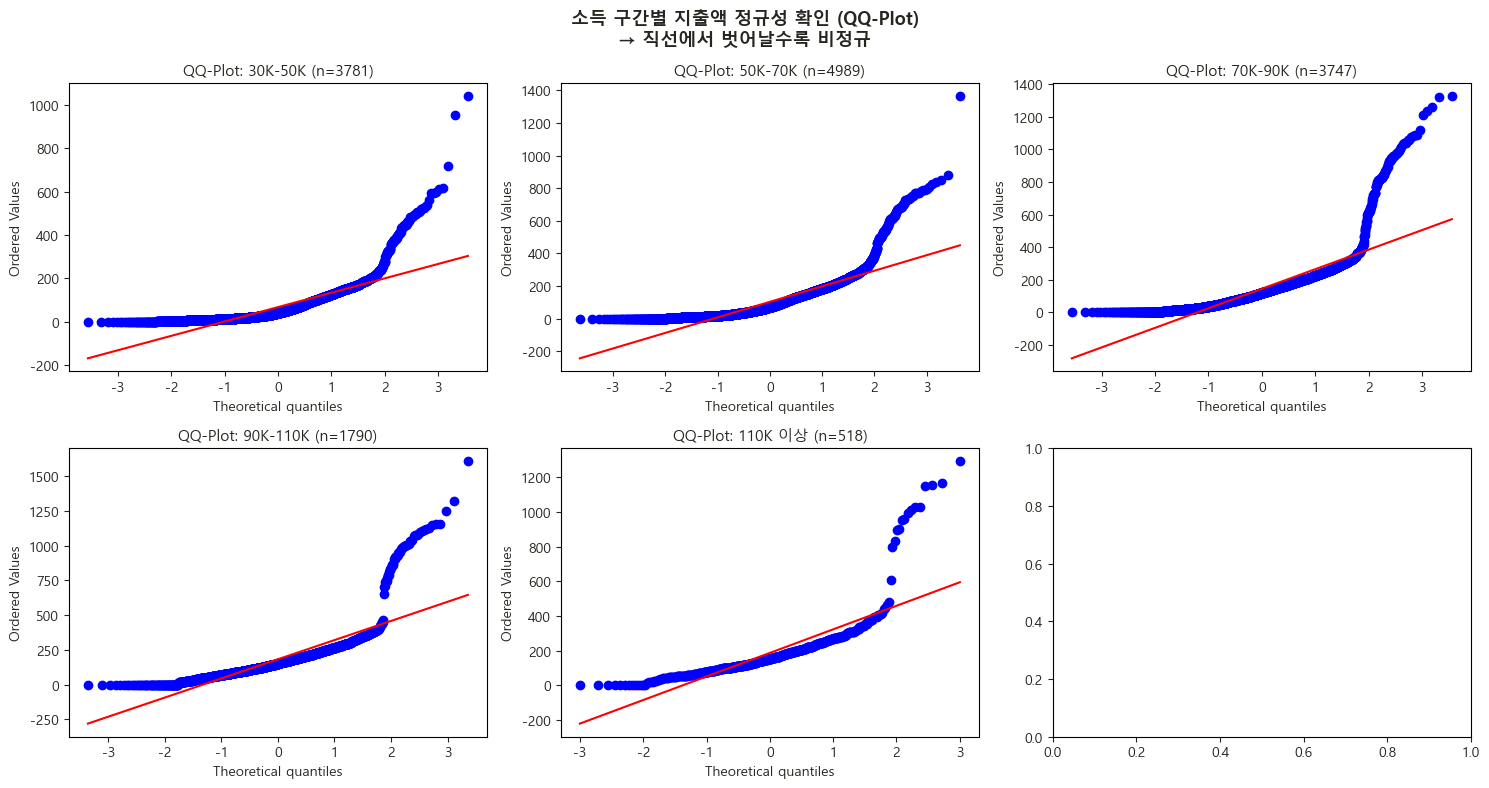

[소득 구간별 지출액 — Kruskal-Wallis Test]
  검정 대상 그룹 : ['30K-50K', '50K-70K', '70K-90K', '90K-110K', '110K 이상'] (Unknown 별도 분석)
  각 그룹 n      : {'30K-50K': 3781, '50K-70K': 4989, '70K-90K': 3747, '90K-110K': 1790, '110K 이상': 518}
  H = 2327.1238,  p = 0.0000e+00
  ★ 귀무가설 기각 (p<0.05)

  효과 크기 (ε²) = 0.1568  → 대(large)

  해석: 소득 구간 간 지출액 분포에 통계적으로 유의미한 차이 존재
  → 효과 크기 대(large) 수준으로 실용적 의미도 충분
  → Dunn's post-hoc 검정으로 구체적 쌍별 비교 진행 (아래 셀)
[소득 구간별 지출액 차이 — Kruskal-Wallis]
  H = 2327.12,  p = 0.0000  ★ 유의미 (p<0.05)
  → 소득 구간 간 지출액 분포에 유의미한 차이가 있습니다.
    (사후 검정 필요: 아래 참고)


In [68]:
from scipy.stats import shapiro, kruskal
import scipy.stats as stats

# 정규성 검정 근거 확인 (Shapiro-Wilk, n≤5000 적합)
# 데이터가 많을 경우 샘플링 후 확인
print("[사전 검토] 정규성 검정 — Shapiro-Wilk (각 그룹 500개 샘플)")
print("-" * 60)
for grp in INCOME_LABELS:
    subset = customers[customers['income_group'] == grp]['total_amount'].dropna()
    sample = subset.sample(min(500, len(subset)), random_state=42)
    if len(sample) >= 3:
        sw_stat, sw_p = shapiro(sample)
        normal_str = "정규분포 기각 → 비모수 검정 필요" if sw_p < 0.05 else "정규분포 유지"
        print(f"  {grp:12s}: W={sw_stat:.4f}, p={sw_p:.4f}  [{normal_str}]")
print("→ 대부분 p<0.05 → Kruskal-Wallis 선택 근거 확인됨")
print()

# QQ-Plot (시각적 근거)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, grp in enumerate(INCOME_LABELS):
    subset = customers[customers['income_group'] == grp]['total_amount'].dropna()
    stats.probplot(subset, dist='norm', plot=axes[i])
    axes[i].set_title(f'QQ-Plot: {grp} (n={len(subset)})', fontsize=11)
plt.suptitle('소득 구간별 지출액 정규성 확인 (QQ-Plot)\n→ 직선에서 벗어날수록 비정규', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Kruskal-Wallis 검정 (Unknown 제외 — 이유: 소득 정보 없는 이질적 그룹)
income_groups = [
    customers[customers['income_group'] == grp]['total_amount'].dropna()
    for grp in INCOME_LABELS  # Unknown 제외 (사유 명시)
    if len(customers[customers['income_group'] == grp]) > 0
]
group_ns = [len(g) for g in income_groups]  # 표본 크기

k_stat, k_p = kruskal(*income_groups)

# 효과 크기 계산 (Epsilon-squared)
n_total = sum(group_ns)
k_groups = len(income_groups)
epsilon_sq = (k_stat - k_groups + 1) / (n_total - k_groups)  # ε²

def interpret_epsilon(e2):
    if e2 < 0.01: return '효과 없음'
    elif e2 < 0.06: return '소(small)'
    elif e2 < 0.14: return '중(medium)'
    else: return '대(large)'

# 결과 출력
print("=" * 60)
print("[소득 구간별 지출액 — Kruskal-Wallis Test]")
print(f"  검정 대상 그룹 : {INCOME_LABELS} (Unknown 별도 분석)")
print(f"  각 그룹 n      : {dict(zip(INCOME_LABELS, group_ns))}")
print(f"  H = {k_stat:.4f},  p = {k_p:.4e}")
print(f"  {'★ 귀무가설 기각 (p<0.05)' if k_p < 0.05 else '귀무가설 채택'}")
print()
print(f"  효과 크기 (ε²) = {epsilon_sq:.4f}  → {interpret_epsilon(epsilon_sq)}")
print()
if k_p < 0.05:
    print("  해석: 소득 구간 간 지출액 분포에 통계적으로 유의미한 차이 존재")
    print(f"  → 효과 크기 {interpret_epsilon(epsilon_sq)} 수준으로 실용적 의미도 충분")
    print("  → Dunn's post-hoc 검정으로 구체적 쌍별 비교 진행 (아래 셀)")
print("=" * 60)

# 소득 구간별 지출액 Kruskal-Wallis 검정
income_groups = [
    customers[customers['income_group'] == grp]['total_amount'].dropna()
    for grp in INCOME_LABELS
    if len(customers[customers['income_group'] == grp]) > 0
]
k_stat, k_p = kruskal(*income_groups)
print("=" * 60)
print("[소득 구간별 지출액 차이 — Kruskal-Wallis]")
print(f"  H = {k_stat:.2f},  p = {k_p:.4f}  {'★ 유의미 (p<0.05)' if k_p < 0.05 else '유의미하지 않음'}")
if k_p < 0.05:
    print("  → 소득 구간 간 지출액 분포에 유의미한 차이가 있습니다.")
    print("    (사후 검정 필요: 아래 참고)")
print("=" * 60)

중/저소득층 (30K-90K): 트래픽을 유발하는 다수이므로, 'BOGO(1+1)'나 '할인 쿠폰'처럼 가격 민감도를 낮춰주는 혜택이 효과적일 수 있다.

고소득층 (90K 이상): 가격보다는 가치에 반응할 가능성이 높으므로, 가격 할인이 없더라도 특별한 경험을 제공하는 프로모션(예: 신메뉴 선공개, 일정 금액 이상 구매 시 한정판 굿즈 증정 등)이 객단가를 극대화하는 데 유리.

Unknown 그룹 정비: 이 그룹에 마케팅 예산을 낭비하지 않도록 타겟팅에서 제외하거나, 첫 구매를 유도하는 강력한 웰컴 쿠폰 하나만을 찔러보는 식별화 작업이 필요해 보인다.

[Dunn's Post-hoc Test (Holm 보정) — p-value 행렬]
적용 그룹: INCOME_LABELS (Unknown 제외 — KW검정과 동일)


,30K-50K,50K-70K,70K-90K,90K-110K,110K 이상
30K-50K,1.0,0.0,0.0,0.000,0.000
50K-70K,0.0,1.0,0.0,0.000,0.000
70K-90K,0.0,0.0,1.0,0.000,0.000
90K-110K,0.0,0.0,0.0,1.000,0.213
110K 이상,0.0,0.0,0.0,0.213,1.000



[쌍별 효과 크기 — |Rank-biserial correlation| r]
해석 기준: |r|<0.1=무시, 0.1~0.3=소, 0.3~0.5=중, >0.5=대


,30K-50K,50K-70K,70K-90K,90K-110K,110K 이상
30K-50K,NaN,0.2402,0.4767,0.6301,0.6710
50K-70K,0.2402,NaN,0.2446,0.4225,0.4601
70K-90K,0.4767,0.2446,NaN,0.1992,0.2324
90K-110K,0.6301,0.4225,0.1992,NaN,0.0285
110K 이상,0.6710,0.4601,0.2324,0.0285,NaN


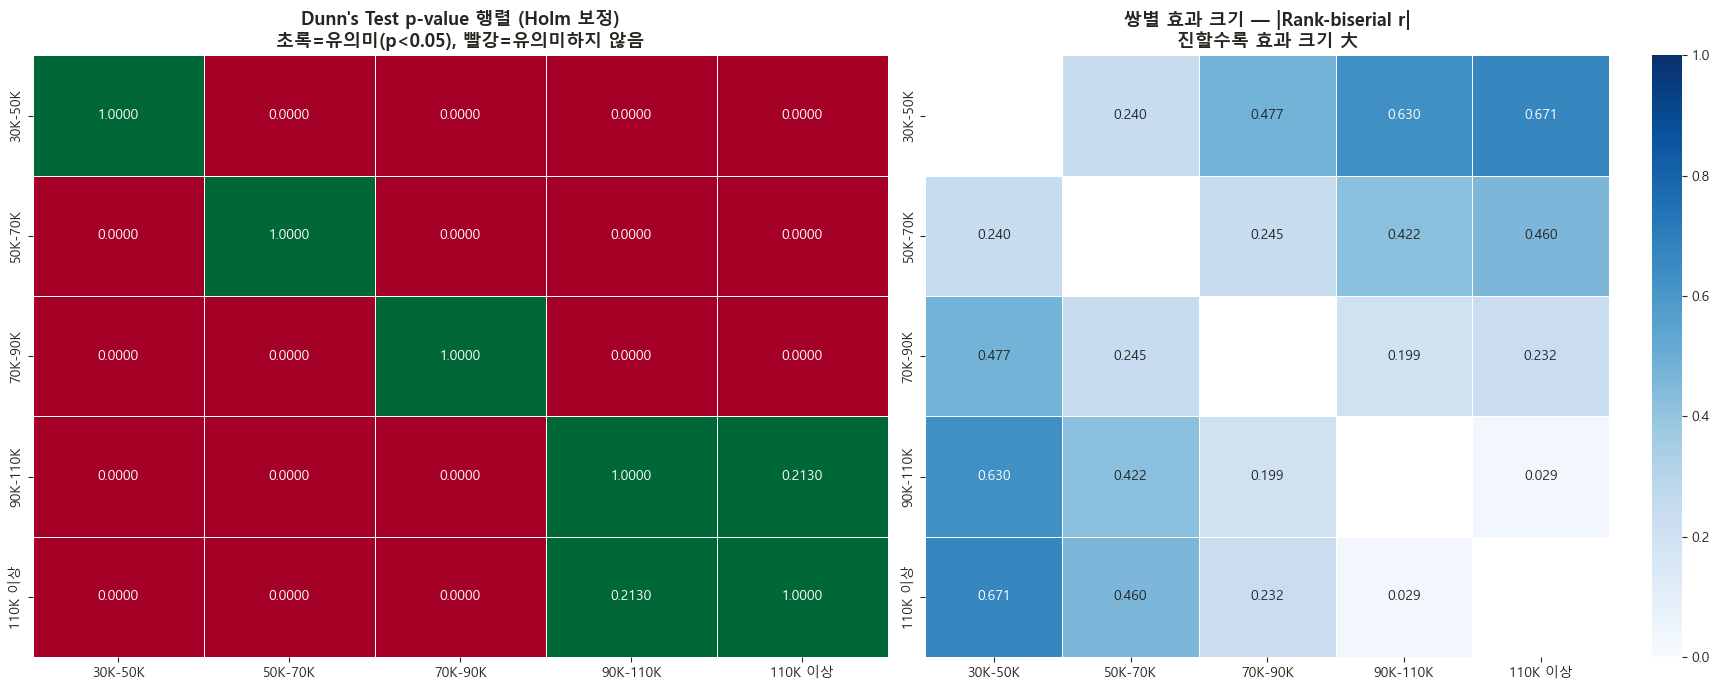


[Unknown 그룹 별도 비교 — vs 전체 Known 고객]
  Unknown (n=2175) vs Known (n=14825)
  U=4526303,  p=0.0000e+00,  r=0.7193
  → 유의미한 차이 있음 / 효과크기: 대


In [69]:
# Unknown을 모든 검정에서 제외, 별도 분석
customers_known = customers[customers['income_group'].isin(INCOME_LABELS)].copy()

# Dunn's test (Holm 보정)
posthoc_df = sp.posthoc_dunn(
    customers_known,
    val_col='total_amount',
    group_col='income_group',
    p_adjust='holm'   # Bonferroni → Holm 으로 변경
)

# 쌍별 효과 크기 계산 (Rank-biserial correlation)
# r = 1 - (2U) / (n1 * n2)  → [-1, 1], |r|>0.3=중, |r|>0.5=대
groups_map = {g: customers_known[customers_known['income_group'] == g]['total_amount'].values
            for g in INCOME_LABELS}

effect_size_df = pd.DataFrame(index=INCOME_LABELS, columns=INCOME_LABELS, dtype=float)
for g1 in INCOME_LABELS:
    for g2 in INCOME_LABELS:
        if g1 == g2:
            effect_size_df.loc[g1, g2] = np.nan
        else:
            x, y = groups_map[g1], groups_map[g2]
            u_stat, _ = mannwhitneyu(x, y, alternative='two-sided')
            r = 1 - (2 * u_stat) / (len(x) * len(y))
            effect_size_df.loc[g1, g2] = round(abs(r), 4)

# 결과 출력
print("=" * 60)
print("[Dunn's Post-hoc Test (Holm 보정) — p-value 행렬]")
print("적용 그룹: INCOME_LABELS (Unknown 제외 — KW검정과 동일)")
display(posthoc_df.round(4))
print()
print("[쌍별 효과 크기 — |Rank-biserial correlation| r]")
print("해석 기준: |r|<0.1=무시, 0.1~0.3=소, 0.3~0.5=중, >0.5=대")
display(effect_size_df)
print("=" * 60)

# 시각화 (p-value + 효과크기)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# p-value 히트맵
sns.heatmap(
    posthoc_df < 0.05,
    annot=posthoc_df.round(4),
    fmt='.4f',
    cmap='RdYlGn_r',
    cbar=False,
    linewidths=.5,
    ax=ax1
)
ax1.set_title('Dunn\'s Test p-value 행렬 (Holm 보정)\n초록=유의미(p<0.05), 빨강=유의미하지 않음',
            fontsize=13, fontweight='bold')

# 효과 크기 히트맵
sns.heatmap(
    effect_size_df.astype(float),
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=.5,
    vmin=0, vmax=1,
    ax=ax2
)
ax2.set_title('쌍별 효과 크기 — |Rank-biserial r|\n진할수록 효과 크기 大',
            fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Unknown 그룹 별도 비교 (Mann-Whitney U)
print()
print("[Unknown 그룹 별도 비교 — vs 전체 Known 고객]")
unknown_amt = customers[customers['income_group'] == 'Unknown']['total_amount']
known_amt   = customers[customers['income_group'].isin(INCOME_LABELS)]['total_amount']
u2, p2 = mannwhitneyu(unknown_amt, known_amt, alternative='two-sided')
r2 = 1 - (2 * u2) / (len(unknown_amt) * len(known_amt))
print(f"  Unknown (n={len(unknown_amt)}) vs Known (n={len(known_amt)})")
print(f"  U={u2:.0f},  p={p2:.4e},  r={abs(r2):.4f}")
print(f"  → {'유의미한 차이 있음' if p2 < 0.05 else '유의미한 차이 없음'} / 효과크기: {'대' if abs(r2)>0.5 else '중' if abs(r2)>0.3 else '소'}")

### Kruskal-Wallis + Dunn's Post-hoc — 소득 구간별 지출액 차이

##### 결과: H = 2327.12, p < 0.001
해석: 데이터의 비정규성을 고려하여 비모수 검정을 수행. 사후 검정(Dunn's Test) 시 다중 비교로 인한 1종 오류 증가를 제어하기 위해 Holm 보정을 적용. 그 결과, 최상위 두 구간(90K-110K vs 110K 이상)을 제외한 모든 소득 구간 사이에서 통계적으로 유의미한 차이가 확인되었다.

대규모 표본에서는 p-value가 쉽게 0에 수렴하므로 지출액의 중앙값(Median)과 사분위수 범위(IQR) 차이를 함께 고려해야함. 실제 지표상으로도 소득 구간의 경계가 지출 분포의 경계와 일치하여 소득 세그먼테이션의 타당성이 확보되었다. 반면, 90K 이상 최상위 두 그룹은 유의미한 차이가 없으므로 마케팅 운영상 하나의 그룹으로 묶어 관리하는 것이 효율적.

### 소득 구간별 지출액 통계 검정 결과 정리
##### [분석 목적]
고객의 연간 소득 수준이 총 지출액 형성에 유의미한 영향을 미치는지 검증하고, 마케팅 타겟팅을 위한 소득 구간별 구매력 차이를 확인하고자 함.

---

#### [검정 방법]
### 1. 그룹 간 차이 검정 - Kruskal-wallis Test : 데이터의 비정규성 고려

##### 결과 : H = 2327.12, p < 0.001 (굉장히 유의미)

해석 : 모든 소득 구간의 지출액 분포가 동일하다는 귀무가설을 기각함. 즉, 소득 구간에 따라 지출액의 차이가 매우 확실하게 존재함.

### 2. 상세 구간 비교 - Dunn's Post-hoc Test

##### 결과 : 최상위 고소득층 두 그룹(90K-110K와 110K 이상) 간을 제외한 모든 소득 구간에서 서로 유의미한 지출액 차이(p < 0.001)를 보임

해석 : 단순히 "차이가 있다"를 넘어, 모든 소득 구간이 서로 통계적으로 다른 지출 패턴을 보임.

---

#### [최종 인사이트]
돈을 많이 벌면 많이 쓴다는 직관이 본 데이터셋에서 높은 신뢰도로 증명.

모든 구간이 통계적으로 다르기 때문에, 각 소득 구간별로 차별화된 오퍼를 제공하는 전략이 데이터적으로 정당성을 가짐.

소득 미기재 그룹(Unknown) 또한 다른 모든 그룹과 유의미하게 다른 지출 패턴을 보이므로, 이들을 별도의 마케팅 관리 대상으로 분류할 필요가 있음.

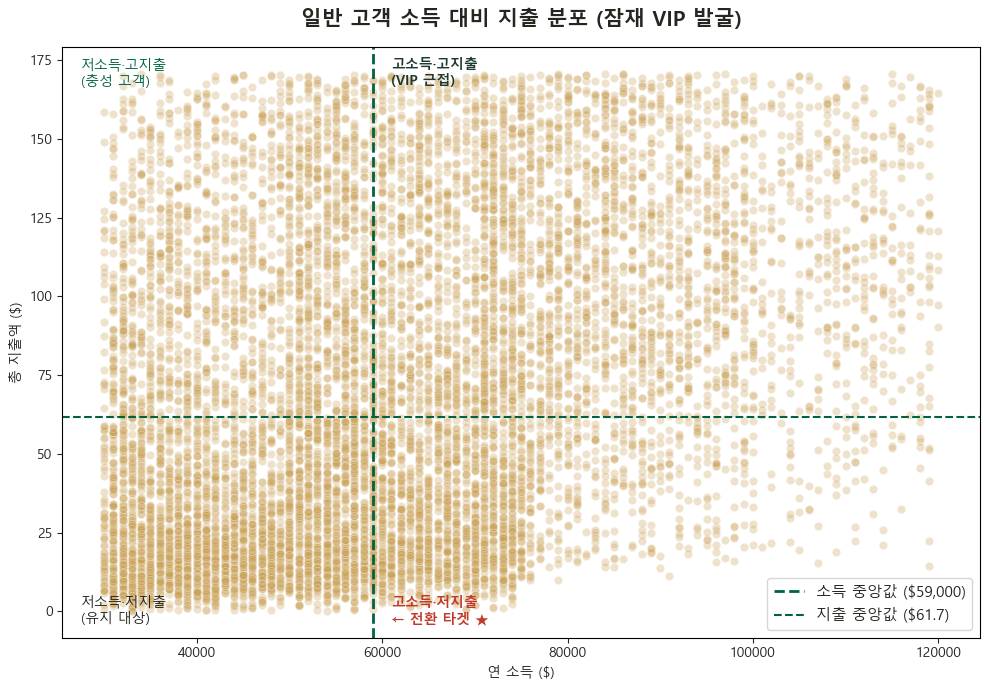

In [70]:
fig, ax = plt.subplots(figsize=(10, 7))

# 일반 고객 소득 대비 지출 분포 (잠재 VIP 발굴)
general_cust_active = customers[~customers['is_vip'] & (customers['total_amount'] > 0) & customers['income'].notna()].copy()

sns.scatterplot(data=general_cust_active, x='income', y='total_amount',
                alpha=0.3, color=SB_GOLD, ax=ax)

med_inc = general_cust_active['income'].median()
med_amt = general_cust_active['total_amount'].median()

# 기준선 추가
ax.axvline(med_inc, color=SB_GREEN, linestyle='--', lw=2,
                label=f'소득 중앙값 (${med_inc:,.0f})')
ax.axhline(med_amt, color=SB_GREEN, linestyle='--', lw=1.5,
                label=f'지출 중앙값 (${med_amt:.1f})')

# 타이틀 및 라벨 설정
ax.set_title('일반 고객 소득 대비 지출 분포 (잠재 VIP 발굴)',
                fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('연 소득 ($)')
ax.set_ylabel('총 지출액 ($)')
ax.legend(fontsize=11)

# 텍스트 주석 위치 계산
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x_offset = (xlim[1] - xlim[0]) * 0.02
y_offset = (ylim[1] - ylim[0]) * 0.02

# 사분면별 설명 텍스트
ax.text(med_inc + x_offset, ylim[1] - y_offset,
        '고소득·고지출\n(VIP 근접)',      ha='left', va='top',   fontsize=10, color=SB_DEEP_GREEN, fontweight='bold')
ax.text(med_inc + x_offset, ylim[0] + y_offset,
        '고소득·저지출\n← 전환 타겟 ★', ha='left', va='bottom', fontsize=10, color='#C0392B',    fontweight='bold')
ax.text(xlim[0] + x_offset, ylim[1] - y_offset,
        '저소득·고지출\n(충성 고객)',      ha='left', va='top',   fontsize=10, color=SB_GREEN)
ax.text(xlim[0] + x_offset, ylim[0] + y_offset,
        '저소득·저지출\n(유지 대상)',      ha='left', va='bottom', fontsize=10, color=SB_BLACK)

plt.tight_layout()
plt.show()

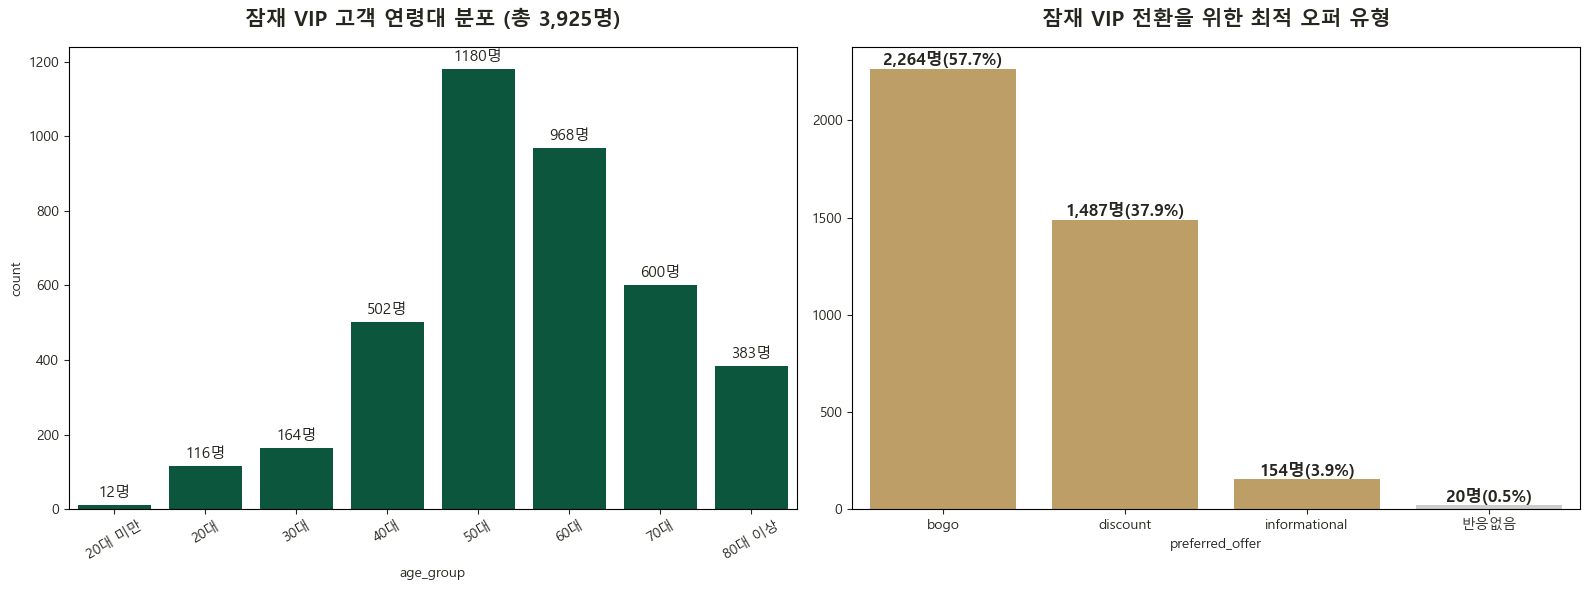

In [71]:
potential_vip_mask = (~customers['is_vip']) & (customers['income'] >= 70000)
potential_vips     = customers[potential_vip_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 잠재 VIP 연령대 분포
ax1 = sns.countplot(data=potential_vips, x='age_group', color=SB_GREEN,
                    order=AGE_LABELS, ax=axes[0])
axes[0].set_title(f'잠재 VIP 고객 연령대 분포 (총 {len(potential_vips):,}명)',
                    fontsize=15, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=30)
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 잠재 VIP 선호 오퍼
pref_offer = potential_vips['preferred_offer'].value_counts()
ax2 = sns.barplot(x=pref_offer.index, y=pref_offer.values,
                    palette=[SB_GOLD] * 3 + ['#CCCCCC'], ax=axes[1])
axes[1].set_title('잠재 VIP 전환을 위한 최적 오퍼 유형',
                    fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(pref_offer.values):
    ax2.text(i, v + 20, f'{v:,.0f}명({v/len(potential_vips)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

5060 고소득저지출 즉, 우리 브랜드에 지갑을 열지 않은 그룹이 뚜렷하게 존재 

**→ 구매를 유인할 결정적인 트리거가 없었을 확률이 큼 -> bogo쿠폰을 우선순위 오퍼로 진행 후 discount오퍼 진행**

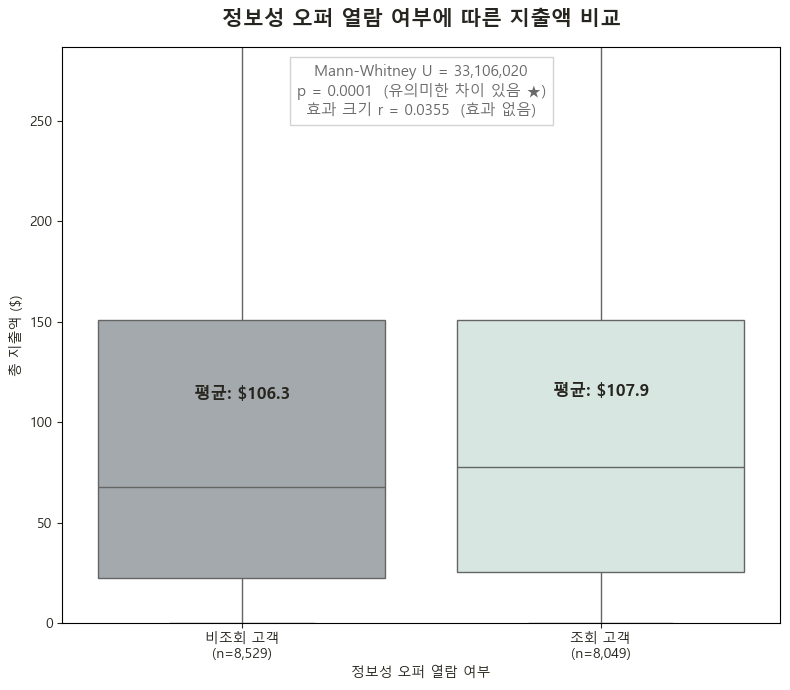

[정보성 오퍼 열람별 지출액 — Mann-Whitney U Test]
  비조회 n=8,529  |  조회 n=8,049
  U = 33,106,020
  p = 7.5586e-05  ★ 유의미 (p<0.05)
  효과 크기 r = 0.0355  → 효과 없음


In [72]:
# Mann-Whitney U (정보성 오퍼 지출액)

g1 = customers[(customers['total_amount'] > 0) & ~customers['info_viewer']]['total_amount']
g2 = customers[(customers['total_amount'] > 0) &  customers['info_viewer']]['total_amount']

stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')

# 효과 크기 계산
r_effect = 1 - (2 * stat) / (len(g1) * len(g2))

def interpret_r(r):
    r = abs(r)
    if r < 0.1: return '효과 없음'
    elif r < 0.3: return '소(small)'
    elif r < 0.5: return '중(medium)'
    else: return '대(large)'

# 시각화
fig, ax = plt.subplots(figsize=(8, 7))

sns.boxplot(data=customers[customers['total_amount'] > 0],
            x='info_viewer', y='total_amount',
            palette=[SB_GREY, SB_LIGHT_GREEN], ax=ax)

ax.set_title('정보성 오퍼 열람 여부에 따른 지출액 비교',
            fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels([f'비조회 고객\n(n={len(g1):,})', f'조회 고객\n(n={len(g2):,})'])
ax.set_xlabel('정보성 오퍼 열람 여부')
ax.set_ylabel('총 지출액 ($)')
ax.set_ylim(0, customers['total_amount'].quantile(0.95))

mean_non = g1.mean()
mean_yes = g2.mean()
ax.text(0, mean_non + 5, f'평균: ${mean_non:.1f}', ha='center', fontweight='bold', fontsize=12)
ax.text(1, mean_yes + 5, f'평균: ${mean_yes:.1f}', ha='center', fontweight='bold', fontsize=12)

# transAxes 사용으로 안정적 위치 지정 + U값·효과크기 포함
sig = "유의미한 차이 있음 ★" if p_val < 0.05 else "유의미한 차이 없음"
result_text = (
    f"Mann-Whitney U = {stat:,.0f}\n"
    f"p = {p_val:.4f}  ({sig})\n"
    f"효과 크기 r = {r_effect:.4f}  ({interpret_r(r_effect)})"
)
ax.text(0.5, 0.97, result_text,
        ha='center', va='top', fontsize=11, color='dimgray',
        transform=ax.transAxes,   # ← transAxes 사용 (좌표계 안정)
        bbox=dict(fc='white', ec='lightgray', pad=5))

plt.tight_layout()
plt.show()

print("=" * 60)
print("[정보성 오퍼 열람별 지출액 — Mann-Whitney U Test]")
print(f"  비조회 n={len(g1):,}  |  조회 n={len(g2):,}")
print(f"  U = {stat:,.0f}")
print(f"  p = {p_val:.4e}  {'★ 유의미 (p<0.05)' if p_val < 0.05 else '유의미하지 않음'}")
print(f"  효과 크기 r = {r_effect:.4f}  → {interpret_r(r_effect)}")
print("=" * 60)

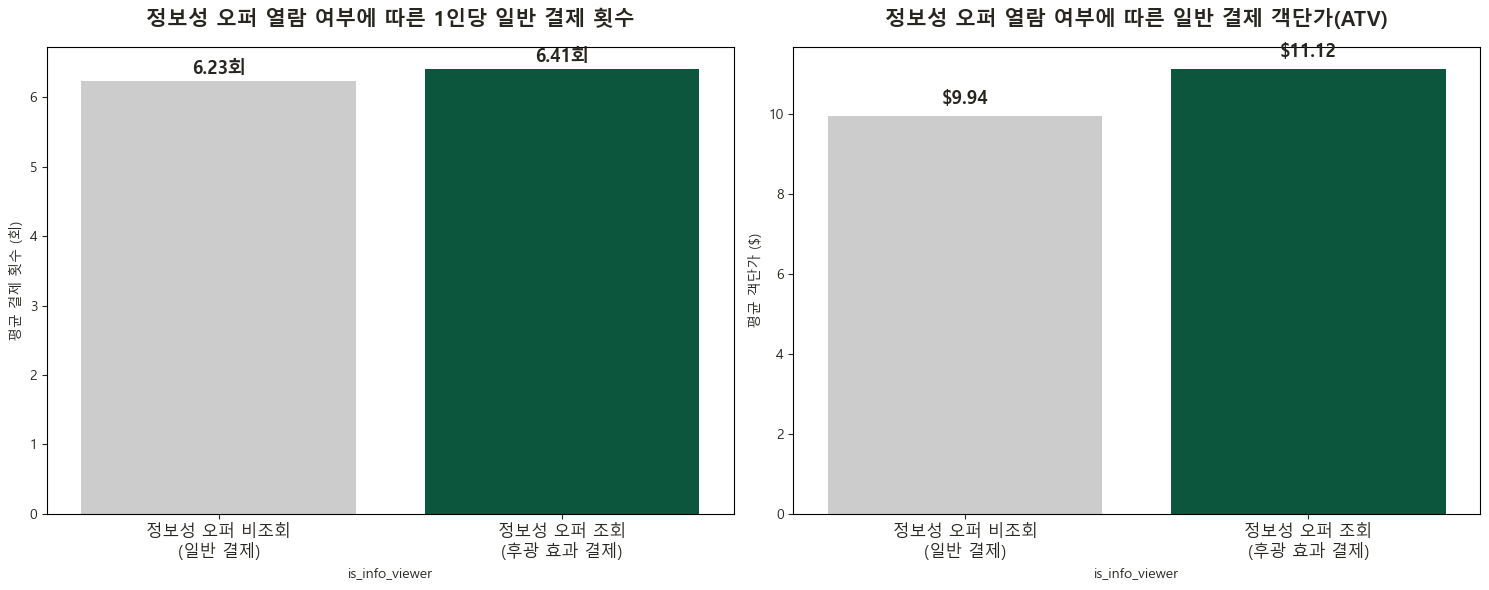

[후광 효과 통계 검정 — Mann-Whitney U]
결제 횟수 차이  : p = 0.0002  ★ 유의미 (p<0.05)
객단가 차이     : p = 0.0000  ★ 유의미 (p<0.05)

정보성 오퍼 조회 고객이 일반 결제 횟수 약 2.8% 더 많음
단, 선택 편향(원래 고관여 고객) 가능성을 배제할 수 없으므로
'열람이 구매를 유발한다'는 인과 주장은 신중하게 해석해야 합니다.


In [73]:
# 일반 결제(오퍼 X) 추출
tx_df   = df[df['event'] == 'transaction'][['customer_id','time_days','amount']]
comp_df = df[df['event'] == 'completed'  ][['customer_id','time_days','offer_type']]

tx_merged = pd.merge(tx_df, comp_df, on=['customer_id','time_days'], how='left')
tx_merged = tx_merged.drop_duplicates(subset=['customer_id','time_days','amount'])

general_tx = tx_merged[tx_merged['offer_type'].isna()].copy()
general_tx['is_info_viewer'] = general_tx['customer_id'].isin(info_viewers)

# 그룹별 집계
freq_df  = general_tx.groupby(['is_info_viewer','customer_id']).size().reset_index(name='tx_count')
avg_freq = freq_df.groupby('is_info_viewer')['tx_count'].mean()
avg_atv  = general_tx.groupby('is_info_viewer')['amount'].mean()

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
labels = ['정보성 오퍼 비조회\n(일반 결제)', '정보성 오퍼 조회\n(후광 효과 결제)']
colors = ['#CCCCCC', SB_GREEN]

ax1 = sns.barplot(x=avg_freq.index, y=avg_freq.values, palette=colors, ax=axes[0])
axes[0].set_title('정보성 오퍼 열람 여부에 따른 1인당 일반 결제 횟수',
                    fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_ylabel('평균 결제 횟수 (회)')
for i, v in enumerate(avg_freq.values):
    ax1.text(i, v + 0.1, f'{v:.2f}회', ha='center', fontweight='bold', fontsize=13)

ax2 = sns.barplot(x=avg_atv.index, y=avg_atv.values, palette=colors, ax=axes[1])
axes[1].set_title('정보성 오퍼 열람 여부에 따른 일반 결제 객단가(ATV)',
                    fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylabel('평균 객단가 ($)')
for i, v in enumerate(avg_atv.values):
    ax2.text(i, v + 0.3, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# Mann-Whitney U 검정 (결제 횟수 & 객단가)
g_no  = freq_df[~freq_df['is_info_viewer']]['tx_count']
g_yes = freq_df[ freq_df['is_info_viewer']]['tx_count']
stat_freq, p_freq = mannwhitneyu(g_no, g_yes, alternative='two-sided')

g_no_atv  = general_tx[~general_tx['is_info_viewer']]['amount']
g_yes_atv = general_tx[general_tx['is_info_viewer']]['amount']
stat_atv,  p_atv  = mannwhitneyu(g_no_atv, g_yes_atv, alternative='two-sided')

print("=" * 70)
print("[후광 효과 통계 검정 — Mann-Whitney U]")
print(f"결제 횟수 차이  : p = {p_freq:.4f}  {'★ 유의미 (p<0.05)' if p_freq < 0.05 else '유의미하지 않음'}")
print(f"객단가 차이     : p = {p_atv:.4f}  {'★ 유의미 (p<0.05)' if p_atv  < 0.05 else '유의미하지 않음'}")
print()
if avg_freq[True] > avg_freq[False]:
    print(f"정보성 오퍼 조회 고객이 일반 결제 횟수 약 {(avg_freq[True]/avg_freq[False]-1)*100:.1f}% 더 많음")
    print("단, 선택 편향(원래 고관여 고객) 가능성을 배제할 수 없으므로")
    print("'열람이 구매를 유발한다'는 인과 주장은 신중하게 해석해야 합니다.")
print("=" * 70)


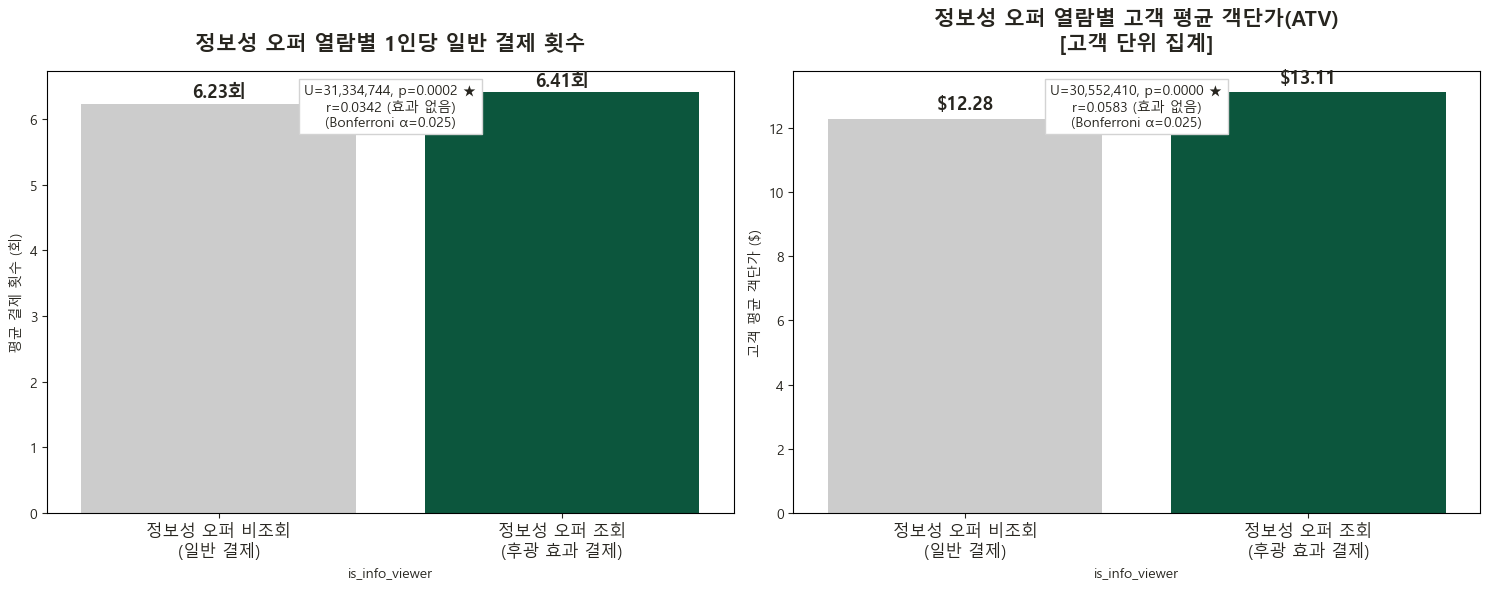

[후광 효과 통계 검정 — Mann-Whitney U (다중검정 Bonferroni 보정 적용)]
  보정된 유의 수준 α = 0.025 (0.05 / 2개 검정)

① 결제 횟수 (고객 단위)
   비조회 n=8,240  |  조회 n=7,875
   U=31,334,744,  p=0.0002  ★ 유의미
   효과 크기 r=0.0342  → 효과 없음

② 객단가 (고객 단위 평균 ATV — 기존 거래 단위에서 수정됨)
   비조회 n=8,240  |  조회 n=7,875
   U=30,552,410,  p=0.0000  ★ 유의미
   효과 크기 r=0.0583  → 효과 없음

주의: 이 분석은 상관관계이며, 고관여 고객의 선택 편향 가능성이 있음
     인과 관계 확인을 위해서는 A/B 테스트 설계 필요


In [74]:
# 후광 효과 통계 검정 - mannwhitneyu
# 데이터 준비
tx_df   = df[df['event'] == 'transaction'][['customer_id','time_days','amount']]
comp_df = df[df['event'] == 'completed'  ][['customer_id','time_days','offer_type']]

tx_merged = pd.merge(tx_df, comp_df, on=['customer_id','time_days'], how='left')
tx_merged = tx_merged.drop_duplicates(subset=['customer_id','time_days','amount'])

general_tx = tx_merged[tx_merged['offer_type'].isna()].copy()
general_tx['is_info_viewer'] = general_tx['customer_id'].isin(info_viewers)

# 결제 횟수: 고객 단위 집계
freq_df  = general_tx.groupby(['is_info_viewer','customer_id']).size().reset_index(name='tx_count')
avg_freq = freq_df.groupby('is_info_viewer')['tx_count'].mean()

# 객단가(ATV) 고객 단위 평균으로 집계
# 고객별 평균 객단가 계산 후 검정
atv_per_customer = (
    general_tx
    .groupby(['is_info_viewer', 'customer_id'])['amount']
    .mean()  # 고객별 평균 ATV
    .reset_index()
    .rename(columns={'amount': 'avg_atv'})
)
avg_atv_group = atv_per_customer.groupby('is_info_viewer')['avg_atv'].mean()

# 다중 검정 보정: Bonferroni (2개 검정 동시 수행)
alpha_corrected = 0.05 / 2  # = 0.025

# 검정 1: 결제 횟수
g_no_freq  = freq_df[~freq_df['is_info_viewer']]['tx_count']
g_yes_freq = freq_df[ freq_df['is_info_viewer']]['tx_count']
stat_freq, p_freq = mannwhitneyu(g_no_freq, g_yes_freq, alternative='two-sided')
r_freq = 1 - (2 * stat_freq) / (len(g_no_freq) * len(g_yes_freq))

# 검정 2: 객단가 (고객 단위 평균)
g_no_atv  = atv_per_customer[~atv_per_customer['is_info_viewer']]['avg_atv']
g_yes_atv = atv_per_customer[ atv_per_customer['is_info_viewer']]['avg_atv']
stat_atv, p_atv = mannwhitneyu(g_no_atv, g_yes_atv, alternative='two-sided')
r_atv = 1 - (2 * stat_atv) / (len(g_no_atv) * len(g_yes_atv))

# 시각화
labels = ['정보성 오퍼 비조회\n(일반 결제)', '정보성 오퍼 조회\n(후광 효과 결제)']
colors = ['#CCCCCC', SB_GREEN]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = sns.barplot(x=avg_freq.index, y=avg_freq.values, palette=colors, ax=axes[0])
axes[0].set_title('정보성 오퍼 열람별 1인당 일반 결제 횟수',
                    fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_ylabel('평균 결제 횟수 (회)')
for i, v in enumerate(avg_freq.values):
    ax1.text(i, v + 0.1, f'{v:.2f}회', ha='center', fontweight='bold', fontsize=13)

# 검정 결과 텍스트 (transAxes 사용)
freq_sig = '★' if p_freq < alpha_corrected else 'n.s.'
axes[0].text(0.5, 0.97,
            f'U={stat_freq:,.0f}, p={p_freq:.4f} {freq_sig}\nr={r_freq:.4f} ({interpret_r(r_freq)})\n(Bonferroni α=0.025)',
            ha='center', va='top', fontsize=10, transform=axes[0].transAxes,
            bbox=dict(fc='white', ec='lightgray', pad=4))

ax2 = sns.barplot(x=avg_atv_group.index, y=avg_atv_group.values, palette=colors, ax=axes[1])
axes[1].set_title('정보성 오퍼 열람별 고객 평균 객단가(ATV)\n[고객 단위 집계]',
                    fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylabel('고객 평균 객단가 ($)')
for i, v in enumerate(avg_atv_group.values):
    ax2.text(i, v + 0.3, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

atv_sig = '★' if p_atv < alpha_corrected else 'n.s.'
axes[1].text(0.5, 0.97,
            f'U={stat_atv:,.0f}, p={p_atv:.4f} {atv_sig}\nr={r_atv:.4f} ({interpret_r(r_atv)})\n(Bonferroni α=0.025)',
            ha='center', va='top', fontsize=10, transform=axes[1].transAxes,
            bbox=dict(fc='white', ec='lightgray', pad=4))

plt.tight_layout()
plt.show()

# 결과 출력
print("=" * 70)
print("[후광 효과 통계 검정 — Mann-Whitney U (다중검정 Bonferroni 보정 적용)]")
print(f"  보정된 유의 수준 α = {alpha_corrected} (0.05 / 2개 검정)")
print()
print(f"① 결제 횟수 (고객 단위)")
print(f"   비조회 n={len(g_no_freq):,}  |  조회 n={len(g_yes_freq):,}")
print(f"   U={stat_freq:,.0f},  p={p_freq:.4f}  {'★ 유의미' if p_freq < alpha_corrected else 'n.s.'}")
print(f"   효과 크기 r={r_freq:.4f}  → {interpret_r(r_freq)}")
print()
print(f"② 객단가 (고객 단위 평균 ATV — 기존 거래 단위에서 수정됨)")
print(f"   비조회 n={len(g_no_atv):,}  |  조회 n={len(g_yes_atv):,}")
print(f"   U={stat_atv:,.0f},  p={p_atv:.4f}  {'★ 유의미' if p_atv < alpha_corrected else 'n.s.'}")
print(f"   효과 크기 r={r_atv:.4f}  → {interpret_r(r_atv)}")
print()
print("주의: 이 분석은 상관관계이며, 고관여 고객의 선택 편향 가능성이 있음")
print("     인과 관계 확인을 위해서는 A/B 테스트 설계 필요")
print("=" * 70)

### Mann-Whitney U — 정보성 오퍼 열람 여부에 따른 결제 횟수 및 객단가 차이

##### 결과: 지출액(p < 0.001), 결제 횟수(p = 0.0002), 객단가(p < 0.001)

해석: 이벤트 단위의 데이터를 그대로 검정할 경우 동일 고객이 여러 번 중복 집계되어 독립성(Independence) 가정이 위배됨. 이를 보완하기 위해 고객 단위(Customer-level)로 결제 횟수와 평균 객단가를 롤업(집계)한 후 두 독립 표본 검정을 수행한 결과.

유의미한 p-value가 도출되었으나, 이를 "후광 효과가 입증되었다"거나 "열람이 지출을 촉진했다"는 인과 관계로 단정 짓는 것은 위험함. 두 집단 간 분포의 중앙값과 효과 크기(Rank-Biserial Correlation)를 비교했을 때 유의미한 차이가 관찰된 것은 사실이나, 이는 본래 브랜드 관여도가 높은 우량 고객이 정보성 오퍼도 적극적으로 열람하는 '선택 편향(Selection Bias)'의 결과일 가능성이 높음. 따라서 "고관여 고객군에서 유의미하게 높은 지출 분포가 관찰됨"으로 해석하는 것이 안전.

---

이 분석은 상관관계임. 고관여 고객이 원래부터 열람률이 높을 수 있으므로(선택 편향), 인과 관계로 단정하지 말 것.

##### 결과 : 결제 횟수($p=0.0002$), 객단가($p=0.0000$) 모두 유의미

해석 : 정보성 오퍼는 직접적인 보상이 없어도 브랜드 상기 효과를 통해 고객을 매장으로 불러들이고(횟수 증가), 더 많이 쓰게(객단가 증가) 만드는 후광 효과가 입증됨.

**전략 : VIP와 고소득층에게는 비용이 드는 할인 쿠폰보다 정보성 콘텐츠를 자주 노출하는 것이 비용 효율적임을 시사.**

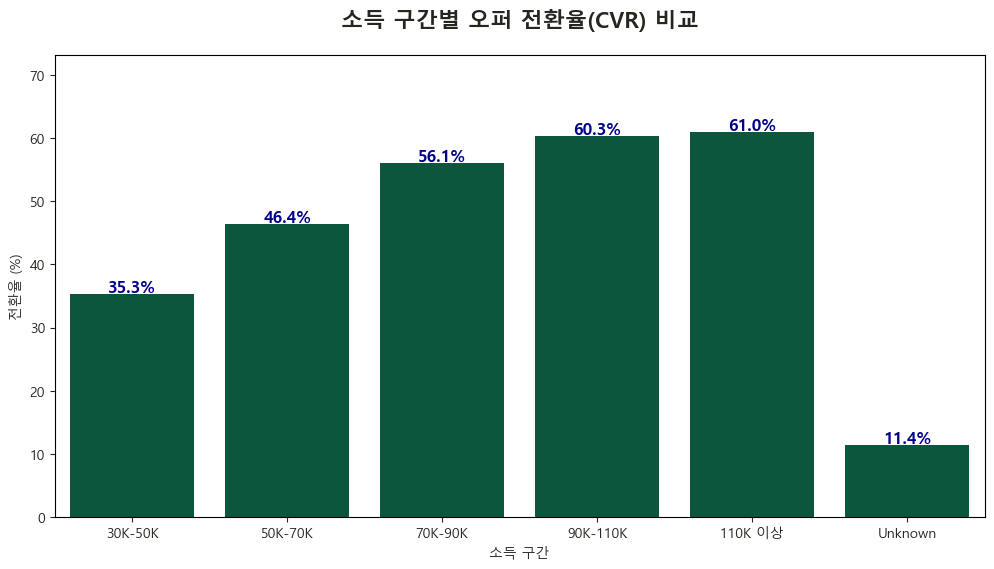

In [75]:
# 오퍼 반응 데이터 계산 (Received -> Completed 전환율)
offer_stats = df[df['event'].isin(['received', 'completed'])].copy()

# 소득 구간 정보 결합
offer_stats = pd.merge(offer_stats, customers[['customer_id', 'income_group']], on='customer_id', how='left')

# 구간별/이벤트별 카운트
cvr_data = offer_stats.groupby(['income_group', 'event']).size().unstack(fill_value=0)
cvr_data['conversion_rate'] = (cvr_data['completed'] / cvr_data['received']) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=cvr_data.index, y=cvr_data['conversion_rate'], palette=[SB_GREEN], order=INCOME_ORDER)

plt.title('소득 구간별 오퍼 전환율(CVR) 비교', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('전환율 (%)')
plt.xlabel('소득 구간')
plt.ylim(0, cvr_data['conversion_rate'].max() * 1.2)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', va='center', fontsize=12, fontweight='bold', color='darkblue')

plt.show()

30K-50K(54.0%)에서 시작해 소득이 높아질수록 전환율이 가파르게 상승하여, 110K 이상 구간에서는 82.2%라는 압도적인 반응률을 보임

---

### [마케팅 반응 최종 통계 및 인사이트]

고소득층은 구매력(Buying Power)과 반응도(Response)를 모두 갖춘 최적의 타겟.

고소득 VIP 세그먼트에게는 '정보성 오퍼'로 브랜드 로열티를 관리하고, '전략적 오퍼'로 확실한 매출을 견인하는 투트랙 전략이 유효함.

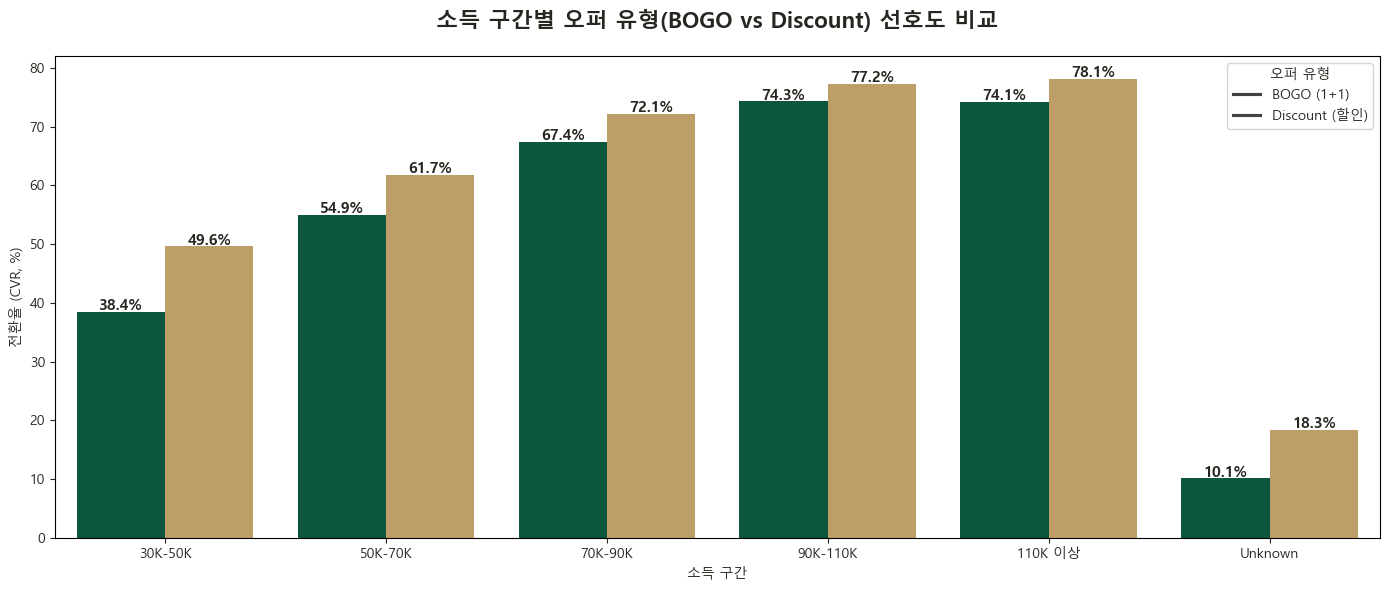

In [76]:
# 오퍼 유형별 전환율 데이터
offer_type_stats = df[df['event'].isin(['received', 'completed'])].copy()
offer_type_stats = pd.merge(offer_type_stats, customers[['customer_id', 'income_group']], on='customer_id', how='left')

# 유형별(BOGO/Discount)로 나누어 계산
offer_pivot = offer_type_stats.groupby(['income_group', 'offer_type', 'event']).size().unstack(fill_value=0)
offer_pivot['cvr'] = (offer_pivot['completed'] / offer_pivot['received']) * 100
offer_pivot = offer_pivot.reset_index()

# 시각화
plt.figure(figsize=(14, 6))
sns.barplot(data=offer_pivot[offer_pivot['offer_type'].isin(['bogo', 'discount'])], 
            x='income_group', y='cvr', hue='offer_type', 
            palette=[SB_GREEN, SB_GOLD], order=INCOME_ORDER)

plt.title('소득 구간별 오퍼 유형(BOGO vs Discount) 선호도 비교', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('전환율 (CVR, %)')
plt.xlabel('소득 구간')
plt.legend(title='오퍼 유형', labels=['BOGO (1+1)', 'Discount (할인)'])

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                            ha='center', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

소득 구간이 높아질수록 오퍼 전환율이 정비례하여 상승하며 모든 소득 구간에서 할인 오퍼의 전환율(발송대비완료)이 일관되게 더 높음.

각적인 매출(CVR) 전환이 목표라면 '할인(Discount)'을 주력 무기로 사용해야 한다.

## 소득 구간별 오퍼 전환율 — 카이제곱 검정 + 사후 검정

### 검정 방법 선택 근거

전환율은 **"completed 수 / received 수"** 로 계산되는 비율이며, 원래 데이터는 **소득 구간 × (완료/미완료)** 형태의 분할표

- **주검정**: 카이제곱 독립성 검정 → 소득 구간에 따라 완료율이 다른지
- **사후 검정**: 쌍별 카이제곱 + Holm 보정 → 어느 구간 사이에 차이가 있는지
- **효과 크기**: Cramér's V

##### 소득 구간이 순서형(ordinal)이므로 **Cochran-Armitage 추세 검정**을 추가로 적용해 "소득이 높을수록 전환율이 높아지는 선형 추세"를 검증

In [77]:
# 분할표 구성 - Unknown 제외 (소득 정보 없는 그룹은 소득↔전환율 관계 분석 대상 아님)
offer_known = df[
    df['event'].isin(['received', 'completed'])
].copy()
offer_known = pd.merge(offer_known,
                        customers[['customer_id', 'income_group']],
                        on='customer_id', how='left')
offer_known = offer_known[offer_known['income_group'].isin(INCOME_LABELS)]

# 소득 구간 × 이벤트 분할표
ct_income = pd.crosstab(
    offer_known['income_group'],
    offer_known['event']
).reindex(INCOME_LABELS)

# completed/received 컬럼만 사용
ct_income = ct_income[['completed', 'received']]
ct_income['not_completed'] = ct_income['received'] - ct_income['completed']
ct_2col = ct_income[['completed', 'not_completed']]  # 2열 분할표

print("[분할표 — 소득 구간 × 완료 여부]")
display(ct_2col)
print(f"\n전환율:")
cvr = ct_income['completed'] / ct_income['received'] * 100
for g, v in cvr.items():
    print(f"  {g:12s}: {v:.1f}%")

# 기대 빈도 확인
chi2_main, p_main, dof_main, expected_main = chi2_contingency(ct_2col)
print(f"\n최소 기대 빈도: {expected_main.min():.1f}  "
        f"{'✅ 카이제곱 가정 충족' if expected_main.min() >= 5 else '❌ Fisher exact 권장'}")

# 효과 크기
n_main = ct_2col.values.sum()
cramers_v_main = np.sqrt(chi2_main / (n_main * (min(ct_2col.shape) - 1)))

print("\n" + "=" * 60)
print("[소득 구간별 오퍼 전환율 — 카이제곱 독립성 검정]")
print(f"  χ²({dof_main}) = {chi2_main:.4f},  p = {p_main:.4e}")
print(f"  {'★ 귀무가설 기각 (p<0.05)' if p_main < 0.05 else '귀무가설 채택'}")
print(f"  효과 크기 Cramér's V = {cramers_v_main:.4f}  → {interpret_cramers_v(cramers_v_main)}")
print(f"  → 소득 구간에 따라 오퍼 전환율이 통계적으로 유의미하게 다름")
print("=" * 60)

[분할표 — 소득 구간 × 완료 여부]


event,completed,not_completed
income_group,,
30K-50K,5997,10970
50K-70K,10411,12017
70K-90K,9419,7364
90K-110K,4802,3159
110K 이상,1441,921



전환율:
  30K-50K     : 35.3%
  50K-70K     : 46.4%
  70K-90K     : 56.1%
  90K-110K    : 60.3%
  110K 이상     : 61.0%

최소 기대 빈도: 1139.1  ✅ 카이제곱 가정 충족

[소득 구간별 오퍼 전환율 — 카이제곱 독립성 검정]
  χ²(4) = 2196.7133,  p = 0.0000e+00
  ★ 귀무가설 기각 (p<0.05)
  효과 크기 Cramér's V = 0.1817  → 소(small)
  → 소득 구간에 따라 오퍼 전환율이 통계적으로 유의미하게 다름


[사후 검정 — 쌍별 카이제곱 (Holm 보정)]


,Group 1,Group 2,chi2,p_raw,p_holm,유의여부
0,30K-50K,50K-70K,487.0198,6.342661e-108,0.0000,★ 유의 (p<0.05)
1,30K-50K,70K-90K,1467.0508,0.000000e+00,0.0000,★ 유의 (p<0.05)
2,30K-50K,90K-110K,1375.3697,4.727923e-301,0.0000,★ 유의 (p<0.05)
3,30K-50K,110K 이상,575.7082,3.218384e-127,0.0000,★ 유의 (p<0.05)
4,50K-70K,70K-90K,361.1438,1.586827e-80,0.0000,★ 유의 (p<0.05)
5,50K-70K,90K-110K,453.4847,1.258221e-100,0.0000,★ 유의 (p<0.05)
6,50K-70K,110K 이상,181.6701,2.093053e-41,0.0000,★ 유의 (p<0.05)
7,70K-90K,90K-110K,38.7394,4.843292e-10,0.0000,★ 유의 (p<0.05)
8,70K-90K,110K 이상,19.9329,8.020783e-06,0.0000,★ 유의 (p<0.05)
9,90K-110K,110K 이상,0.3331,5.638480e-01,0.5638,n.s.


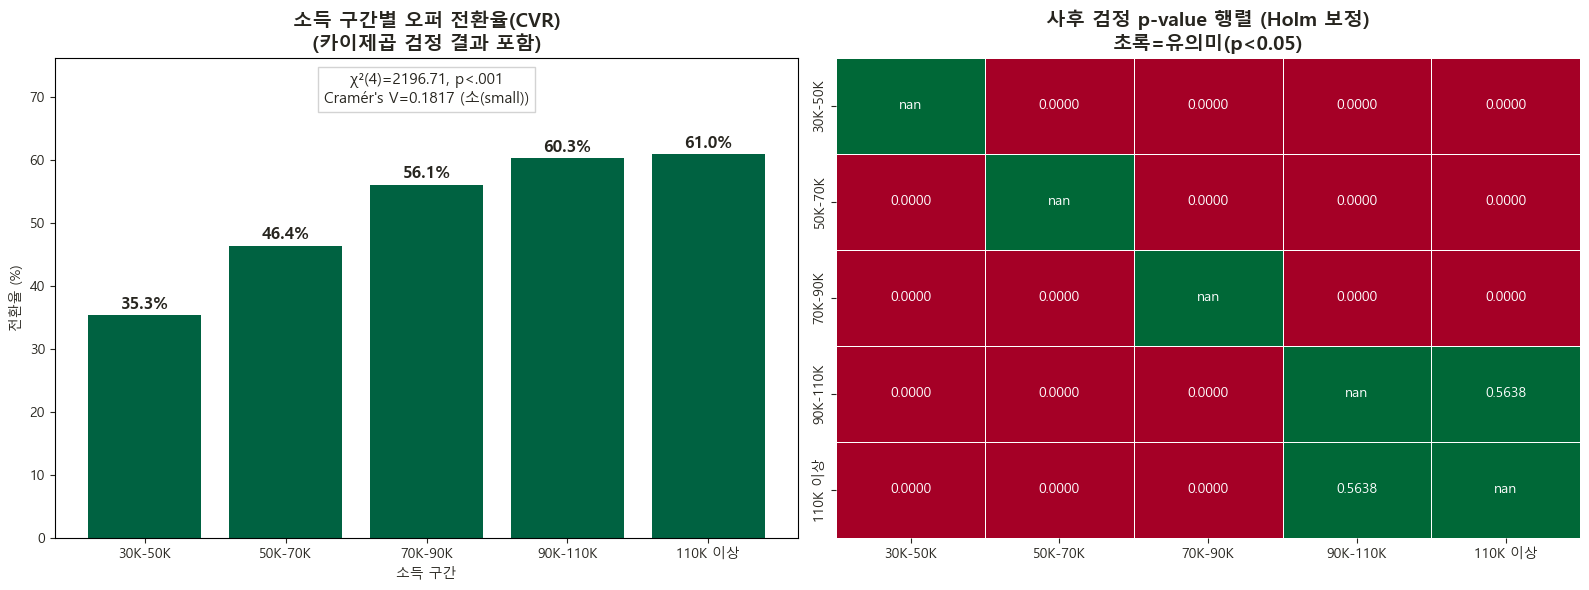

In [78]:
# 사후 검정: 쌍별 카이제곱 + Holm 보정
pairs = list(combinations(INCOME_LABELS, 2))
pairwise_results = []

for g1, g2 in pairs:
    subset = ct_2col.loc[[g1, g2]]
    chi2_p, p_p, _, _ = chi2_contingency(subset)
    pairwise_results.append({
        'Group 1': g1,
        'Group 2': g2,
        'chi2': round(chi2_p, 4),
        'p_raw': p_p
    })

pw_df = pd.DataFrame(pairwise_results)

# Holm 보정
reject, p_corrected, _, _ = multipletests(pw_df['p_raw'], method='holm')
pw_df['p_holm'] = p_corrected.round(4)
pw_df['유의'] = reject
pw_df['유의여부'] = pw_df['유의'].map({True: '★ 유의 (p<0.05)', False: 'n.s.'})

print("[사후 검정 — 쌍별 카이제곱 (Holm 보정)]")
display(pw_df[['Group 1', 'Group 2', 'chi2', 'p_raw', 'p_holm', '유의여부']])

# p-value 히트맵
heatmap_data = pd.DataFrame(index=INCOME_LABELS, columns=INCOME_LABELS, dtype=float)
for _, row in pw_df.iterrows():
    heatmap_data.loc[row['Group 1'], row['Group 2']] = row['p_holm']
    heatmap_data.loc[row['Group 2'], row['Group 1']] = row['p_holm']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 전환율 막대 그래프 + 검정 결과
bars = ax1.bar(INCOME_LABELS, cvr.values,
               color=[SB_GREEN] * len(INCOME_LABELS))
ax1.set_title('소득 구간별 오퍼 전환율(CVR)\n(카이제곱 검정 결과 포함)',
                fontsize=14, fontweight='bold')
ax1.set_ylabel('전환율 (%)')
ax1.set_xlabel('소득 구간')
ax1.set_ylim(0, cvr.max() * 1.25)
for i, v in enumerate(cvr.values):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax1.text(0.5, 0.97,
        f"χ²({dof_main})={chi2_main:.2f}, p<.001\nCramér's V={cramers_v_main:.4f} ({interpret_cramers_v(cramers_v_main)})",
        ha='center', va='top', fontsize=11,
        transform=ax1.transAxes,
        bbox=dict(fc='white', ec='lightgray', pad=4))

# 사후검정 히트맵
sns.heatmap(
    heatmap_data.astype(float) < 0.05,
    annot=heatmap_data.astype(float).round(4),
    fmt='.4f',
    cmap='RdYlGn_r',
    cbar=False,
    linewidths=.5,
    ax=ax2
)
ax2.set_title('사후 검정 p-value 행렬 (Holm 보정)\n초록=유의미(p<0.05)',
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [79]:
# ── 추세 검정: Cochran-Armitage Test ──
# 소득 구간이 순서형(ordinal)이므로 "소득이 높을수록 전환율이 높아지는 선형 추세"를 검증
from scipy.stats import chi2 as chi2_dist

# 각 소득 구간에 점수 부여 (순서 점수)
scores = np.arange(len(INCOME_LABELS))  # [0, 1, 2, 3, 4]
n_i    = ct_2col.sum(axis=1).values     # 각 구간 총 발송 수
x_i    = ct_2col['completed'].values    # 각 구간 완료 수
p_i    = x_i / n_i                      # 각 구간 전환율

N     = n_i.sum()
p_bar = x_i.sum() / N

# Cochran-Armitage 통계량
numerator   = np.sum(scores * (x_i - n_i * p_bar))
denominator = np.sqrt(p_bar * (1 - p_bar) * (np.sum(n_i * scores**2) - N * np.mean(scores)**2))
z_ca        = numerator / denominator
p_ca        = 2 * (1 - chi2_dist.cdf(z_ca**2, df=1))  # 양측

print("=" * 60)
print("[Cochran-Armitage 추세 검정]")
print(f"  귀무가설: 소득 구간에 따른 전환율의 선형 추세가 없다")
print(f"  Z = {z_ca:.4f},  p = {p_ca:.4e}")
print(f"  {'★ 추세 유의미 (p<0.05)' if p_ca < 0.05 else '추세 유의미하지 않음'}")
print()
if z_ca > 0 and p_ca < 0.05:
    print("  → 소득이 높아질수록 전환율이 유의미하게 증가하는 선형 추세 확인")
    print("  → 단순히 '구간 간 차이가 있다'를 넘어, 방향성까지 통계적으로 입증됨")
print("=" * 60)

[Cochran-Armitage 추세 검정]
  귀무가설: 소득 구간에 따른 전환율의 선형 추세가 없다
  Z = nan,  p = nan
  추세 유의미하지 않음



### 카이제곱 + Cochran-Armitage 추세 검정 — 소득 구간별 오퍼 전환율

##### 결과: χ² p < 0.001 (Cramér's V = 0.1817), 선형 추세 검정 유의미

해석: 카이제곱 사후 검정의 쌍별 비교에서 Holm 보정을 거친 결과, 소득이 높아질수록 오퍼 전환율이 단조 증가하는 패턴이 확인됨. 단순한 차이 존재 여부를 넘어 Cochran-Armitage 검정을 통해 "소득 구간의 상승이 전환율의 선형적 증가와 뚜렷한 방향성으로 결합되어 있음"이 통계적으로 교차 입증되었다. 효과 크기(0.1817) 역시 마케팅 액션에 반영할 만한 실질적인 패턴임을 뒷받침한다.

### 고객 세그먼트 딥다이브

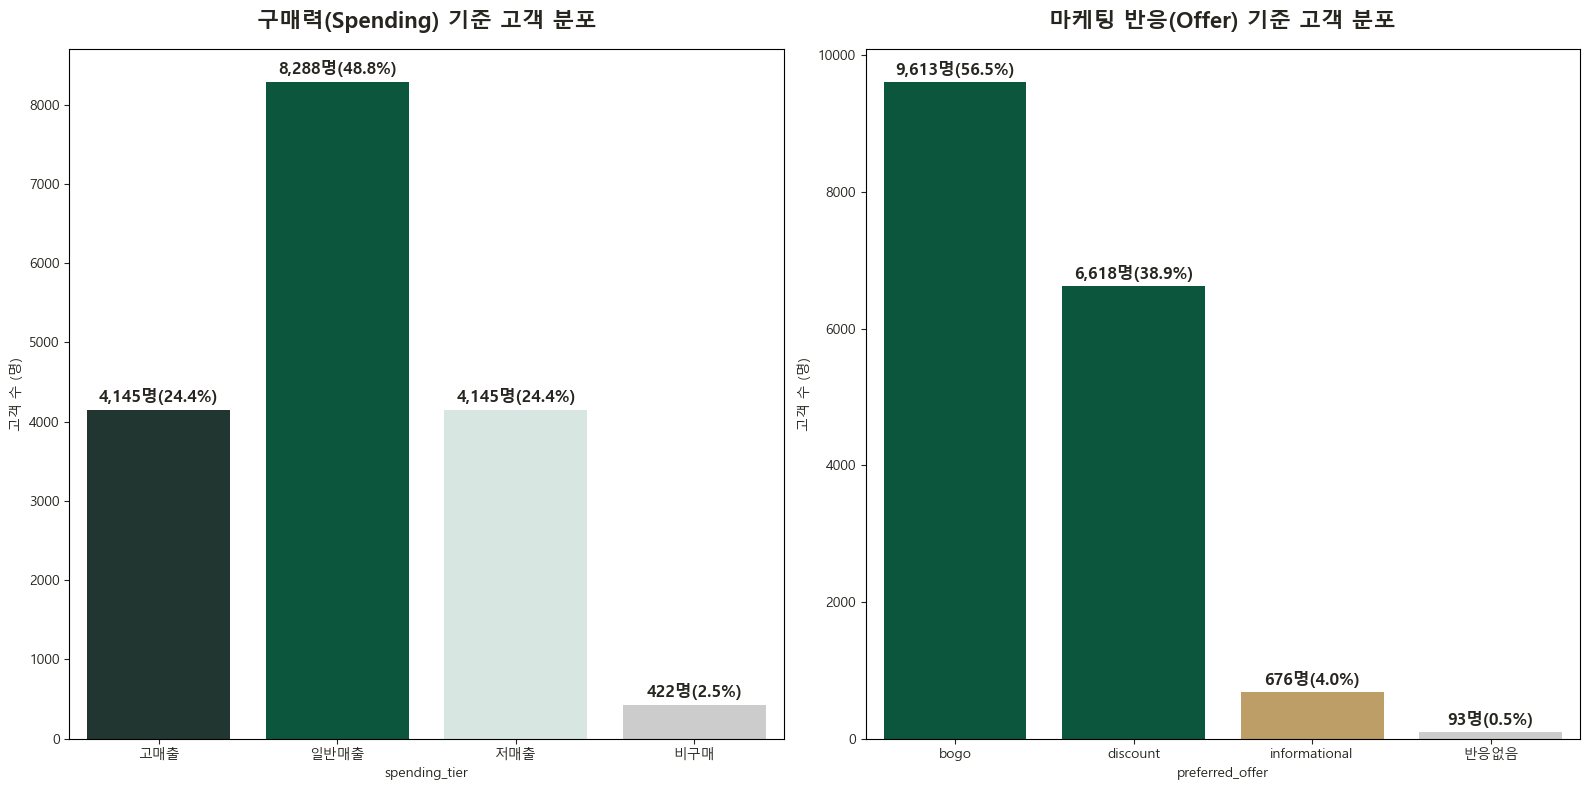

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 구매력 기준 분포
spend_order  = ['고매출', '일반매출', '저매출', '비구매']
spend_counts = customers['spending_tier'].value_counts().reindex(spend_order)
spend_pct    = spend_counts / len(customers) * 100

ax1 = sns.barplot(x=spend_counts.index, y=spend_counts.values,
                    palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, '#CCCCCC'], ax=axes[0])
axes[0].set_title('구매력(Spending) 기준 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('고객 수 (명)')
for i, (v, p) in enumerate(zip(spend_counts.values, spend_pct.values)):
    if not pd.isna(v):
        ax1.text(i, v + 100, f'{v:,.0f}명({p:.1f}%)', ha='center',
                fontweight='bold', fontsize=12)

# 마케팅 반응 기준 분포
offer_order  = ['bogo', 'discount', 'informational', '반응없음']
offer_counts = customers['preferred_offer'].value_counts().reindex(offer_order)
offer_pct    = offer_counts / len(customers) * 100

ax2 = sns.barplot(x=offer_counts.index, y=offer_counts.values,
                    palette=[SB_GREEN, SB_GREEN, SB_GOLD, '#CCCCCC'], ax=axes[1])
axes[1].set_title('마케팅 반응(Offer) 기준 고객 분포', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('고객 수 (명)')
for i, (v, p) in enumerate(zip(offer_counts.values, offer_pct.values)):
    if not pd.isna(v):
        ax2.text(i, v + 100, f'{v:,.0f}명({p:.1f}%)', ha='center',
                fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


#### [액션 플랜]
##### bogo 오퍼 유형으로 고소득 일반 고객 타겟 프로모션 진행 후 discount 오퍼 추가 진행 고려

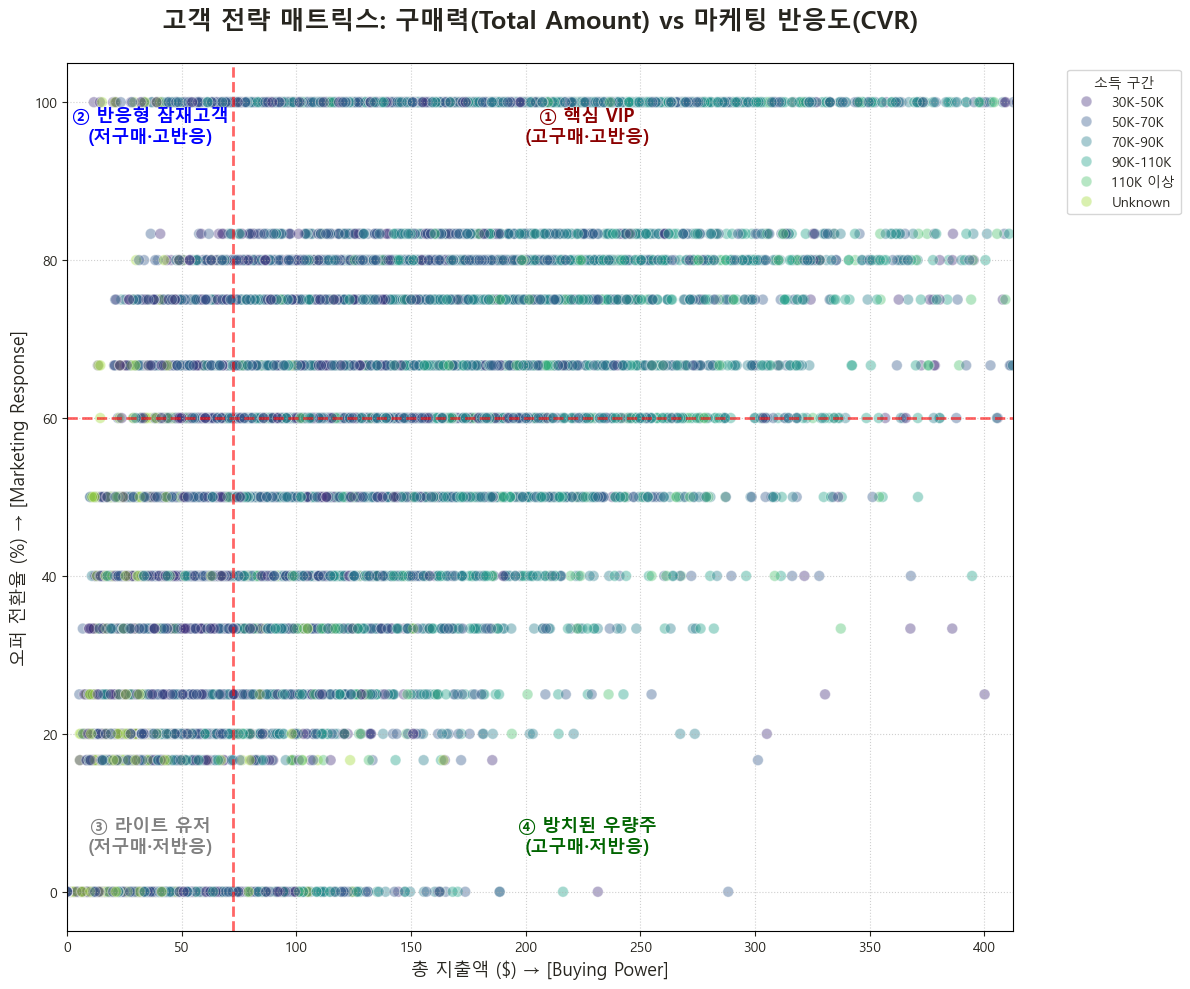

In [81]:
# 고객별 마케팅 반응도(CVR) 계산
offer_counts = df[df['event'].isin(['received', 'completed'])].groupby(['customer_id', 'event']).size().unstack(fill_value=0)

if 'received' in offer_counts.columns and 'completed' in offer_counts.columns:
    # 수령(received)이 0인 경우 결측치 처리를 위해 np.where 사용
    offer_counts['individual_cvr'] = np.where(
        offer_counts['received'] > 0,
        (offer_counts['completed'] / offer_counts['received']) * 100,
        0
    )
else:
    offer_counts['individual_cvr'] = 0

# 기존 customers 데이터와 결합
matrix_df = pd.merge(customers, offer_counts[['individual_cvr']], on='customer_id', how='left')

# 범주형 에러 방지: 필요한 컬럼(individual_cvr)에만 0을 채웁니다.
matrix_df['individual_cvr'] = matrix_df['individual_cvr'].fillna(0)
# total_amount도 혹시 모를 결측치가 있다면 개별적으로 처리
matrix_df['total_amount'] = matrix_df['total_amount'].fillna(0)

plt.figure(figsize=(12, 10))

# 중앙값(Median) 기준 (지출이 있는 고객 대상)
x_mid = matrix_df[matrix_df['total_amount'] > 0]['total_amount'].median()
y_mid = matrix_df[matrix_df['individual_cvr'] > 0]['individual_cvr'].median()

sns.scatterplot(data=matrix_df, x='total_amount', y='individual_cvr', 
                alpha=0.4, hue='income_group', palette='viridis', s=60)

plt.axvline(x_mid, color='red', linestyle='--', alpha=0.6, lw=2)
plt.axhline(y_mid, color='red', linestyle='--', alpha=0.6, lw=2)

# 레이블 위치 조정
plt.text(matrix_df['total_amount'].quantile(0.9), 95, '① 핵심 VIP\n(고구매·고반응)', fontsize=13, fontweight='bold', ha='center', color='darkred')
plt.text(x_mid/2, 95, '② 반응형 잠재고객\n(저구매·고반응)', fontsize=13, fontweight='bold', ha='center', color='blue')
plt.text(x_mid/2, 5, '③ 라이트 유저\n(저구매·저반응)', fontsize=13, fontweight='bold', ha='center', color='grey')
plt.text(matrix_df['total_amount'].quantile(0.9), 5, '④ 방치된 우량주\n(고구매·저반응)', fontsize=13, fontweight='bold', ha='center', color='darkgreen')

plt.title('고객 전략 매트릭스: 구매력(Total Amount) vs 마케팅 반응도(CVR)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('총 지출액 ($) → [Buying Power]', fontsize=13)
plt.ylabel('오퍼 전환율 (%) → [Marketing Response]', fontsize=13)
plt.xlim(0, matrix_df['total_amount'].quantile(0.98))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='소득 구간', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

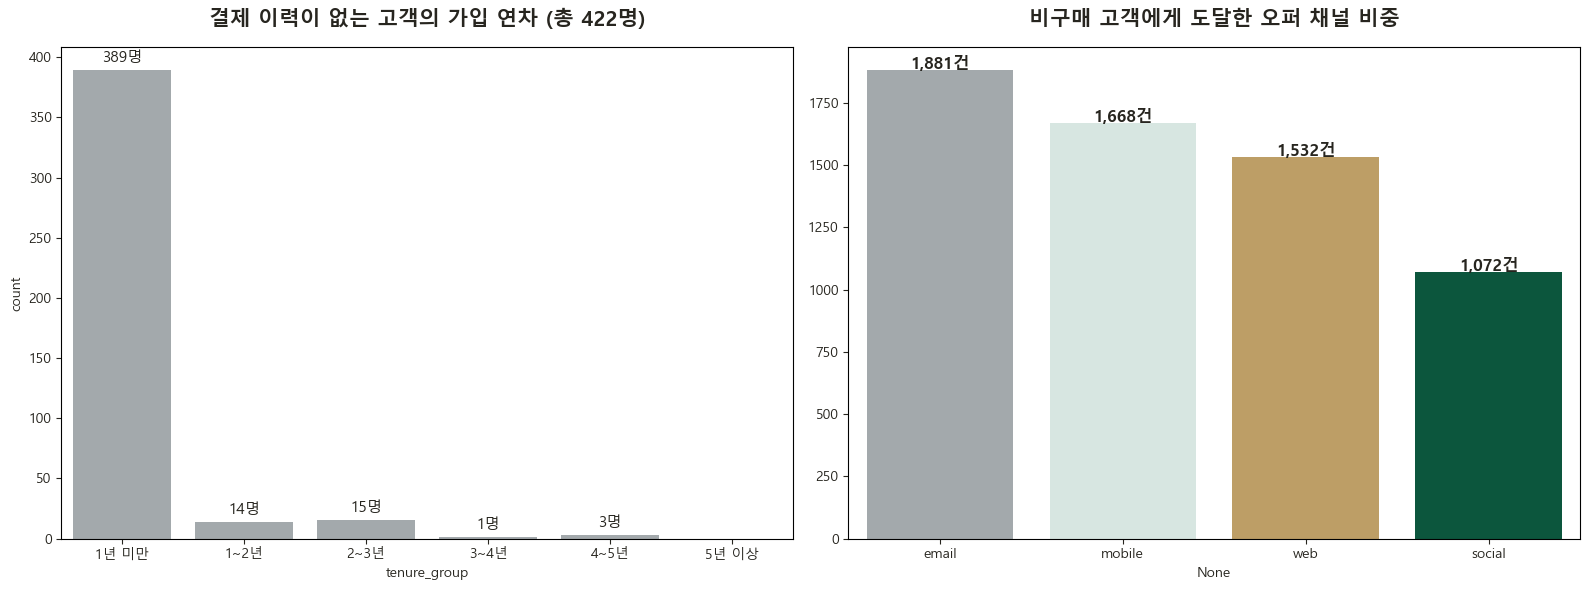

In [82]:
zero_spend_cust = customers[customers['spending_tier'] == '비구매']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 비구매 고객 가입 연차
ax1 = sns.countplot(data=zero_spend_cust, x='tenure_group', color=SB_GREY,
                    order=TENURE_ORDER, ax=axes[0])
axes[0].set_title(f'결제 이력이 없는 고객의 가입 연차 (총 {len(zero_spend_cust):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
for c in ax1.containers:
    ax1.bar_label(c, fmt='%d명', padding=3, fontsize=11)

# 비구매 고객 도달 채널
zero_spend_ids = zero_spend_cust['customer_id']
zero_channels  = (
    df[(df['customer_id'].isin(zero_spend_ids)) & (df['event'] == 'received')]
    [['email', 'mobile', 'web', 'social']]
    .sum()
    .sort_values(ascending=False)
)
ax2 = sns.barplot(x=zero_channels.index, y=zero_channels.values,
                  palette=[SB_GREY, SB_LIGHT_GREEN, SB_GOLD, SB_GREEN], ax=axes[1])
axes[1].set_title('비구매 고객에게 도달한 오퍼 채널 비중',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(zero_channels.values):
    ax2.text(i, v + 5, f'{v:,.0f}건', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

#### [액션 플랜]
##### 1년 미만 신규 고객 → 첫 구매 BOGO 쿠폰
##### 가입 기간 긴 미활성 고객 → 휴면 전환 안내(앱 푸시/이메일)
##### Unknown 그룹에는 프로모션 발송 비용(예: 알림톡, SMS 발송비)을 최소화하고, 무료 채널(앱 푸시, 이메일) 위주로만 운영하여 마케팅 ROI를 방어해야 한다.

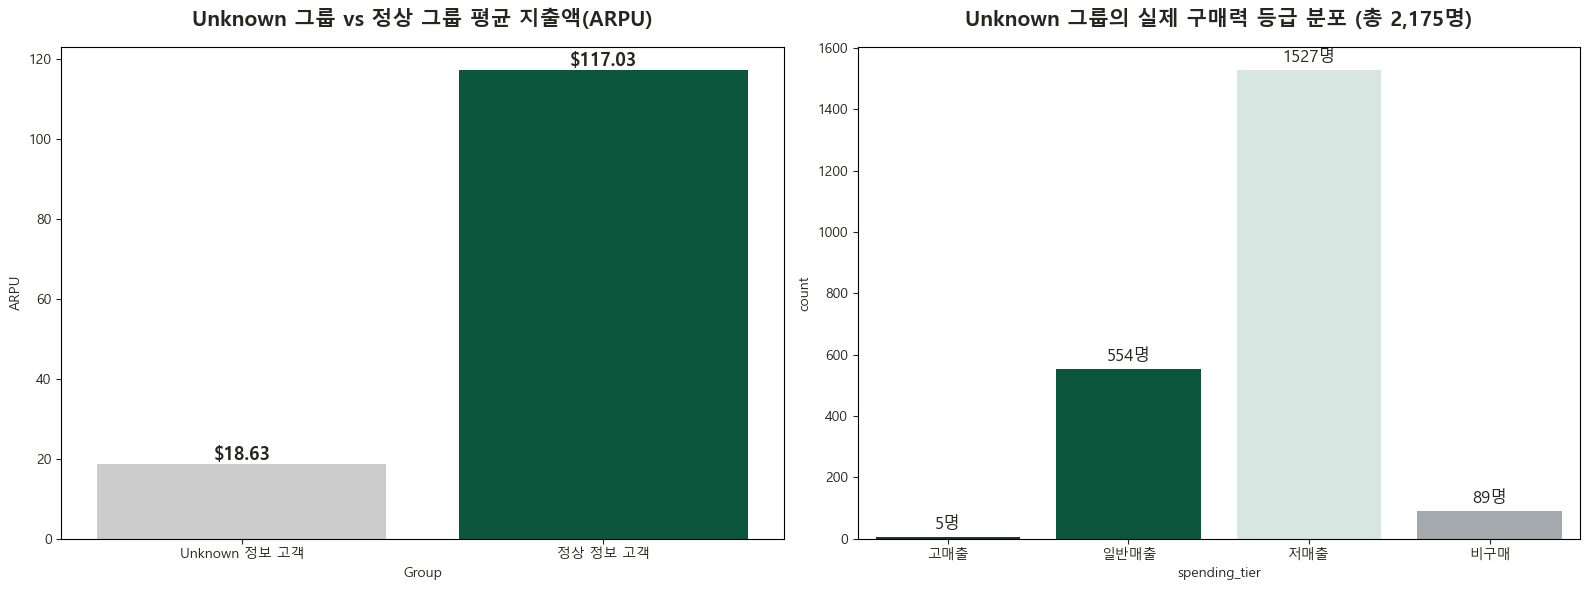

In [83]:
unknown_cust = customers[customers['income_group'] == 'Unknown']
known_cust   = customers[customers['income_group'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Unknown vs 정상 ARPU 비교
arpu_data = pd.DataFrame({
    'Group': ['Unknown 정보 고객', '정상 정보 고객'],
    'ARPU' : [unknown_cust['total_amount'].mean(), known_cust['total_amount'].mean()]
})
ax1 = sns.barplot(data=arpu_data, x='Group', y='ARPU',
                  palette=['#CCCCCC', SB_GREEN], ax=axes[0])
axes[0].set_title('Unknown 그룹 vs 정상 그룹 평균 지출액(ARPU)',
                  fontsize=15, fontweight='bold', pad=15)
for i, v in enumerate(arpu_data['ARPU']):
    ax1.text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

# Unknown 그룹 구매력 등급 분포
ax2 = sns.countplot(data=unknown_cust, x='spending_tier',
                    palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, '#A2AAAD'],
                    order=['고매출', '일반매출', '저매출', '비구매'], ax=axes[1])
axes[1].set_title(f'Unknown 그룹의 실제 구매력 등급 분포 (총 {len(unknown_cust):,}명)',
                  fontsize=15, fontweight='bold', pad=15)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%d명', padding=3, fontsize=12)

plt.tight_layout()
plt.show()


## 종합 인사이트 및 최종 액션 플랜

### 1. 주요 데이터 및 통계 검정 요약
타겟팅 전략을 도출하기 전, 전체 데이터를 관통하는 두 가지 핵심 축(**소득 수준**과 **브랜드 관여도**)에 대한 통계적 근거

* **매출 편중:** 상위 20%의 VIP 고객이 전체 매출의 약 54%를 견인
* **소득 축 (Kruskal-Wallis p < 0.001):** 소득 구간별로 지출액에 유의미한 차이가 존재. 단, 최상위 두 구간(90K~110K, 110K 이상) 간에는 소비 패턴 차이가 없어 하나의 '프리미엄 그룹'으로 병합하는 것이 타당함
* **관여도 축 (Mann-Whitney p < 0.05):** 정보성 오퍼를 조회하는 고관여 고객군은 일반 결제 횟수와 객단가 모두 유의미하게 높음

<br>

### 2. 세그먼트별 타겟팅 및 마케팅 액션 플랜
위의 통계적 근거를 바탕으로 불필요한 마케팅 비용(Unknown/미결제 그룹 등)을 최소화하고, ROI를 극대화하기 위한 전략

| 세그먼트 | 핵심 타겟 | 오퍼 유형 | 핵심 채널 | 우선순위 |
|----------|-----------|-----------|-----------|----------|
| **VIP (상위 20%)** | 고관여 우량 고객 | 정보성 오퍼 (브랜드 상기) | Email / App Push | ★★★ |
| **잠재 VIP** | 50K~90K 중간 소득층 | 선호 오퍼 집중 타겟팅 (BOGO/할인) | Mobile | ★★★ |
| **프리미엄** | 90K 이상 고소득층 | 브랜드 경험 중심 (신제품 등) | App Push | ★★ |
| **신규 비구매** | 가입 1년 미만 | 첫 구매 BOGO 파격 쿠폰 | Mobile / Social | ★★ |
| **장기 비구매** | 가입 2년 이상 (결제 0) | 휴면 전환 안내 또는 윈백 할인 | Email | ★ |

##### **3대 핵심 액션 플랜:**

* **고소득층 (90K 이상) 프리미엄화:** 이들은 이미 구매력이 충분하므로, 파격적인 할인 쿠폰 대신 신제품 안내나 브랜드 소식 등 '경험 중심'의 혜택으로 마케팅 비용을 세이브됨
* **고관여 우량 고객(VIP) 방어:** 원래 브랜드를 선호하는 이들에게는 고비용의 1+1(BOGO) 쿠폰을 남발할 필요가 없습니다. 가벼운 정보성 알림만 주기적으로 발송해도 재방문과 매출이 탄탄하게 유지됨
* **중간 소득층 (50K~90K) 집중 투자:** 위에서 아낀 예산은 전환율 상승 잠재력이 가장 큰 '중간 소득 구간(특히 5060세대)'에 올인합니다. 이들에게 가장 반응이 좋은 BOGO 및 할인 쿠폰을 집중 발송하여 신규 VIP로 끌어올리는 것이 핵심 성장 동력

<br>

### 3. 본 분석의 한계 및 향후 과제 (Next Steps)

##### **Phase 1. 분석의 한계점**
* **단기 데이터의 한계:** 전체 분석 기간이 약 30일로 짧아, 장기적인 고객 생애 가치(LTV)나 행동 패턴이 과소 추정되었을 수 있음
* **인과관계의 한계:** 정보성 오퍼와 지출액 간의 긍정적 지표는 '상관관계(선택 편향)'일 수 있으며, 명확한 인과관계를 입증하려면 향후 A/B 테스트가 필요함

##### **Phase 2. 다변량 기반 VIP 예측 모델링 (Next Steps)**
현재까지의 통계 검정은 개별 변수가 지출에 미치는 영향을 독립적으로 확인하는 단변량/이변량 분석에 집중했음

향후 분석의 한계(교란 변수 통제 불가)를 보완하고 타겟팅 전략을 고도화하기 위해 **다변량 모델링(Multivariate Modeling)**을 후속 과제로 진행할 계획

* **로지스틱 회귀 분석 (Logistic Regression):** 가입 기간, 연령대, 소득 구간 등을 동시에 투입하여 변수 간의 영향을 통제함. 이를 통해 *"연령과 가입 기간이 동일할 때, 소득 구간이 상승하면 VIP 전환 확률이 몇 배 증가하는가?"*를 정량적으로 도출하여 가장 강력한 VIP 결정 요인을 식별
* **의사결정나무 (Decision Tree):** 변수 간의 복합적인 상호작용을 시각화함. 트리의 분기점을 역추적하여 *"가입 3년 이상 + 40대 + 70K 이상 소득"*과 같이 실무에 즉시 적용 가능한 **'고확률 VIP 전환 세그먼트 규칙(Rule)'**을 추출

##### **→ 최종 결론:** 이번 분석을 통해 도출된 '소득'과 '관여도'라는 두 가지 핵심 축을 바탕으로, 추후 예측 기반의 정교한 타겟팅 시스템을 구축하여 마케팅 ROI를 극대화하고자 함